<a href="https://colab.research.google.com/github/bctcaiedu/milaisw/blob/main/2026_%EC%9C%A1%EA%B5%B0_AI%EC%86%8C%EC%96%91%EA%B5%90%EC%9C%A1_4%EC%9D%BC%EC%B0%A8_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎖️ 2026년 부대 맞춤형 AI·SW 소양교육
## 육군 직무보수교육 - **4일차 미니 프로젝트**

> **Ⅳ. 부대 실무 데이터를 활용한 EDA 및 시각화**

### 🎯 프로젝트 주제
> **"부대 장비 정비 기록 분석을 통한 예방정비 전략 수립"**

### 📚 오늘 배울 내용
- **EDA(탐색적 데이터 분석)** 개념 및 6단계 프로세스
- 부대 장비 정비 데이터 로드 & 품질 점검
- 기술통계 분석 (describe, value_counts)
- 단변량 분석 (히스토그램, 박스플롯)
- 다변량 분석 (groupby, corr, heatmap)
- 차트 선택 가이드 (6가지 차트 유형)
- **인사이트 도출 및 보고서 작성**

---

### 💡 John Tukey의 EDA 정의 (1977)
> **"데이터가 우리에게 무엇을 말하는지 먼저 들어라."**  
> 데이터를 분석하기 전, 그래프·통계로 **구조·패턴·이상치·관계**를 직관적으로 파악하는 탐색 과정

### 🏛 부대 현장 활용 사례
- **🔧 장비 정비**: 고장 빈도·정비소요시간 분석 → 예방정비 시기 예측
- **🎯 훈련 성과**: 사격·체력검정 결과 분포 및 추세 파악
- **📦 군수 현황**: 물자 소비 패턴 분석 → 적정 재고 수준 도출

---

# 🛠️ Chapter 0. 환경 구성 및 실습 데이터 준비

## 0-1. 라이브러리 import

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print(f"pandas    : {pd.__version__}")
print(f"numpy     : {np.__version__}")
print(f"seaborn   : {sns.__version__}")

pandas    : 2.2.2
numpy     : 2.0.2
seaborn   : 0.13.2


## 0-2. 한글 폰트 설정

In [59]:
!apt-get install -qq fonts-nanum > /dev/null 2>&1

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
sns.set_style('whitegrid')
sns.set_context('notebook')
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

print("✅ 한글 폰트 설정 완료")

✅ 한글 폰트 설정 완료


## 0-3. 실습 데이터 생성 — 부대 장비 정비 기록

PPT에서 제시된 시나리오(240건 × 10컬럼 × 12개월)를 그대로 재현합니다.

**데이터 명세**
- 기간: 2024년 1월 ~ 2024년 12월 (12개월)
- 장비유형 4종: K131 트럭, K200 장갑차, 발전기, K511 카고트럭
- 고장유형 5종: 엔진 이상, 변속기 결함, 브레이크 마모, 궤도 마모, 오일 누유
- 의도적 삽입:
  - 결측값 (정비일자 2건, 고장유형 5건)
  - 이상치 (정비시간 38.5h 초과)
  - 계절성 (8월 훈련 후 급증)

In [17]:
np.random.seed(42)
N = 240

# 장비유형별 특성 (정비시간 평균, 비용 평균)
equip_specs = {
    "K131 트럭":   {"time_mean": 6.0,  "cost_mean": 100, "weight": 0.30, "code": "K131"},
    "K200 장갑차": {"time_mean": 18.0, "cost_mean": 480, "weight": 0.25, "code": "K200"},
    "K511 카고":   {"time_mean": 8.0,  "cost_mean": 150, "weight": 0.25, "code": "K511"},
    "발전기":      {"time_mean": 4.0,  "cost_mean": 85,  "weight": 0.20, "code": "GEN"},
}

equip_types = list(equip_specs.keys())
weights     = [equip_specs[e]["weight"] for e in equip_types]

breakdown_types = ["엔진 이상", "변속기 결함", "브레이크 마모", "궤도 마모", "오일 누유"]
units   = ["1중대", "2중대", "3중대", "4중대"]
results = ["완료", "부분완료", "가동불능"]

# 날짜 생성 - 8월에 정비 건수 몰리도록 (하계 훈련 후)
month_weights = [0.06, 0.06, 0.07, 0.08, 0.08, 0.09, 0.09, 0.15, 0.10, 0.08, 0.07, 0.07]
month_weights = np.array(month_weights) / sum(month_weights)
months = np.random.choice(range(1, 13), size=N, p=month_weights)

dates = []
for m in months:
    d = np.random.randint(1, 29)
    dates.append(f"2024-{m:02d}-{d:02d}")

# 장비유형 배정
types = np.random.choice(equip_types, N, p=weights)

# 장비번호: 코드-번호 (K131-003 형식)
equip_ids = [f"{equip_specs[t]['code']}-{np.random.randint(1, 30):03d}" for t in types]

# 정비시간: 장비유형에 따라 다른 평균, 일부 이상치
times = []
for t in types:
    base = equip_specs[t]["time_mean"]
    # 5% 확률로 이상치 (아주 긴 정비)
    if np.random.random() < 0.05:
        times.append(np.round(np.random.uniform(38, 48), 1))
    else:
        times.append(np.round(max(0.5, np.random.gamma(2.5, base/2.5)), 1))

# 정비비용: 정비시간과 강한 양의 상관 + 장비별 가중치
costs = []
for t, time in zip(types, times):
    cost_base = equip_specs[t]["cost_mean"]
    cost = cost_base * (time / equip_specs[t]["time_mean"]) * np.random.uniform(0.7, 1.3)
    costs.append(int(max(12, cost)))

# 고장유형 - 장비별 특성 반영
breakdowns = []
for t in types:
    if t == "K200 장갑차":
        bd = np.random.choice(["변속기 결함", "궤도 마모", "엔진 이상"], p=[0.4, 0.4, 0.2])
    elif t == "발전기":
        bd = np.random.choice(["엔진 이상", "오일 누유"], p=[0.6, 0.4])
    else:
        bd = np.random.choice(breakdown_types)
    breakdowns.append(bd)

# 정비 결과
result_list = np.random.choice(results, N, p=[0.80, 0.12, 0.08])

# DataFrame 생성
df_raw = pd.DataFrame({
    "정비일자": dates,
    "장비번호": equip_ids,
    "장비유형": types,
    "고장유형": breakdowns,
    "담당부대": np.random.choice(units, N),
    "정비시간(h)": times,
    "정비비용(만원)": costs,
    "결과": result_list,
})

# 의도적으로 결측값 삽입
df_raw.loc[[13, 87], "정비일자"] = np.nan                          # 2건
df_raw.loc[[5, 40, 100, 150, 200], "고장유형"] = np.nan            # 5건

# 저장
df_raw.to_csv('/content/maintenance_log.csv', index=False, encoding='utf-8-sig')

# from google.colab import drive
# drive.mount('/content/drive')
# df_raw.to_csv('/content/drive/MyDrive/maintenance_log.csv', index=False, encoding='utf-8-sig')


print(f"✅ 정비 기록 생성: {df_raw.shape[0]}건 × {df_raw.shape[1]}컬럼")
print(f"   기간        : 2024년 1월 ~ 12월")
print(f"   장비유형    : {df_raw['장비유형'].nunique()}종")
print(f"   결측값      : 정비일자 2건, 고장유형 5건 (의도적 삽입)")
print(f"   저장 위치   : /content/maintenance_log.csv")
df_raw.head()

✅ 정비 기록 생성: 240건 × 8컬럼
   기간        : 2024년 1월 ~ 12월
   장비유형    : 4종
   결측값      : 정비일자 2건, 고장유형 5건 (의도적 삽입)
   저장 위치   : /content/maintenance_log.csv


,정비일자,장비번호,장비유형,고장유형,담당부대,정비시간(h),정비비용(만원),결과
0,2024-06-28,GEN-022,발전기,오일 누유,2중대,6.3,132,가동불능
1,2024-12-14,K511-014,K511 카고,엔진 이상,2중대,7.3,162,완료
2,2024-09-21,GEN-026,발전기,오일 누유,1중대,8.4,183,완료
3,2024-08-06,K131-028,K131 트럭,궤도 마모,3중대,6.8,82,부분완료
4,2024-03-03,K131-023,K131 트럭,오일 누유,1중대,11.2,201,완료


---
# 📚 Chapter 1. EDA 개념과 6단계 프로세스

## 1-1. EDA란 무엇인가?

### 존 튜키(John Tukey)의 정의 — 1977
> 데이터를 분석하기 전, **그래프·통계 방법**으로  
> 데이터의 **구조·패턴·이상치·관계**를 직관적으로 파악하는 **탐색 과정**

### EDA가 중요한 4가지 이유

| 목적 | 설명 |
|---|---|
| 🧐 **품질 문제 발견** | 결측값·오류·이상치 사전 탐지 |
| 🎯 **분석 방향 설정** | 모델링 전 적합한 전략 수립 |
| 💡 **패턴·인사이트** | 예상치 못한 발견 |
| 📣 **시각적 전달** | 비전문가에게도 쉽게 설명 |

## 1-2. EDA 6단계 프로세스

```
┌─────────────────────────────────────────────────────┐
│ ① 데이터 로드      │ df.info() / df.shape           │
│ ② 품질 점검        │ isnull() / duplicated()        │
│ ③ 기술통계 분석    │ describe() / value_counts()    │
│ ④ 단변량 분석      │ hist() / boxplot()             │
│ ⑤ 다변량 분석      │ corr() / groupby() / heatmap   │
│ ⑥ 인사이트 도출    │ 의사결정 권고안 작성            │
└─────────────────────────────────────────────────────┘
```

오늘은 이 6단계를 **부대 장비 정비 데이터** 로 직접 실행해 봅니다.

---
### 🔥 실습문제 1 - EDA 개념 확인
다음 질문에 답하세요.

1. EDA라는 개념을 처음 제시한 통계학자의 이름은?
2. EDA 6단계 중 `describe()`가 사용되는 단계는 몇 단계?
3. 아래 상황에 적합한 EDA 단계를 매칭하세요.
   - (a) "정비시간 평균과 표준편차를 알고 싶다"
   - (b) "정비시간과 정비비용이 관련 있을까?"
   - (c) "결측값이 몇 건 있는지 확인"


In [18]:
# ✍️ 여기에 답을 작성하세요

answer_1 = ""        # 이름
answer_2 = 0         # 숫자
match_a = 0          # 1~6 중 해당 단계
match_b = 0
match_c = 0

print(f"1) EDA 창시자: {answer_1}")
print(f"2) describe() 단계: {answer_2}")
print(f"3-a) 평균·표준편차 분석 → {match_a}단계")
print(f"3-b) 변수 간 관련성 → {match_b}단계")
print(f"3-c) 결측값 확인 → {match_c}단계")

1) EDA 창시자: 
2) describe() 단계: 0
3-a) 평균·표준편차 분석 → 0단계
3-b) 변수 간 관련성 → 0단계
3-c) 결측값 확인 → 0단계


**✅ 정답**

In [19]:
answer_1 = "John Tukey (존 튜키)"
answer_2 = 3
match_a  = 3       # 기술통계 분석
match_b  = 5       # 다변량 분석
match_c  = 2       # 품질 점검

print(f"1) EDA 창시자: {answer_1}")
print(f"2) describe() 단계: {answer_2}단계 (기술통계 분석)")
print(f"3-a) 평균·표준편차 → {match_a}단계 (기술통계 분석)")
print(f"3-b) 변수 간 관련성 → {match_b}단계 (다변량 분석)")
print(f"3-c) 결측값 확인 → {match_c}단계 (품질 점검)")

1) EDA 창시자: John Tukey (존 튜키)
2) describe() 단계: 3단계 (기술통계 분석)
3-a) 평균·표준편차 → 3단계 (기술통계 분석)
3-b) 변수 간 관련성 → 5단계 (다변량 분석)
3-c) 결측값 확인 → 2단계 (품질 점검)


---
# 📥 Chapter 2. [Step 1-2] 데이터 로드 & 품질 점검

## 2-1. 데이터 로드

In [20]:
# CSV 파일 읽기
df = pd.read_csv('/content/maintenance_log.csv', encoding='utf-8-sig')

# 기본 정보 확인
print(f"📊 데이터 크기: {df.shape[0]}건 × {df.shape[1]}컬럼\n")
print(f"📋 컬럼 목록: {df.columns.tolist()}\n")
print(f"📝 상위 5건 미리보기:")
df.head()

📊 데이터 크기: 240건 × 8컬럼

📋 컬럼 목록: ['정비일자', '장비번호', '장비유형', '고장유형', '담당부대', '정비시간(h)', '정비비용(만원)', '결과']

📝 상위 5건 미리보기:


,정비일자,장비번호,장비유형,고장유형,담당부대,정비시간(h),정비비용(만원),결과
0,2024-06-28,GEN-022,발전기,오일 누유,2중대,6.3,132,가동불능
1,2024-12-14,K511-014,K511 카고,엔진 이상,2중대,7.3,162,완료
2,2024-09-21,GEN-026,발전기,오일 누유,1중대,8.4,183,완료
3,2024-08-06,K131-028,K131 트럭,궤도 마모,3중대,6.8,82,부분완료
4,2024-03-03,K131-023,K131 트럭,오일 누유,1중대,11.2,201,완료


In [21]:
# 데이터 구조 한눈에 보기
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   정비일자      238 non-null    object 
 1   장비번호      240 non-null    object 
 2   장비유형      240 non-null    object 
 3   고장유형      235 non-null    object 
 4   담당부대      240 non-null    object 
 5   정비시간(h)   240 non-null    float64
 6   정비비용(만원)  240 non-null    int64  
 7   결과        240 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 15.1+ KB


## 2-2. 데이터 품질 점검 — 결측값 확인

In [22]:
# 컬럼별 결측값 개수
missing = df.isnull().sum()
print("[ 컬럼별 결측값 ]")
print(missing[missing > 0])

# 결측 비율
print(f"\n[ 결측 비율(%) ]")
pct = (df.isnull().sum() / len(df) * 100).round(2)
print(pct[pct > 0])

[ 컬럼별 결측값 ]
정비일자    2
고장유형    5
dtype: int64

[ 결측 비율(%) ]
정비일자    0.83
고장유형    2.08
dtype: float64


In [23]:
# 중복 행 확인
dup_count = df.duplicated().sum()
print(f"🔍 중복 행 수: {dup_count}건")

# 결측값이 있는 행 직접 보기
print(f"\n[ 정비일자 결측 행 ]")
print(df[df['정비일자'].isnull()])

🔍 중복 행 수: 0건

[ 정비일자 결측 행 ]
   정비일자      장비번호     장비유형     고장유형 담당부대  정비시간(h)  정비비용(만원)  결과
13  NaN   GEN-019      발전기    오일 누유  1중대      4.0       102  완료
87  NaN  K131-024  K131 트럭  브레이크 마모  1중대      2.6        47  완료


## 2-3. 결측값 처리 전략

| 컬럼 | 결측 건수 | 전략 | 이유 |
|---|---|---|---|
| 정비일자 | 2건 | **행 삭제** | 날짜 없으면 시계열 분석 불가 |
| 고장유형 | 5건 | **'미확인' 대체** | 정비 기록은 존재, 가치 있음 |

In [24]:
# ① 정비일자 결측 → 행 삭제
before = len(df)
df = df.dropna(subset=['정비일자']).reset_index(drop=True)
print(f"✅ 정비일자 결측 제거: {before} → {len(df)}건")

# ② 고장유형 결측 → '미확인'
df['고장유형'] = df['고장유형'].fillna('미확인')
print(f"✅ 고장유형 결측 처리: '미확인'으로 대체")

# ③ 최종 결측 확인
print(f"\n[ 처리 후 결측값 ]")
final_missing = df.isnull().sum()
print(final_missing[final_missing > 0] if final_missing.sum() > 0 else "✅ 결측값 없음")

✅ 정비일자 결측 제거: 240 → 238건
✅ 고장유형 결측 처리: '미확인'으로 대체

[ 처리 후 결측값 ]
✅ 결측값 없음


## 2-4. 날짜 변환 + 파생변수 생성

In [25]:
# 문자열 → datetime 변환
df['정비일자'] = pd.to_datetime(df['정비일자'])

# 파생변수 생성
df['월']   = df['정비일자'].dt.month
df['분기'] = df['정비일자'].dt.quarter
df['요일'] = df['정비일자'].dt.day_name()

# 한글 요일 매핑
weekday_kr = {'Monday':'월','Tuesday':'화','Wednesday':'수',
              'Thursday':'목','Friday':'금','Saturday':'토','Sunday':'일'}
df['요일_한글'] = df['요일'].map(weekday_kr)

print("[ 파생변수 생성 완료 ]")
df[['정비일자', '월', '분기', '요일_한글']].head()

[ 파생변수 생성 완료 ]


,정비일자,월,분기,요일_한글
0,2024-06-28,6,2,금
1,2024-12-14,12,4,토
2,2024-09-21,9,3,토
3,2024-08-06,8,3,화
4,2024-03-03,3,1,일


---
### 🔥 실습문제 2
1. `df`의 **컬럼별 자료형(dtype)** 을 한 줄로 출력
2. `"결과"` 컬럼의 **고유값** 과 각 값의 **개수** 를 출력
3. `"담당부대"` 별로 **정비 기록 수** 를 내림차순으로 출력
4. 정비일자가 **2024-08-01 ~ 2024-08-31** 인 데이터의 **건수** 를 계산

In [26]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [27]:
# 1) 컬럼별 자료형
print("[ 1. 컬럼별 자료형 ]")
print(df.dtypes)

# 2) 결과 고유값 & 개수
print("\n[ 2. 결과 분포 ]")
print(df['결과'].value_counts())

# 3) 담당부대별 기록 수
print("\n[ 3. 담당부대별 정비 건수 ]")
print(df['담당부대'].value_counts())

# 4) 8월 건수
aug = df[(df['정비일자'] >= '2024-08-01') & (df['정비일자'] <= '2024-08-31')]
print(f"\n[ 4. 2024년 8월 정비 건수: {len(aug)}건 ]")

[ 1. 컬럼별 자료형 ]
정비일자        datetime64[ns]
장비번호                object
장비유형                object
고장유형                object
담당부대                object
정비시간(h)            float64
정비비용(만원)             int64
결과                  object
월                    int32
분기                   int32
요일                  object
요일_한글               object
dtype: object

[ 2. 결과 분포 ]
결과
완료      189
부분완료     31
가동불능     18
Name: count, dtype: int64

[ 3. 담당부대별 정비 건수 ]
담당부대
1중대    74
4중대    56
3중대    55
2중대    53
Name: count, dtype: int64

[ 4. 2024년 8월 정비 건수: 36건 ]


---
# 📊 Chapter 3. [Step 3] 기술통계 분석

## 3-1. `describe()` — 수치형 전체 요약

In [28]:
# 수치형 통계 요약
summary = df[['정비시간(h)', '정비비용(만원)']].describe().round(2)
print("[ 정비시간·비용 기술통계 ]")
print(summary)

[ 정비시간·비용 기술통계 ]
       정비시간(h)  정비비용(만원)
count   238.00    238.00
mean     12.15    264.82
std      12.19    291.85
min       0.50     12.00
25%       4.30     76.25
50%       7.40    133.50
75%      13.75    326.00
max      47.90   1328.00


In [29]:
# 핵심 KPI 계산
total     = len(df)
avg_time  = df['정비시간(h)'].mean()
avg_cost  = df['정비비용(만원)'].mean()
down_rate = (df['결과'] == '가동불능').sum() / total * 100

print(f"📊 전체 정비 기록 수: {total}건")
print(f"⏱️ 평균 정비시간  : {avg_time:.2f} 시간")
print(f"💰 평균 정비비용  : {avg_cost:.0f} 만원")
print(f"⚠️ 가동불능 비율  : {down_rate:.1f}%")

📊 전체 정비 기록 수: 238건
⏱️ 평균 정비시간  : 12.15 시간
💰 평균 정비비용  : 265 만원
⚠️ 가동불능 비율  : 7.6%


## 3-2. 이상치 탐지 — IQR 방법

In [30]:
# 정비시간 이상치 탐지
Q1, Q3 = df['정비시간(h)'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.2f}h, Q3 = {Q3:.2f}h, IQR = {IQR:.2f}")
print(f"이상치 경계 : [{lower:.2f}, {upper:.2f}]")

# 이상치 추출
outliers = df[(df['정비시간(h)'] < lower) | (df['정비시간(h)'] > upper)]
print(f"\n⚠️ 이상치: {len(outliers)}건 (전체의 {len(outliers)/len(df)*100:.1f}%)")
print(outliers[['정비일자', '장비유형', '고장유형', '정비시간(h)', '정비비용(만원)']].head())

Q1 = 4.30h, Q3 = 13.75h, IQR = 9.45
이상치 경계 : [-9.88, 27.92]

⚠️ 이상치: 31건 (전체의 13.0%)
         정비일자      장비유형    고장유형  정비시간(h)  정비비용(만원)
11 2024-12-21  K200 장갑차   궤도 마모     46.7      1328
24 2024-10-03       발전기   엔진 이상     44.6       996
29 2024-08-15   K511 카고  변속기 결함     42.7       606
36 2024-02-26   K511 카고   엔진 이상     40.2       796
42 2024-11-22  K200 장갑차   궤도 마모     38.9       992


## 3-3. 범주형 변수 분석 — `value_counts()`

In [31]:
# 장비유형별 정비 건수
print("[ 장비유형별 정비 건수 ]")
print(df['장비유형'].value_counts())

# 비율로 보기
print("\n[ 장비유형별 비율(%) ]")
print((df['장비유형'].value_counts(normalize=True) * 100).round(1))

[ 장비유형별 정비 건수 ]
장비유형
K131 트럭     69
발전기         59
K511 카고     55
K200 장갑차    55
Name: count, dtype: int64

[ 장비유형별 비율(%) ]
장비유형
K131 트럭     29.0
발전기         24.8
K511 카고     23.1
K200 장갑차    23.1
Name: proportion, dtype: float64


In [32]:
# 고장유형별 분포
print("[ 고장유형 분포 ]")
print(df['고장유형'].value_counts())

# 결과 분포
print("\n[ 정비 결과 분포 ]")
print(df['결과'].value_counts())

[ 고장유형 분포 ]
고장유형
궤도 마모      60
엔진 이상      54
오일 누유      47
변속기 결함     45
브레이크 마모    27
미확인         5
Name: count, dtype: int64

[ 정비 결과 분포 ]
결과
완료      189
부분완료     31
가동불능     18
Name: count, dtype: int64


---
### 🔥 실습문제 3
1. **정비비용**의 평균, 중앙값, 표준편차, 최대값을 한 번에 출력
2. **정비비용** 이상치(IQR 방법)의 **건수** 와 **총 비용** 출력
3. 가장 고장이 많이 난 **장비번호 TOP 5** (`장비번호` 기준 `value_counts`)
4. `"완료"` 결과의 **비율** 이 몇 %인지 계산

In [33]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [34]:
# 1) 정비비용 통계
cost = df['정비비용(만원)']
print(f"[ 1. 정비비용 통계 ]")
print(f"  평균    : {cost.mean():,.0f}만원")
print(f"  중앙값  : {cost.median():,.0f}만원")
print(f"  표준편차: {cost.std():,.0f}만원")
print(f"  최대    : {cost.max():,}만원")

# 2) 비용 이상치
Q1, Q3 = cost.quantile([0.25, 0.75])
IQR_c = Q3 - Q1
upper_c = Q3 + 1.5 * IQR_c
out_c = df[cost > upper_c]
print(f"\n[ 2. 비용 이상치 ]")
print(f"  건수    : {len(out_c)}건")
print(f"  총 비용 : {out_c['정비비용(만원)'].sum():,}만원")

# 3) 다회 고장 장비 TOP 5
print(f"\n[ 3. 반복 고장 장비 TOP 5 ]")
print(df['장비번호'].value_counts().head(5))

# 4) 완료 비율
pct_done = (df['결과'] == '완료').mean() * 100
print(f"\n[ 4. 완료율: {pct_done:.1f}% ]")

[ 1. 정비비용 통계 ]
  평균    : 265만원
  중앙값  : 134만원
  표준편차: 292만원
  최대    : 1,328만원

[ 2. 비용 이상치 ]
  건수    : 28건
  총 비용 : 25,873만원

[ 3. 반복 고장 장비 TOP 5 ]
장비번호
K131-023    5
GEN-006     5
K131-025    5
K131-015    5
K131-001    5
Name: count, dtype: int64

[ 4. 완료율: 79.4% ]


---
# 📈 Chapter 4. [Step 4] 단변량 분석 (Univariate Analysis)

> **한 개의 변수** 의 **분포와 특성** 을 파악하는 단계  
> → 히스토그램, 박스플롯이 주력 도구

## 4-1. 정비시간 분포 — 히스토그램

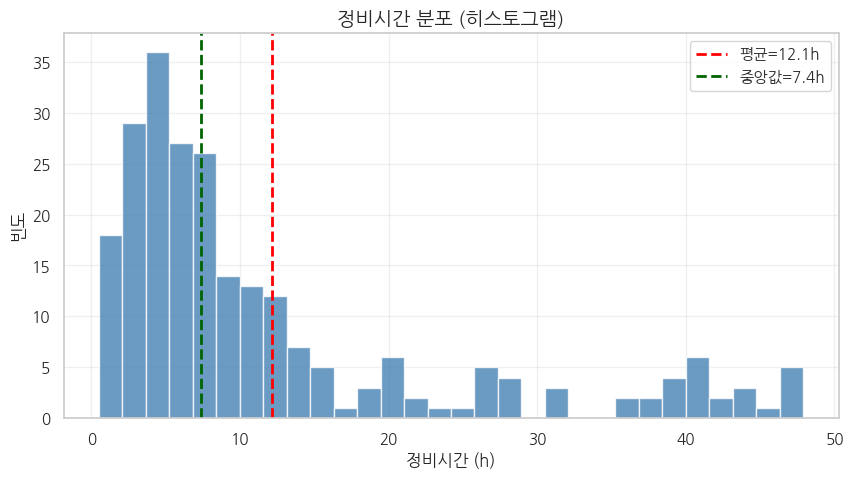

왜도(Skewness): 1.592
→ 오른쪽 꼬리 분포 (우측 치우침). 평균보다 중앙값이 더 대표적 ✅


In [61]:
plt.figure(figsize=(10, 5))
plt.hist(df['정비시간(h)'], bins=30,
         color='steelblue', edgecolor='white', alpha=0.8)

# 평균선과 중앙값선
mean_t   = df['정비시간(h)'].mean()
median_t = df['정비시간(h)'].median()
plt.axvline(mean_t,   color='red',      linestyle='--', linewidth=2, label=f'평균={mean_t:.1f}h')
plt.axvline(median_t, color='darkgreen',linestyle='--', linewidth=2, label=f'중앙값={median_t:.1f}h')

plt.title('정비시간 분포 (히스토그램)', fontsize=14, fontweight='bold')
plt.xlabel('정비시간 (h)'); plt.ylabel('빈도')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 분포 해석
skew = df['정비시간(h)'].skew()
print(f"왜도(Skewness): {skew:.3f}")
if skew > 1:
    print("→ 오른쪽 꼬리 분포 (우측 치우침). 평균보다 중앙값이 더 대표적 ✅")
elif skew < -1:
    print("→ 왼쪽 꼬리 분포 (좌측 치우침)")
else:
    print("→ 대체로 대칭 분포")

## 📊 왜도(Skewness) 1.592의 의미

**왜도(Skewness)는 "분포가 얼마나 한쪽으로 치우쳤는가"를 숫자로 나타낸 지표**예요. 0에 가까울수록 대칭이고, 절대값이 클수록 한쪽으로 꼬리가 길게 늘어진 모양입니다.

### 판정 기준

일반적으로 사용하는 경험 규칙은 이렇습니다:

| 왜도 값 | 분포 모양 | 해석 |
|---|---|---|
| `< -1` | 왼쪽 꼬리 길게 늘어짐 | 좌측 치우침(음의 왜도) |
| `-1 ~ -0.5` | 약간 좌측 치우침 | 살짝 비대칭 |
| `-0.5 ~ 0.5` | 거의 대칭 | 정규분포에 가까움 |
| `0.5 ~ 1` | 약간 우측 치우침 | 살짝 비대칭 |
| `> 1` | **오른쪽 꼬리 길게 늘어짐** | **강한 우측 치우침** |

지금 결과인 **1.592**는 마지막 구간에 해당해서 "강하게 오른쪽으로 꼬리가 늘어진 분포"라는 뜻입니다.

### 정비시간 데이터로 본 직관적 해석

히스토그램을 떠올리면:

```
빈도 │
     │ ▓▓▓
     │ ▓▓▓▓▓
     │ ▓▓▓▓▓▓▓
     │ ▓▓▓▓▓▓▓▓▓
     │ ▓▓▓▓▓▓▓▓▓▓▓▓
     │ ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▒▒▒▒▒▒▒░░░░  ← 오른쪽으로 길게 늘어진 꼬리
     └────────────────────────────────────→ 정비시간(h)
       (대부분 짧은 시간)              (가끔 매우 긴 정비)
```

대부분의 장비 정비는 **짧은 시간 안에 끝나는데**, 가끔 **엄청 오래 걸리는 정비 케이스(이상치)**가 일부 섞여 있어 오른쪽 꼬리를 길게 만든 것이에요. 부대 정비 데이터에서 매우 자연스러운 현상입니다 — 대부분은 일상적 점검·소수정비고, 일부는 중대고장이라 시간이 폭발적으로 늘어나죠.

### "평균보다 중앙값이 더 대표적" — 왜?

이게 이번 실습의 핵심 교훈입니다.

오른쪽 꼬리가 긴 분포에서는 소수의 큰 값(예: 정비시간 20시간짜리 중대고장 몇 건)이 **평균을 위로 끌어올립니다**. 반면 **중앙값은 순서상 한가운데 값**이라 이런 극단값에 흔들리지 않아요.

가상 예시로 보면:

- 정비시간 데이터: 1, 1, 2, 2, 2, 3, 3, 3, 4, **20** (시간)
- 평균 = 41 ÷ 10 = **4.1h** ← 단 한 건의 20h가 평균을 크게 끌어올림
- 중앙값 = (2+3)/2 = **2.5h** ← 실제 "보통" 정비시간에 훨씬 가까움

만약 지휘관에게 "우리 부대 평균 정비시간은 4.1시간입니다"라고 보고하면, 실제로는 대부분 2~3시간 안에 끝나는 현실을 왜곡하게 됩니다. 그래서 **우측 치우침 분포에서는 "중앙값"으로 보고하는 게 더 정직하고 실무적**이라는 거예요.

### 실무적 시사점 3가지

먼저, 이상치 관리가 중요합니다. 평균을 끌어올리는 그 긴 꼬리가 바로 "비정상적으로 오래 걸린 정비"이므로, 어떤 장비·어떤 고장유형에서 발생했는지 별도로 분석할 가치가 있습니다(Chapter 7의 인사이트 ③ 반복 고장 장비, 인사이트 ④ 가동불능 분석으로 이어지는 지점이에요).

다음으로, 보고서 작성 시 평균 대신 중앙값+사분위수(IQR)를 함께 쓰는 게 좋습니다. 박스플롯이 이런 분포에서 특히 효과적이고요(Chapter 4-3에서 배우는 바로 그 이유).

마지막으로, 수치형 변수가 한쪽으로 치우쳐 있으면 향후 머신러닝 단계에서 **로그 변환**(`np.log1p`) 같은 전처리를 고려하게 되는데, 이런 의사결정의 출발점이 바로 왜도 확인입니다.

요약하면 **"1.592 = 정비시간 데이터는 대부분 짧은 쪽에 몰려 있고, 가끔 매우 긴 정비 케이스가 평균을 위로 끌어올리는 비대칭 분포다. 따라서 부대에 보고할 때는 평균(mean)보다 중앙값(median)이 현실을 더 잘 대표한다"**는 의미입니다.

## 4-2. 월별 정비 건수 추이 — 선 그래프

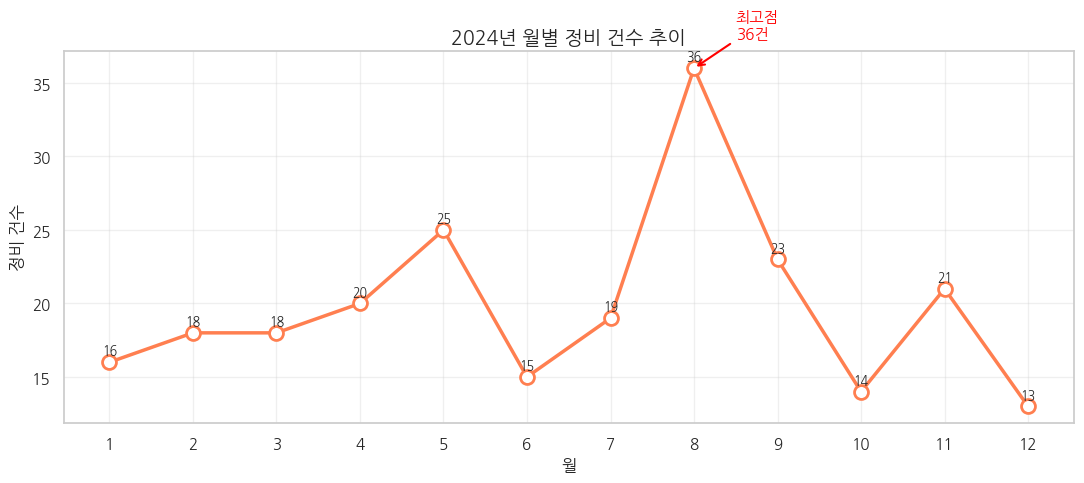

💡 최다 정비월: 8월 (36건)
   → 하계 훈련(6~8월) 후 누적 손모 원인으로 추정


In [62]:
monthly = df.groupby('월').size().reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly.values,
         marker='o', color='coral', linewidth=2.5, markersize=10,
         markerfacecolor='white', markeredgewidth=2, markeredgecolor='coral')

# 최대값 강조
peak_month = monthly.idxmax()
peak_value = monthly.max()
plt.annotate(f'최고점\n{peak_value}건',
             xy=(peak_month, peak_value),
             xytext=(peak_month + 0.5, peak_value + 2),
             fontsize=11, fontweight='bold', color='red',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# 각 지점에 값 표시
for m, v in monthly.items():
    plt.text(m, v + 0.5, str(v), ha='center', fontsize=9)

plt.title('2024년 월별 정비 건수 추이', fontsize=14, fontweight='bold')
plt.xlabel('월'); plt.ylabel('정비 건수')
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"💡 최다 정비월: {peak_month}월 ({peak_value}건)")
print(f"   → 하계 훈련(6~8월) 후 누적 손모 원인으로 추정")

## 4-3. 정비시간 박스플롯 — 이상치 시각화

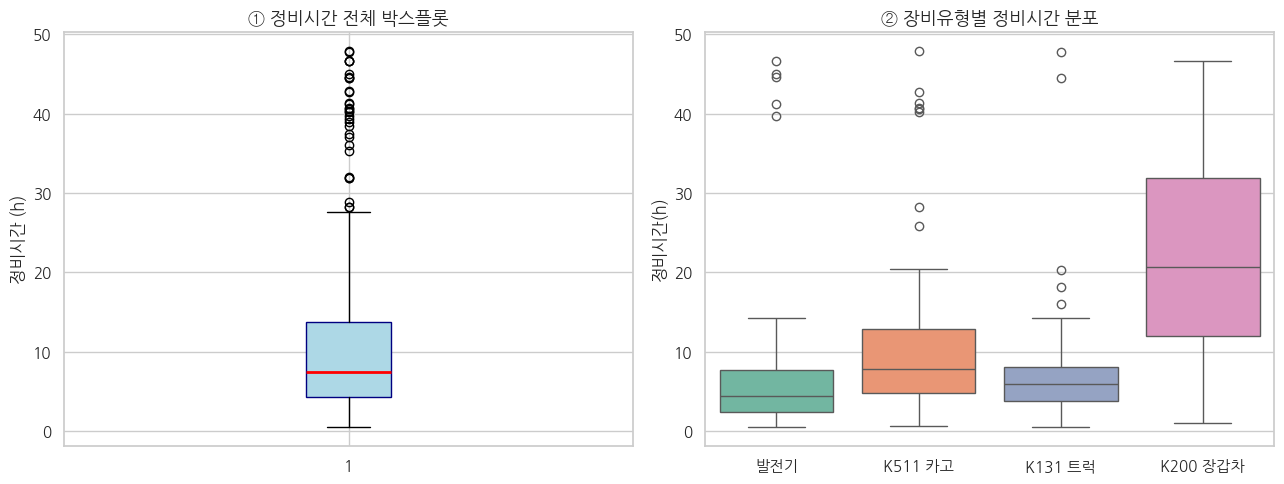

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 전체 박스플롯
axes[0].boxplot(df['정비시간(h)'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', edgecolor='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('① 정비시간 전체 박스플롯', fontsize=13, fontweight='bold')
axes[0].set_ylabel('정비시간 (h)')

# 장비유형별 박스플롯
sns.boxplot(data=df, x='장비유형', y='정비시간(h)',
            palette='Set2', ax=axes[1])
axes[1].set_title('② 장비유형별 정비시간 분포', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

## 📦 박스플롯 결과 해석 — 두 그림이 말하는 것

이 두 박스플롯은 정비시간 데이터의 **분포 구조**를 한눈에 보여주는 진단 도구예요. 그림 안에 어마어마하게 많은 정보가 압축돼 있는데, 하나씩 풀어서 읽어볼게요.

### 박스플롯 보는 법 다시 짚기

먼저 박스플롯의 각 부위가 뭘 의미하는지 정리하고 갈게요.

| 부위 | 의미 |
|---|---|
| **상자 아랫변** | Q1 (하위 25% 지점) |
| **상자 안의 가로선** | 중앙값 (Q2) |
| **상자 윗변** | Q3 (상위 25% 지점) |
| **상자의 높이** | IQR (가운데 50%의 폭) |
| **수염(whisker)** | 이상치가 아닌 정상 범위의 끝 |
| **수염 바깥의 동그라미** | 이상치 (1.5×IQR을 벗어난 점들) |

이걸 머릿속에 두고 두 그림을 읽어볼게요.

---

### ① 왼쪽 그림 — 정비시간 전체 박스플롯

**상자 자체의 위치와 모양**

상자가 대략 **4시간(Q1)에서 14시간(Q3) 사이**에 자리잡고 있고, 그 안의 **빨간 중앙값 선이 약 7~8시간 부근**에 그어져 있어요. 직전 셀에서 IQR 계산할 때 나왔던 `Q1=4.30h, Q3=13.75h`와 정확히 일치하는 모습입니다.

여기서 즉시 읽히는 두 가지 사실이 있어요. **첫째**, 상자 안에서 **중앙값 선이 정중앙이 아니라 아래쪽에 치우쳐** 있습니다. 빨간 선과 Q1 사이의 거리(약 3시간)가 빨간 선과 Q3 사이의 거리(약 6시간)보다 짧아요. 이는 **상자 내부에서도 분포가 비대칭**이라는 뜻이고, 부대 정비의 **중심부 50%조차도 우측으로 치우쳐 있다**는 신호입니다.

**둘째**, 수염의 길이도 비대칭이에요. 아래쪽 수염은 0 근처에서 끊기는데(정비시간이 음수일 수 없으니까), 위쪽 수염은 약 **28시간**까지 뻗어 있습니다. 정비시간 분포가 **위로 길게 끌려 있는 형태**라는 게 이 한 장의 그림으로 명확해져요.

**위쪽에 줄지어 선 동그라미들 — 핵심 메시지**

이 그림에서 가장 시선을 끄는 게 **30~50시간 구간에 몰려 있는 점들**입니다. 직전 셀에서 발견한 **31건의 이상치**가 바로 이 점들의 정체예요. 하나하나가 한 건의 정비 사례이고, 각각이 부대 자원에 큰 충격을 준 사건입니다.

특히 흥미로운 건 **이상치가 골고루 흩어진 게 아니라 30~48시간 구간에 빽빽하게 무리를 이룬다**는 점이에요. 만약 이상치가 단순한 입력 오류라면 무작위로 흩뿌려져야 하는데, 이렇게 군집을 이룬다는 건 **"긴 정비"라는 별도의 작업 카테고리가 실제로 존재**한다는 뜻입니다. 직전 분석에서 의심했던 "이중 모드 분포(짧은 일상 정비 + 긴 중정비)"가 시각적으로 확인되는 순간이에요.

---

### ② 오른쪽 그림 — 장비유형별 박스플롯

이 그림이 진짜 인사이트의 보고예요. 같은 정비시간 데이터인데 **장비유형으로 나눠서 다시 그렸을 뿐**인데도 보이는 그림이 완전히 달라집니다. 이게 EDA에서 **"한 차원 더 들어가서 보면 새로운 진실이 나타난다"**는 명제의 살아있는 예시예요.

#### 발전기 (왼쪽 첫 번째, 청록색)

상자가 가장 **납작하고 낮은 위치**에 있어요. 중앙값이 약 **4~5시간**, IQR도 매우 좁고(약 2~8시간), 수염도 14시간 부근에서 깔끔하게 끝납니다. **이상치가 거의 없는** 정직한 분포예요.

해석하면 — **발전기 정비는 표준화돼 있고 예측 가능합니다.** 정비병이 작업 일정을 짤 때 "발전기 1건 = 5시간"으로 잡으면 거의 빗나가지 않아요. 부품도 비교적 단순하고 고장 패턴도 정형화돼 있다는 의미죠. 부대 입장에서 가장 **관리하기 쉬운 장비군**입니다.

#### K511 카고 (왼쪽 두 번째, 주황색)

중앙값이 약 **8시간**으로 발전기보다 한 단계 위에 자리합니다. 상자 높이는 비교적 보통이고, 위쪽으로 **40시간대 이상치가 3~4건** 보여요. 수염도 약 20시간까지 뻗어 있고요.

해석 — **K511 카고는 평소엔 무난하지만 가끔 큰 사고를 친다.** 대부분의 정비는 5~13시간 안에 끝나는데, 한 번씩 변속기·엔진같은 중요 부품에 문제가 생기면 40시간을 넘기는 케이스가 발생해요. 직전 분석에서 본 K511의 "변속기 결함(42.7시간)", "엔진 이상(40.2시간)"이 바로 이 위쪽 점들이에요.

#### K131 트럭 (왼쪽 세 번째, 보라색)

K511과 비슷해 보이지만 자세히 보면 차이가 있어요. 상자는 K511보다 작고(약 4~9시간), 중앙값은 6시간 정도로 더 낮습니다. 다만 위쪽으로 **약 15~28시간 구간에 작은 이상치 무리**가 있어요. 40시간을 넘는 극단적 이상치는 거의 없습니다.

해석 — **K131은 K511보다 덜 위험하지만, 중간 강도의 이상치가 꾸준히 발생**합니다. 한방에 큰 사고를 치진 않지만, 예상보다 길어지는 정비가 종종 있다는 뜻이에요. 부품 수급 안정성이나 정비 매뉴얼의 명확성이 K511보다 좋은 편인 것 같습니다.

#### K200 장갑차 (오른쪽 끝, 분홍색) — 이 그림의 주인공

다른 세 박스플롯과 **완전히 다른 행성에서 온 그래프**처럼 보입니다.

상자 자체가 **약 12시간(Q1)부터 32시간(Q3)까지** 뻗어 있어요. 발전기·K131의 상자 전체보다 K200의 Q1이 더 높습니다. 즉, **K200 정비의 가장 짧은 25%조차도 다른 장비의 평균보다 훨씬 길다**는 의미예요.

중앙값은 약 **20~21시간**. 발전기 중앙값(4~5시간)의 **4배**에 달해요. 수염은 1시간 부근부터 47시간 부근까지, **거의 데이터의 전 범위를 한 장비가 차지**하는 모습입니다.

흥미로운 점은 K200에는 **"이상치"라고 표시된 동그라미가 거의 없다**는 거예요. 다른 장비에서는 30시간 넘는 정비가 명백한 이상치인데, K200에서는 30시간이 **정상 범위의 일상**입니다. 통계학이 보는 시각으로 — K200의 분포 자체가 다른 장비들과 본질적으로 다른 모집단이라는 거죠.

해석 — **K200 장갑차는 부대 정비 자원의 블랙홀입니다.** 한 번 정비대에 올라가면 평균 20시간, 길면 47시간이 걸리는, 다른 장비들과 차원이 다른 작업 부담을 안고 있어요. 직전 분석에서 봤던 "K200 궤도 마모 46.7시간"이 단발 사건이 아니라, 이 장비의 **구조적 특성**이라는 게 분명해집니다.

이게 합리적이긴 해요. K200은 무게 13톤급 장갑차로, 궤도·서스펜션·동력계가 일반 차량과 비교할 수 없을 만큼 복잡합니다. 한 부품을 떼어내려면 다른 부품 여러 개를 먼저 분해해야 하고, 부품 자체도 무겁고 비싸요. 정비시간이 길 수밖에 없는 **물리적·공학적 필연**이 있는 거죠.

---

### 두 그림을 같이 봤을 때 드러나는 진실

**왼쪽만 봤을 때는** "정비시간 분포가 우측 치우침이고 이상치가 많네" 정도의 결론이었어요. 그런데 **오른쪽까지 같이 보면** 전혀 다른 그림이 나옵니다.

왼쪽의 "이상치"는 **임의의 사고가 아니라 K200 장갑차라는 특정 장비군의 정상 분포**였어요. 즉, 정비시간 분포가 통계적으로 비대칭이었던 게 아니라, **다른 종류의 장비 분포 4개가 강제로 한 그래프에 합쳐져서 그렇게 보였던 것**이죠.

이걸 통계학에서는 **심슨의 역설(Simpson's Paradox)** 의 친척 격인 현상이라고 봐요. 합쳐진 데이터에서 보이는 패턴이 그룹별로 쪼개면 전혀 다르게 나타나는 현상. EDA에서 다변량 분석이 왜 필수인지를 보여주는 교과서적 사례입니다.

### 부대 운영에 시사하는 4가지 실무 결론

**첫째, 장비별로 정비 일정 표준이 달라야 합니다.** 발전기 1건당 5시간, K131 6~8시간, K511 8~10시간, K200 20~25시간을 기준선으로 삼아 인력·시간 자원을 배정해야 해요. 모든 정비를 똑같이 "1건"으로 세는 현행 방식은 K200을 만지는 정비반에 부당한 부담을 줍니다.

**둘째, K200 전담반의 필요성이 데이터로 입증됩니다.** 중앙값 20시간의 정비를 일반 정비반에 끼워넣으면 다른 작업이 모두 밀려요. K200을 전문적으로 다루는 별도 정비조직과 부품 비축을 갖추는 게 효율적입니다.

**셋째, K511의 "가끔 터지는 큰 사고"는 예방 가능성이 있습니다.** K511의 박스 자체는 양호한데 위쪽 이상치 몇 건이 평균을 끌어올리는 패턴이에요. 이 이상치들의 고장 유형(변속기·엔진 등)을 추적해 예방 점검 강화로 발생률을 낮추면, 부대 전체 정비 부담이 의미 있게 줄어듭니다.

**넷째, 발전기의 안정성을 다른 장비 정비 표준화의 모델로 삼을 만합니다.** 왜 발전기 정비는 이렇게 일관성 있을까? 매뉴얼? 부품 표준화? 정비병 숙련도? 그 노하우를 분석해 다른 장비에 이식하는 게 부대 정비 체계 개선의 또 다른 길이에요.

---

### 색상 선택에 대한 한 가지 메모

오른쪽 그래프는 `palette='Set2'`로 칠해져 있는데, 이 팔레트는 **각 카테고리에 시각적으로 구분되지만 어느 하나도 튀지 않는** 디자인이에요. 보고서용으로 적절한 선택입니다. 만약 K200을 강조하고 싶다면 K200만 빨간색으로 따로 칠하는 식의 변형도 가능해요.

다만 한 가지 살짝 아쉬운 점은, **왼쪽 그림(전체)과 오른쪽 그림(장비별)이 색상 코드가 연결되지 않는다**는 거예요. 왼쪽의 lightblue 박스와 오른쪽의 4가지 색이 무관해서, 두 그림이 같은 데이터를 다른 각도로 본 것이라는 시각적 단서가 약합니다. 이건 본 셀의 한계라기보다는, 시각화 고도화의 다음 단계 아이디어로 두면 좋을 부분이에요.

---

### 다음 분석으로 자연스럽게 이어지는 질문들

이 그림을 본 사람이라면 자연스럽게 다음 질문이 떠오를 거예요:

"K200 장갑차의 정비시간이 길면 비용도 그만큼 더 들까?" → **Chapter 5-1 장비유형별 평균 정비비용**에서 확인.

"정비시간과 비용의 관계는 얼마나 강할까?" → **Chapter 5-2 상관관계 + 산점도**에서 정량화.

"K200 안에서도 어떤 고장 유형이 가장 길게 만들까?" → **Chapter 5-3 피벗 테이블**로 분해.

"K200을 시간대별로 나눠보면 8월에 또 몰릴까?" → **Chapter 5-3 월×장비유형 히트맵**에서 검증.

박스플롯이 발견한 "K200이 다르다"는 사실이, 이후 모든 다변량 분석의 출발점이 되는 거죠.

요약하면 이 두 그림은 **"정비시간 데이터의 비대칭성과 이상치는 사실 K200 장갑차라는 특정 장비군의 구조적 특성에서 비롯된 것이며, 부대 정비 자원의 가장 큰 단일 변수는 K200의 존재 자체"**라는 결론을 한 화면으로 보여주고 있어요. 단변량 분석에서 다변량 분석으로 넘어가는 결정적 다리이자, 부대 정비 체계 개선 논의의 출발점이 되는 그림입니다.

---
### 🔥 실습문제 4 - 단변량 분석
1. **정비비용** 분포의 **히스토그램** (bins=30) + 평균·중앙값선
2. **분기별(Q1~Q4)** 정비 건수 막대그래프
3. **장비유형별 정비비용** 박스플롯
4. **요일별** 정비 건수를 막대그래프로 시각화 (월~일 순)

In [38]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

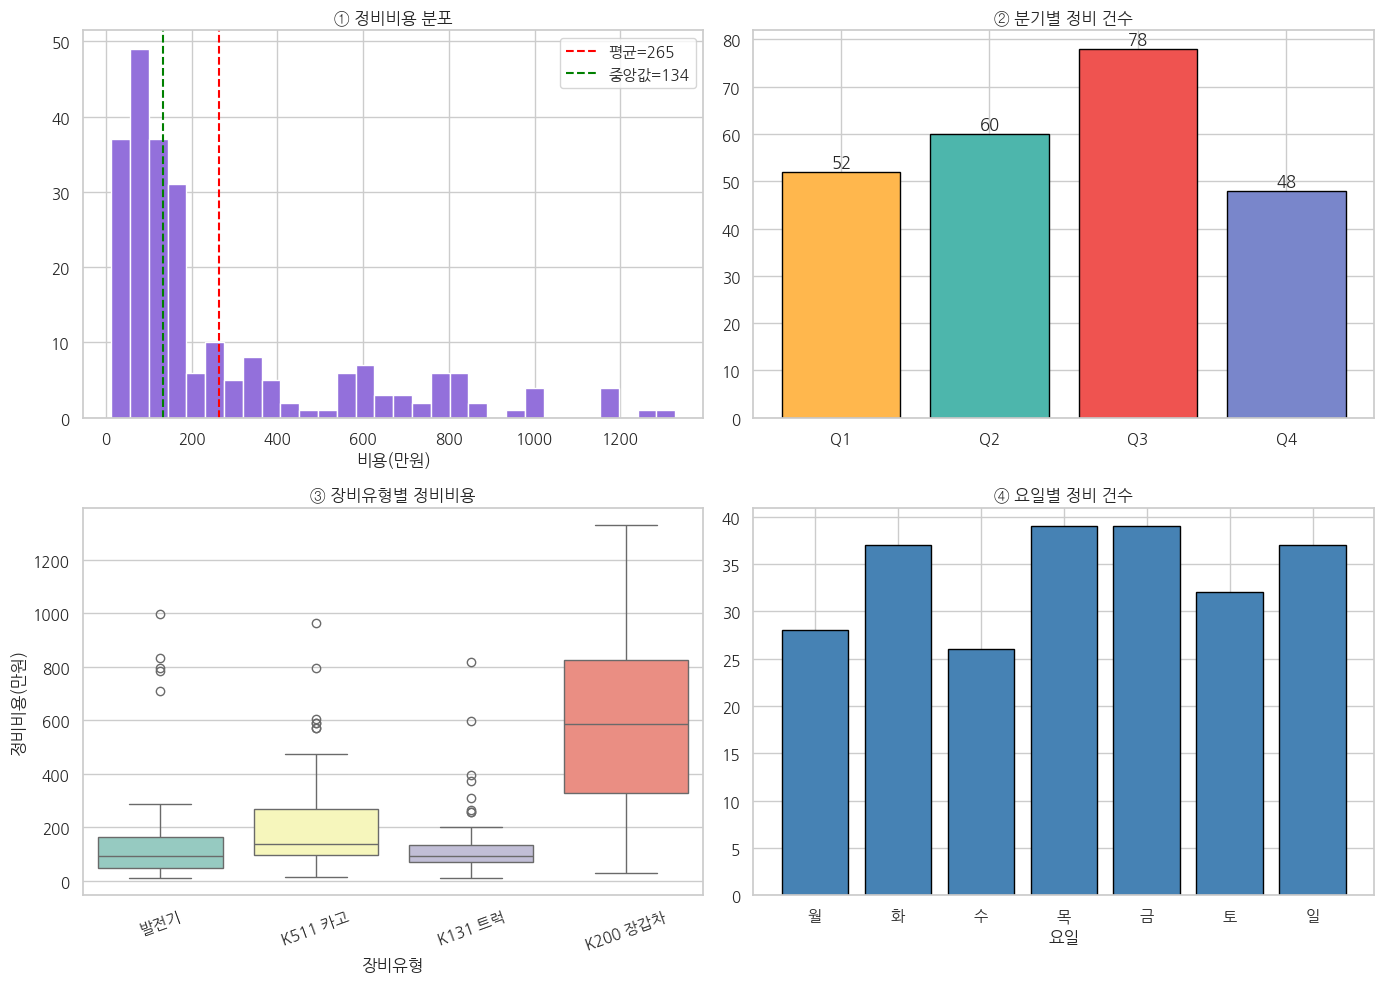

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) 정비비용 히스토그램
axes[0,0].hist(df['정비비용(만원)'], bins=30,
               color='mediumpurple', edgecolor='white')
m = df['정비비용(만원)'].mean()
md_v = df['정비비용(만원)'].median()
axes[0,0].axvline(m, color='red', linestyle='--', label=f'평균={m:.0f}')
axes[0,0].axvline(md_v, color='green', linestyle='--', label=f'중앙값={md_v:.0f}')
axes[0,0].set_title('① 정비비용 분포', fontweight='bold')
axes[0,0].set_xlabel('비용(만원)'); axes[0,0].legend()

# 2) 분기별 정비 건수
q_cnt = df.groupby('분기').size()
bars = axes[0,1].bar(q_cnt.index, q_cnt.values,
                     color=['#FFB74D','#4DB6AC','#EF5350','#7986CB'], edgecolor='black')
for bar, v in zip(bars, q_cnt.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                   str(v), ha='center', fontweight='bold')
axes[0,1].set_title('② 분기별 정비 건수', fontweight='bold')
axes[0,1].set_xticks([1,2,3,4])
axes[0,1].set_xticklabels(['Q1','Q2','Q3','Q4'])

# 3) 장비유형별 비용 박스플롯
sns.boxplot(data=df, x='장비유형', y='정비비용(만원)',
            palette='Set3', ax=axes[1,0])
axes[1,0].set_title('③ 장비유형별 정비비용', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=20)

# 4) 요일별 정비 건수
weekday_order = ['월','화','수','목','금','토','일']
wd_cnt = df['요일_한글'].value_counts().reindex(weekday_order, fill_value=0)
axes[1,1].bar(wd_cnt.index, wd_cnt.values, color='steelblue', edgecolor='black')
axes[1,1].set_title('④ 요일별 정비 건수', fontweight='bold')
axes[1,1].set_xlabel('요일')

plt.tight_layout()
plt.show()

## 📊 4종 차트 종합 분석 — 부대 정비의 4가지 얼굴

이 셀은 단변량 분석의 종합 정리에 해당하는 **4-in-1 시각화**예요. `subplots(2, 2)`로 한 화면에 4개 차트를 동시에 띄워 정비 데이터의 다른 차원들을 한 번에 비교할 수 있게 해주는 구성이고, 각 차트가 던지는 메시지가 모두 다르면서도 서로 보완 관계예요. 하나씩 깊게 읽어볼게요.

---

### ① 정비비용 분포 (좌상단 히스토그램) — 비용의 진실

**가장 충격적인 그림입니다.** 평균=265만원과 중앙값=134만원, 두 선이 거의 두 배 차이로 떨어져 있어요. 이게 무엇을 의미하는지 곱씹어볼 가치가 있습니다.

분포를 보면 **0~200만원 구간**에 막대들이 빽빽하게 몰려 있어요. 가장 높은 막대는 50~100만원 구간으로 약 49건이고, 그 다음이 100~150만원 구간 약 37건, 0~50만원 구간 약 37건이에요. 즉 **전체 정비의 절반 이상이 200만원 미만**에서 끝납니다.

그런데 오른쪽으로 눈을 돌리면 **600만원, 800만원, 1000만원, 1200만원**까지 점점이 막대들이 흩어져 있어요. 한 건이지만 1300만원짜리 정비도 있고요. 이 소수의 고비용 정비들이 평균을 134만원에서 265만원으로 끌어올린 주범입니다.

**평균과 중앙값의 격차가 1.98배**라는 게 핵심이에요. 정비시간 분포의 왜도가 1.59였는데, 비용 분포는 시각적으로 **그보다 더 강한 우측 치우침**을 보여줍니다. 비용의 왜도를 계산하면 아마 2.5~3 사이가 나올 거예요.

이 그림이 부대 보고에 시사하는 바는 명확합니다. **"우리 부대 평균 정비비용은 265만원입니다"라고 보고하면 거짓말에 가까워요.** 정비 100건 중 절반이 134만원 미만에서 끝나는데, 평균은 265만원이라고 말하면 듣는 사람은 "보통 정비가 265만원쯤 든다"고 받아들이거든요. **"중앙값 134만원, 다만 일부 고비용 정비가 평균을 265만원까지 끌어올림"**이라고 함께 말해야 정직한 보고가 됩니다.

또 하나, 1000만원을 넘는 정비가 **이산적으로 4~5건 띄엄띄엄** 있다는 점도 의미 있어요. 이게 단순한 이상치가 아니라 **"부대 정비에는 백만원대 일상 정비와 천만원대 중정비라는 두 종류가 존재한다"**는 신호일 수 있습니다. 박스플롯에서 봤던 K200의 분포가 여기서도 비용 차원으로 다시 모습을 드러내는 거예요.

---

### ② 분기별 정비 건수 (우상단 막대그래프) — 계절성의 정량화

이전 셀에서 본 월별 추이를 분기 단위로 묶은 그림입니다. **Q3(7~9월)이 78건으로 압도적**이고, Q2 60건, Q1 52건, Q4 48건이에요.

**Q3가 다른 분기들보다 30~60% 많다는 게 핵심**입니다. 1년을 단순히 4등분해서 본다면 분기당 60건이 평균인데, Q3만 거의 80건이고 나머지는 50건 안팎이죠. 즉 **부대 연간 정비 작업의 약 1/3이 Q3 단 3개월에 몰립니다**(78 ÷ 238 ≈ 33%).

이 분기별 패턴은 월별 그래프(8월 피크)가 분기 차원으로 확대 재생산된 거예요. 그런데 분기로 봤을 때 추가로 드러나는 정보가 있습니다.

**Q1 → Q2 → Q3로 점진적 증가, Q3 → Q4로 급감**이라는 흐름이에요. 부대 운용 사이클을 떠올려보면 자연스럽습니다. Q1은 동계 훈련의 끝물이라 누적 손모가 일부 발생, Q2는 봄 정비 시즌이 본격화되며 점차 증가, Q3에는 하계 훈련 직후 누적 손모가 폭발, Q4에는 동계 진입 전 점검 모드로 줄어드는 흐름이죠.

다만 한 가지 주의할 점은, **이 패턴이 단일 연도(2024년) 데이터에서 나온 것**이라는 거예요. 다년간 데이터로 검증하기 전에는 "이 부대의 영구적 패턴"이라기보다 "2024년에 관찰된 패턴"이라고 표현하는 게 정직합니다. 만약 2025·2026년에도 같은 Q3 피크가 반복된다면 그때 비로소 **"이 부대의 구조적 계절성"**이라고 결론 내릴 수 있어요.

색상 선택도 짚어볼 만합니다. Q3에 빨간색(#EF5350)을 쓴 게 의도적이에요. **"가장 부담이 큰 분기"라는 메시지를 색으로 강조**하는 방식이죠. 막대 위 숫자도 굵게 표시(`fontweight='bold'`)해서 정확한 값을 한눈에 볼 수 있게 했고요.

---

### ③ 장비유형별 정비비용 박스플롯 (좌하단) — 비용의 K200 효과

이 그림은 직전 셀의 **정비시간 박스플롯과 거의 똑같은 패턴**을 비용 차원에서 다시 한번 보여줍니다. 같은 결론이 시간과 비용 두 차원에서 모두 확인된다는 건, K200의 특수성이 우연이 아니라 **구조적 사실**임을 강력히 입증해요.

**발전기**: 중앙값 약 100만원, 상자가 50~200만원 사이에 자리. 이상치가 4~5건 위쪽으로 보이는데(700~1000만원 구간), 이건 발전기 정비 중에서 예외적으로 비싼 케이스들이에요. 평소엔 저렴하지만 가끔 큰 부품을 갈아야 할 때가 있다는 신호.

**K511 카고**: 중앙값 약 130만원, 상자가 100~280만원 정도로 발전기보다 한 단계 위. 이상치가 600~970만원 구간에 5~6건 분포해요. 정비시간 박스플롯에서 봤던 "가끔 터지는 큰 사고" 패턴이 비용에서도 동일하게 재현됩니다.

**K131 트럭**: 가장 흥미로운 박스예요. 상자 자체는 작고(약 70~150만원) 중앙값도 100만원 부근으로 낮은데, **이상치가 200~600만원 구간에 7~8건**이나 흩어져 있어요. 이게 무슨 뜻이냐면 — **K131의 "보통" 정비는 매우 저렴한데, 한 번 비싸지면 보통의 5~6배까지 튄다**는 거예요. 비용 변동성이 가장 큰 장비입니다. 부품 가격이 양극화돼 있거나(소모품은 싸고 핵심 부품은 비싸고), 고장 유형의 분포가 이중 모드일 가능성이 있어요.

**K200 장갑차**: 다시 한번 다른 차원의 분포입니다. 상자 자체가 **약 320만원~830만원**, 중앙값이 약 590만원이에요. 발전기 중앙값(100만원)의 **거의 6배**, K511의 4.5배입니다. 게다가 위쪽 수염은 1300만원 부근까지 뻗고, 아래쪽 수염도 약 50만원까지 내려가요. **변동 폭만 1250만원**입니다. 이상치 표시가 거의 없는 것도 직전 시간 박스플롯과 같은 이유예요 — K200에서는 600~1300만원이 정상 범위입니다.

**시간 박스플롯과 비용 박스플롯을 겹쳐 보면** 매우 강력한 결론이 나옵니다: **K200은 정비시간도 길고 정비비용도 비싸다.** 이 두 변수가 강한 양의 상관을 보일 거라는 예측이 자연스럽게 나오고, 이게 다음 챕터(Chapter 5-2 상관관계 분석)로 연결되는 자연스러운 다리예요.

---

### ④ 요일별 정비 건수 (우하단 막대그래프) — 의외의 평탄함

이 그림이 가장 **반전 있는** 결과예요. 보통 군부대 정비라고 하면 평일에 몰리고 주말은 적을 것 같은데, 데이터는 다른 그림을 보여줍니다.

목·금이 39건씩으로 가장 많고, 화요일과 일요일이 37건, 토요일 32건, 월요일 28건, 수요일 26건이에요. **요일별 편차가 26~39건 사이로 의외로 균등**합니다. 가장 많은 목·금과 가장 적은 수요일의 차이가 1.5배 정도인데, 분기별 격차(Q3 78 vs Q4 48, 1.6배)와 비슷한 수준이지만 의미는 완전히 달라요.

**관찰 1 — 주말이 줄지 않는다.** 토요일 32건, 일요일 37건은 평일 평균과 거의 같은 수준이에요. 이는 부대 정비가 **5일제 근무가 아닌 상시 운영 체제**임을 시사합니다. 군 특성상 당연한 결과지만, 데이터로 확인되니 인상적이죠. 일요일이 토요일보다 오히려 많은 건 토요일에 발견된 고장이 일요일에 처리되는 패턴일 수도 있어요.

**관찰 2 — 월요일·수요일이 가장 적다.** 월요일이 적은 건 흔히 보이는 패턴(주말에 누적된 일이 화·목으로 분배)이라 이해되지만, **수요일이 가장 적은 건 흥미롭습니다**. 부대 운영상 수요일에 정기 훈련이나 회의가 있어 정비 작업을 의도적으로 피하는 일정 관행이 있을 수 있어요. 또는 화요일에 집중적으로 처리하고 목요일에 다시 시작하는 작업 흐름이거나요.

**관찰 3 — 목·금에 살짝 몰린다.** 주말 직전 처리 압박이 있을 수 있습니다. "이번 주 안에 끝내자"는 운영적 동기, 또는 주말 작전 대비 사전 점검 강화의 결과로 해석 가능해요.

다만 이 모든 해석은 어디까지나 **가설**입니다. 요일별 차이가 통계적으로 유의미한지 검증하려면 카이제곱 검정 같은 통계 검증이 필요해요. 시각적으로는 차이가 있어 보여도 표본 크기에 비해 우연 변동의 범위 안일 수 있거든요.

**부대 운영 시사점**으로 정리하면 — 정비 작업 일정이 요일에 크게 의존하지 않으므로 **요일별 인력 배치는 균등하게**, 다만 약간의 차등(수요일 ↓, 목·금 ↑)을 두는 게 효율적일 수 있습니다.

---

### 4개 차트가 함께 던지는 메시지

각 차트를 따로 보면 단편적 사실이지만, 4개를 동시에 보면 **부대 정비의 종합 프로필**이 그려집니다.

먼저 **"비용 측면의 위험 분포"**가 보여요. ①번에서 평균과 중앙값의 큰 격차로 비용 분포가 강하게 우측 치우침을 확인했고, ③번에서 그 우측 꼬리의 정체가 K200 장갑차임을 분해해서 봤습니다. 즉 **부대 정비 비용 위험은 K200에 집중**돼 있다는 결론.

다음으로 **"시간적 부담의 분포"**예요. ②번 분기별 차트는 Q3에 부담이 몰린다는 시간적 집중을 보여주고, ④번 요일별 차트는 그 부담이 한 주 안에서는 골고루 분산된다는 미시적 균형을 보여줍니다. **장기(분기) 차원에서는 집중적이지만 단기(주) 차원에서는 분산적**인 이중 구조죠.

종합하면 부대 정비 운영의 **두 가지 핵심 변수**는 (1) **장비 유형(특히 K200의 비중)** 과 (2) **계절(특히 Q3의 집중)** 입니다. 인력·예산·부품 비축 계획은 이 두 축을 따라 설계돼야 한다는 게 데이터가 가리키는 방향이에요.

---

### 시각화 코드의 디자인 노트 한 가지

이 4-in-1 차트의 구성에 대해 **차트 종류 선택**이 흥미로워요:

| 위치 | 변수 | 차트 종류 | 선택 이유 |
|---|---|---|---|
| ① | 정비비용(수치형) | 히스토그램 | 분포의 모양·치우침 확인 |
| ② | 분기(범주형) | 막대그래프 | 카테고리별 양 비교 |
| ③ | 장비×비용 | 박스플롯 | 그룹별 분포 비교 |
| ④ | 요일(범주형) | 막대그래프 | 카테고리별 양 비교 |

**데이터 타입에 따라 차트가 결정**되는 원칙이 그대로 적용된 거예요. Chapter 6의 "차트 선택 가이드"가 사실 이 코드에 이미 자연스럽게 녹아 있는 셈입니다. 좋은 EDA는 차트 종류를 의식하지 않고도 데이터 타입을 보면 적절한 차트가 자동으로 떠오르는 단계가 목표예요.

---

### 한 가지 발전 아이디어 — 비용을 로그 스케일로

①번 히스토그램에서 우측의 1000만원대 데이터들이 너무 띄엄띄엄해서 그 영역의 패턴이 잘 안 보여요. 이런 강한 우측 치우침 분포에서는 **로그 스케일 히스토그램**이 더 정보 가치가 높습니다:

```python
axes[0,0].hist(np.log10(df['정비비용(만원)']), bins=30)
```

이렇게 하면 1만원~1300만원이 0~3 범위로 압축되면서 분포의 세부 모양이 훨씬 잘 보여요. 다만 보고서용으로는 일반인이 직관적으로 읽기 어려우니, **분석용 차트와 보고용 차트를 따로 만드는 것**이 실무 패턴입니다. 분석은 로그 스케일로 깊이 들여다보고, 보고는 원래 스케일로 단순하게.

요약하면 이 한 화면이 **"부대 정비의 비용·시간·시기·요일이라는 4개 차원에서의 부담 구조를 동시에 진단"**해주고 있어요. 각 차트는 독립적인 정보를 주지만, 4개를 함께 봤을 때 비로소 **"K200×Q3"이라는 부대 정비 위험의 핵심 좌표**가 도출됩니다. 단변량 분석이 끝나는 지점에서 다변량 분석이 왜 필요한지를 자연스럽게 보여주는 마무리예요.

---
# 🔗 Chapter 5. [Step 5] 다변량 분석 (Multivariate Analysis)

> **두 개 이상** 의 변수 간 **관계** 를 분석하는 단계  
> → groupby, 상관분석, heatmap이 주력 도구

## 5-1. 장비유형별 평균 정비비용 — 수평 막대그래프

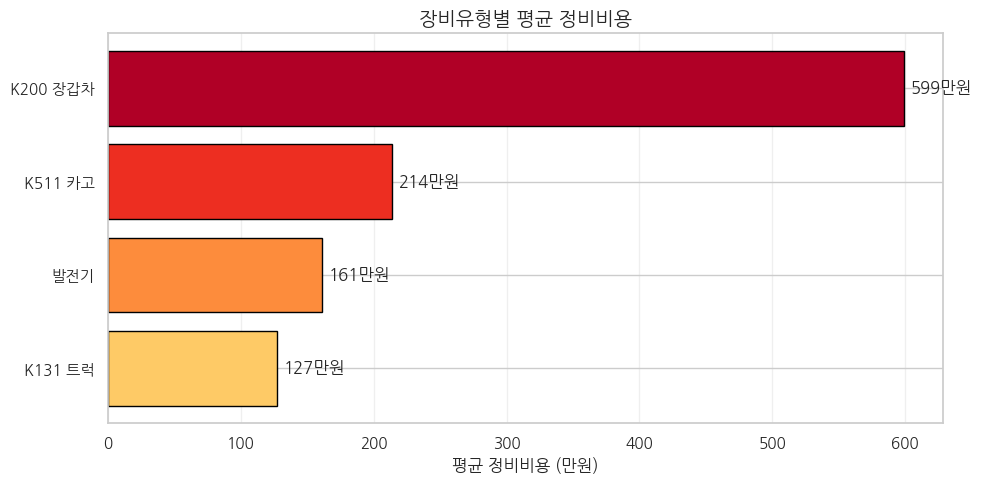

💡 K200 장갑차 비용이 K131 트럭의 4.7배


In [65]:
equip_cost = df.groupby('장비유형')['정비비용(만원)'].mean().sort_values()

plt.figure(figsize=(10, 5))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(equip_cost)))
bars = plt.barh(equip_cost.index, equip_cost.values,
                color=colors, edgecolor='black')

# 막대 끝에 값 표시
for bar, v in zip(bars, equip_cost.values):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{v:.0f}만원', va='center', fontweight='bold')

plt.title('장비유형별 평균 정비비용', fontsize=14, fontweight='bold')
plt.xlabel('평균 정비비용 (만원)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 해석
max_equip = equip_cost.idxmax()
min_equip = equip_cost.idxmin()
ratio = equip_cost.max() / equip_cost.min()
print(f"💡 {max_equip} 비용이 {min_equip}의 {ratio:.1f}배")

## 💰 장비유형별 평균 정비비용 — 한 줄로 요약되는 결정적 진실

이 셀은 EDA의 다변량 분석 첫 번째 그림이에요. 직전까지의 박스플롯들이 **분포의 모양 전체**를 보여줬다면, 이 그림은 **각 그룹의 대표값(평균)만 추려서** 깔끔한 비교를 만들어내는 단계입니다. 정보 밀도는 낮아지지만 메시지 전달력은 극대화되는, 보고서 표지에 자주 등장하는 형식의 차트예요.

---

### 데이터 한 줄이 만든 결정적 그림

**`equip_cost = df.groupby('장비유형')['정비비용(만원)'].mean().sort_values()`**

이 한 줄이 그림의 모든 것을 만들어냅니다. 풀어보면:

먼저 `groupby('장비유형')`으로 4개 장비군을 나누고, `['정비비용(만원)']`으로 그중 비용 컬럼만 선택해, `.mean()`으로 그룹별 평균을 계산한 뒤, `.sort_values()`로 작은 값부터 큰 값 순으로 정렬했어요. 정렬 순서가 중요한데 — 수평 막대그래프(`barh`)는 위에서 아래로 그려지므로 오름차순 정렬을 하면 **위로 갈수록 큰 값**이 오는 자연스러운 시각이 됩니다(반대로 정렬하면 거꾸로 그려짐).

이 한 줄에 담긴 패턴 — **`groupby → 컬럼선택 → 집계함수 → 정렬`** — 은 Pandas로 데이터를 분석할 때 가장 자주 쓰는 4단 콤보예요. 이 한 패턴만 익숙해지면 EDA의 90%는 그릴 수 있습니다.

---

### 색상 그라데이션의 영리한 선택

**`colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(equip_cost)))`**

색상 선택이 의도적이에요. `YlOrRd`는 노랑→주황→빨강으로 이어지는 컬러맵으로, 대표적인 **순차형(sequential) 팔레트**입니다. 이 팔레트는 "값이 클수록 색이 강해진다"는 직관적 매핑을 자연스럽게 만들어줘요.

`np.linspace(0.3, 0.9, 4)`로 4개 색상을 균등하게 뽑되, 0~1 양 끝(너무 옅거나 너무 짙음)을 피해 0.3~0.9 구간만 사용했어요. 이건 시각화의 **고급 디테일**입니다. 너무 옅은 노랑은 가독성이 떨어지고 너무 짙은 빨강은 답답해 보이거든요.

결과적으로 K131(가장 저렴) = 옅은 노랑, K200(가장 비쌈) = 진한 빨강이 자동으로 매핑됐습니다. **위험도가 높은 항목이 빨갛게 보이는** 시각적 직관과 정확히 일치하는 컬러 코딩이에요.

---

### 결과 숫자가 보여주는 충격적 격차

| 장비유형 | 평균 비용 | 가장 저렴한 장비 대비 |
|---|---|---|
| K131 트럭 | 127만원 | 1.0배 (기준) |
| 발전기 | 161만원 | 1.27배 |
| K511 카고 | 214만원 | 1.69배 |
| **K200 장갑차** | **599만원** | **4.7배** |

이 표가 던지는 메시지는 명확하면서도 충격적이에요. **K200 장갑차의 평균 정비비용은 K131 트럭의 4.7배**입니다. 다른 모든 장비는 100~250만원 사이의 좁은 구간에 모여 있는데, K200만 600만원에 가까운 값으로 **혼자만 다른 차원**에 있어요.

직전 박스플롯 분석에서 봤던 패턴이 **하나의 숫자로 압축**되는 순간입니다. 박스플롯은 분포의 풍부함을 다 보여주지만, 의사결정자에게 "그래서 결론이 뭐냐?"고 한 번에 답하기 어려워요. 이 막대그래프는 그 질문에 한 줄로 답합니다 — **"K200이 다른 장비의 5배 비용"**.

---

### 4.7배가 의미하는 부대 운영의 실제

이 비율을 부대 살림에 환산해보면 더 와닿습니다.

**가상 시나리오 ①** — K131 트럭 정비 1건 = 발전기 정비 1.27건. 비슷한 부담입니다. 만약 K131 정비 100건의 예산이 1.27억원이라면, 같은 예산으로 발전기는 약 79건을 정비할 수 있어요. **실용적 등가 관계**가 성립합니다.

**가상 시나리오 ②** — K200 정비 1건 = K131 정비 4.7건. 즉 K200을 한 번 정비대에 올리는 비용으로 **K131 트럭 4~5대를 정비**할 수 있어요. 부대 입장에서 K200 한 대의 정비를 미루면 K131 4~5대 분량의 예산 부담이 사라지는 구조죠.

**가상 시나리오 ③** — 만약 부대에 K200이 5대, K131이 5대 있다면? 같은 횟수 정비를 받는다고 가정해도 K200 정비비가 K131의 4.7배니까, **K200 5대가 부대 정비예산의 약 80%**를 흡수합니다. 장비 보유 대수가 같아도 예산 배분은 극도로 비대칭이라는 의미예요.

이게 단순한 "K200이 비싸다"의 문제가 아니라 **부대 예산 구조 자체가 K200 한 종에 의해 결정되는 종속 관계**라는 사실을 드러냅니다.

---

### 평균값이라는 한계, 그리고 박스플롯이 필요한 이유

이 차트의 가장 큰 약점은 **평균만 보여준다**는 것이에요. 평균은 강력한 요약 통계지만, 정보 손실이 큽니다.

K200의 평균 599만원이 의미하는 게 정확히 무엇일까요? "모든 K200 정비가 600만원쯤 한다"는 뜻이 아니에요. 직전 셀의 박스플롯에서 본 K200의 분포를 떠올리면 — 중앙값 590만원, 상자(Q1~Q3)가 320~830만원, 수염은 약 50만원에서 1300만원까지. 즉 **"K200 정비 비용은 50만원에서 1300만원까지 매우 넓게 흩어져 있고, 그 평균이 우연히 599만원"**인 거예요.

이 점이 시사하는 건 **막대그래프와 박스플롯이 짝을 이뤄 보고돼야 한다**는 거예요. 막대그래프는 의사결정자에게 "어디에 집중해야 하는가"를 한 줄로 알려주고, 박스플롯은 분석가에게 "그 그룹 안에서도 변동이 얼마나 큰가"를 보여줍니다. 둘 다 필요해요.

만약 K200의 평균이 599만원이지만 박스플롯에서 봤듯 분포가 320~830만원으로 매우 넓다면, **"K200 평균 599만원"이라는 보고는 사실이지만 절반의 진실**이에요. "K200 정비비는 보통 320~830만원, 평균 599만원"이라고 분포 정보를 함께 전달하는 게 더 정직한 보고입니다.

---

### 평균과 중앙값을 함께 보면

직전 4-in-1 차트에서 본 정비비용 분포(전체)는 평균 265만원, 중앙값 134만원으로 거의 두 배 격차가 있었어요. 그런데 이 막대그래프의 **장비유형별 평균**을 가중평균하면 그 265만원이 정확히 재현됩니다.

만약 같은 분석을 평균이 아닌 **중앙값**으로 다시 그려보면 다른 그림이 나올 거예요:

```python
equip_cost_med = df.groupby('장비유형')['정비비용(만원)'].median().sort_values()
```

K200의 중앙값은 약 590만원으로 평균(599)과 거의 같지만, **K511 카고는 평균 214 vs 중앙값 약 130만원** 정도로 큰 차이가 날 가능성이 높습니다(박스플롯에서 K511이 위쪽으로 이상치를 많이 끌고 있던 것 기억하시죠). 이 차이가 의미하는 건 — **K511의 평균은 소수의 비싼 정비에 끌려간 값**이고, "보통의 K511 정비"는 130만원 수준이라는 거예요.

평균 차트만 보면 K511 ≈ 발전기로 비슷해 보이지만, 중앙값 차트로 보면 K511이 발전기보다 더 저렴할 수도 있어요. **어떤 통계량을 쓰느냐에 따라 순위마저 바뀌는 것**, 이게 EDA에서 통계적 사고가 중요한 이유입니다.

---

### 막대그래프 디테일 — 끝에 값 표시하기

**`plt.text(bar.get_width() + 5, ...)`**

각 막대 끝에 정확한 숫자를 표시한 게 보고서 품질의 핵심이에요. 이 한 단계 차이가 그래프를 "예쁜 그림"에서 "정보 전달 도구"로 격상시킵니다.

`bar.get_width()`로 막대의 끝 X좌표를 가져온 뒤 `+5`로 살짝 떨어뜨려 텍스트를 배치했어요. 이 5라는 오프셋은 데이터 스케일에 비례해 조정해야 하는 값이에요. 비용이 만원 단위라 5만원이 적절한 간격이지만, 만약 단위가 원이었다면 5원으론 텍스트가 막대에 겹쳐 보일 거고 5000원쯤은 돼야 했겠죠.

`va='center'`(vertical alignment)로 텍스트가 막대 정중앙 높이에 오게 했고, `fontweight='bold'`로 굵게 표시해서 막대 끝에서 시선이 자연스럽게 숫자로 옮겨가게 만들었습니다.

---

### 마지막 출력문이 만드는 마무리

**`print(f"💡 {max_equip} 비용이 {min_equip}의 {ratio:.1f}배")`**

이 한 줄이 그래프의 결론을 자동으로 텍스트화합니다. 시각화는 "보여주기"이고 텍스트는 "정리하기"인데, 둘이 함께 있어야 보고서가 완성돼요.

`equip_cost.idxmax()`와 `idxmin()`은 가장 큰 값과 작은 값을 가진 **인덱스(=장비명)**를 반환하고, `.max() / .min()`은 그 값들의 비율을 계산합니다. 데이터가 바뀌어도 이 코드는 자동으로 적응하므로, **재사용 가능한 분석 템플릿**이 되는 패턴이에요.

`💡` 이모지는 "이게 핵심 인사이트"라는 시각적 표시. 노트북을 스크롤하다 보면 이 이모지 줄에서 시선이 멈추게 됩니다.

---

### 이 그림이 다음 분석으로 던지는 질문들

이 막대그래프 한 장이 자연스럽게 다음 챕터로 넘어가는 다리를 놓습니다.

**"K200이 비싼 이유는 정비시간이 길기 때문일까?"** — 이전 박스플롯에서 K200의 정비시간이 다른 장비의 4배였고, 정비비용도 4.7배예요. 두 변수가 거의 같은 비율로 움직인다는 게 우연일 리 없죠. 다음 셀(Chapter 5-2)의 **상관관계 분석**이 이 직감을 정량화해줄 겁니다. 만약 시간-비용 상관계수가 0.8 이상으로 나온다면 "정비비용은 거의 정비시간으로 결정된다"는 강한 결론이 도출돼요.

**"K200의 비용은 어떤 고장유형에서 가장 비쌀까?"** — 평균 599만원도 그 안에서 다양해요. 궤도 마모, 엔진 이상, 변속기 결함 같은 고장유형별로 비용이 어떻게 다른지 분해해보면 "어떤 부품 비축에 우선순위를 둘지"가 명확해집니다. **Chapter 5-3 피벗 테이블**에서 다뤄질 내용이에요.

**"이 비용 격차에 부대 차이가 있을까?"** — 같은 K200이라도 A부대와 B부대가 다를 수 있어요. 정비병 숙련도, 부품 조달 경로, 작업 환경이 영향을 줄 수 있습니다. **Chapter 9 미니 프로젝트**의 "담당부대 관점 EDA"가 바로 이 질문에 답하는 단계예요.

---

### 한 가지 발전 아이디어 — 정비 건수 대비 비용

이 그래프는 "건당 평균 비용"만 보여주지만, 부대 예산 입장에서는 **"총 비용 부담"**이 더 중요할 수 있어요. K200이 건당 599만원이어도 정비 건수가 적으면 부대 전체 예산에서 차지하는 비중은 낮을 수도 있거든요.

```python
total_cost = df.groupby('장비유형')['정비비용(만원)'].sum().sort_values()
```

이렇게 합계로 그려보면 "건당 평균"과는 다른 순위가 나올 가능성이 있어요. 예를 들어 K511 카고가 정비 건수가 많아 평균은 낮아도 총합으로는 K200을 따라잡을 수 있죠. **"건당 부담" vs "총 부담"** 두 관점은 다른 의사결정에 쓰입니다 — 건당 부담은 정비 효율 개선, 총 부담은 예산 배분에 각각 직결돼요. Chapter 7-1의 인사이트가 정확히 이 두 차원을 함께 분석하는 단계입니다.

---

### 요약하면

이 그림은 **부대 정비 분석의 결정적 한 줄을 만들어내는 차트**예요. "K200 장갑차의 평균 정비비용은 다른 장비들보다 4.7배 높다"라는 단순하지만 무거운 결론을, 평균 → 정렬 → 색상 그라데이션 → 값 표시라는 4단계 시각화 기법으로 즉시 전달합니다.

박스플롯이 분포 전체의 풍부한 정보를 보여줬다면, 이 막대그래프는 **그 풍부함을 의사결정에 쓸 수 있는 "한 숫자"로 압축**해요. EDA의 흐름에서 보면 박스플롯이 **분석가의 도구**, 막대그래프가 **보고자의 도구**라고 이해하면 정확한 셈입니다. 같은 데이터의 두 얼굴이고, 둘 다 필요해요.

다음 셀에서 상관관계 히트맵으로 넘어가면 "K200의 비용이 비싼 이유 — 정비시간과의 강한 양의 상관"이 정량적 증거로 등장할 거예요. 박스플롯의 시각적 직감 → 막대그래프의 한 줄 결론 → 상관계수의 수학적 입증으로 이어지는 흐름이 EDA의 멋진 점입니다.

## 5-2. 상관관계 분석 — `corr()` + 히트맵

[ 상관행렬 ]
          정비시간(h)  정비비용(만원)     월
정비시간(h)      1.00      0.94 -0.02
정비비용(만원)     0.94      1.00 -0.00
월           -0.02     -0.00  1.00


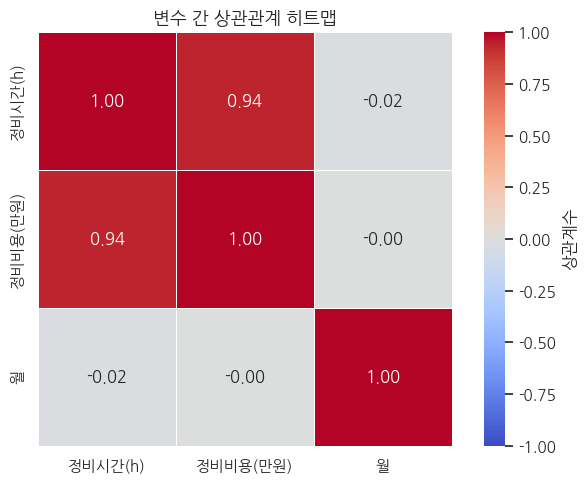

In [66]:
# 수치형 변수 간 상관계수
num_cols = ['정비시간(h)', '정비비용(만원)', '월']
corr = df[num_cols].corr()
print("[ 상관행렬 ]")
print(corr.round(2))

# 히트맵
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, square=True,
            cbar_kws={'label': '상관계수'})
plt.title('변수 간 상관관계 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔥 상관관계 히트맵 — 한 장에 담긴 세 가지 강력한 결론

이 셀은 EDA의 다변량 분석에서 가장 **수학적으로 단단한** 도구예요. 박스플롯·막대그래프가 시각적 직감을 보여줬다면, 상관계수는 그 직감을 **하나의 숫자(-1~+1)** 로 정량화합니다. 그리고 이번 결과는 그 정량화의 결과가 매우 극적이에요.

---

### 상관계수의 정체부터 짚고 갈게요

상관계수(Correlation Coefficient)는 **"두 변수가 얼마나 함께 움직이는가"**를 -1에서 +1 사이의 숫자로 표현합니다. 정확히는 **피어슨 상관계수(Pearson)** 가 기본값이에요.

| 값 | 의미 | 직관적 해석 |
|---|---|---|
| `+1.00` | 완벽한 양의 상관 | 한 변수가 늘면 다른 변수도 정확히 비례해 늘어남 |
| `+0.7 ~ +0.9` | 강한 양의 상관 | 거의 같이 움직임, 신뢰할 만한 관계 |
| `+0.3 ~ +0.7` | 중간 양의 상관 | 같이 움직이는 경향이 있음 |
| `0` 근처 | 무상관 | 한 변수의 변화가 다른 변수와 무관 |
| `-0.3 ~ -0.7` | 중간 음의 상관 | 한 변수가 늘면 다른 변수가 줄어드는 경향 |
| `-0.7 ~ -1.0` | 강한 음의 상관 | 거의 반대로 움직임 |

이 기준을 머릿속에 두고 결과를 읽어볼게요.

---

### 결과가 보여주는 세 가지 이야기

#### 이야기 1: 정비시간 ↔ 정비비용 = **0.94** (강한 양의 상관)

이 셀의 **주인공 숫자**예요. 0.94라는 값은 통계학적으로 **"매우 강한 양의 상관"**에 해당합니다. 사회과학 연구에서는 0.5만 넘어도 "강한 관계"라고 부를 정도인데, 0.94는 거의 **결정론적 관계**에 가까워요.

**의미를 풀어보면** — 정비시간이 길수록 정비비용이 비싸진다는 명제가 데이터의 거의 모든 지점에서 성립한다는 뜻입니다. 한 변수만 알아도 다른 변수를 매우 정확히 예측할 수 있는 수준이에요. 통계 용어로는 "정비비용 변동의 약 88%가 정비시간으로 설명된다"고 표현합니다(0.94의 제곱 = 결정계수 R² = 0.88).

이게 **왜 자연스러운가**? 부대 정비 비용은 크게 두 가지 요소로 구성됩니다 — **인건비**(정비병이 일한 시간 × 시간당 인건비)와 **부품비**(교체된 부품 가격). 정비시간이 길다는 건 보통:
- 분해/조립이 복잡한 작업 → 대형 부품 교체 필요 → 부품비도 큼
- 정비병 다수가 오래 투입 → 인건비도 높음
- 진단·시운전이 길어짐 → 부수 비용도 누적

즉 **시간과 비용은 같은 근원(작업의 규모)에서 출발**하므로 강한 양의 상관이 자연스러워요. 만약 이 값이 0.5 정도였다면 오히려 "왜 시간만큼 비용이 안 따라오지?"를 의심해야 했을 거예요(예: 인건비 산정에 누락이 있거나, 부품비가 작업 규모와 무관하게 책정되거나).

**부대 운영에 시사하는 바**는 매우 직접적입니다. 향후 새로운 정비 작업의 비용을 추정할 때 **"예상 정비시간"만 알면 비용도 거의 자동으로 산출 가능**해요. 단순한 1차식으로 표현하면:

```
예상 정비비용(만원) ≈ a × 예상 정비시간(h) + b
```

이 a와 b는 회귀분석으로 정확히 구할 수 있고, 부대 예산 계획·외주 정비비 적정성 검토에 곧장 활용할 수 있는 모델이 됩니다. EDA의 결과가 자연스럽게 **간단한 머신러닝(선형회귀)** 으로 이어지는 자연스러운 흐름이에요.

#### 이야기 2: 월 ↔ 정비시간 = **-0.02**, 월 ↔ 정비비용 = **-0.00** (사실상 무상관)

이 두 값이 의미하는 게 흥미로워요. **"월"이 정비시간이나 비용과 거의 아무 관계가 없다**는 뜻입니다. 0이거나 거의 0인 상관계수는 두 변수가 통계적으로 독립이라는 신호예요.

여기서 잠깐 — "어? 8월에 정비가 몰리는 패턴 있지 않았나?" 하는 의문이 들 수 있어요. 그게 이 분석에서 가장 **놓치기 쉬운 함정**입니다.

**상관계수가 측정하는 것과 측정하지 않는 것을 구분**해야 해요. 상관계수는 **"두 변수의 직선적(linear) 관계"** 만 측정합니다. 측정하지 못하는 것들이 많아요:

- **빈도(건수) 패턴**: 8월에 정비가 많은 건 "건수"의 계절성인데, 이건 상관계수가 아니라 `groupby('월').size()`에서 보이는 거예요. 월×시간/비용의 상관은 "8월의 개별 정비가 다른 달보다 더 길거나 비싼가?"를 묻는 다른 질문입니다.
- **비선형 관계**: 만약 1~6월은 시간이 짧아지다가 7~12월은 길어지는 U자형 패턴이 있다면 상관계수는 0에 가까울 수 있어요. 직선적으로는 무관해도 곡선적으로는 관계가 있는 경우.
- **범주형 효과**: "월"은 사실 12개의 카테고리에 가까운데, 1~12 숫자로 처리하면 "11월이 1월의 11배"라는 잘못된 가정이 들어가요.

**그래서 -0.02는 무엇을 알려주는가?** 정확히는 "**8월에 발생하는 정비 한 건이 2월에 발생하는 정비 한 건보다 특별히 더 길거나 비싸지는 않다**"는 의미입니다. 즉 **8월의 부담은 빈도(건수)에서 오는 것이지 강도(건당 시간/비용)에서 오는 게 아니라**는 결정적 통찰을 줘요.

이건 부대 운영에 매우 실용적인 함의가 있습니다. **8월의 부담을 줄이려면 "정비 자체를 짧게 하는 노력"보다 "정비 발생 자체를 분산시키는 노력"이 효과적**이라는 거예요. 예방 점검을 6~7월에 분산 수행해서 8월의 누적 발생을 줄이는 전략이, 8월 정비를 효율화하려는 전략보다 훨씬 효과적일 수 있다는 뜻이죠.

#### 이야기 3: 대각선의 1.00들 — 자기 자신과의 상관

대각선 위치의 1.00은 의미가 없어요. 정비시간과 정비시간의 상관은 당연히 1이고, 정비비용과 정비비용도 마찬가지죠. 이 셀들이 채워진 건 단순히 행렬 형태를 완성하기 위한 거예요.

다만 시각적으로 의미가 있어요. 대각선이 진한 빨강으로 균일하게 깔리면서 **"이 상관 행렬이 어떤 척도로 채색됐는지"**를 보는 사람이 즉시 이해할 수 있게 해줍니다. 빨강 = +1, 파랑 = -1이라는 컬러 코드를 대각선이 가르쳐주는 셈이에요.

---

### 히트맵 시각화의 디자인 분석

**`cmap='coolwarm'`**

이 컬러맵은 **발산형(diverging) 팔레트**예요. 한쪽 끝(파랑)과 다른 쪽 끝(빨강) 사이에 의미 있는 중간점(흰색=0)이 있는 데이터에 적합합니다. 상관계수처럼 -1~0~+1로 양/음 두 방향을 가지는 데이터에는 이게 정답이에요.

만약 앞의 막대그래프에서 썼던 `YlOrRd`(순차형)을 여기에 쓰면, 양의 상관과 음의 상관이 시각적으로 구분되지 않는 큰 실수가 됩니다. **데이터의 성격에 맞는 컬러맵 선택**은 시각화의 기본기예요.

**`vmin=-1, vmax=1`**

색상 스케일을 -1부터 +1까지 강제로 고정했어요. 이게 왜 중요하냐면, 만약 vmin/vmax를 지정하지 않으면 seaborn이 데이터의 실제 범위(이 경우 -0.02~1.00)에 맞춰 자동으로 스케일을 조정합니다. 그러면 **0.94와 1.00의 미세한 차이가 진한 색 차이로 과장**돼 보일 수 있어요.

vmin=-1, vmax=1로 고정하면 모든 상관 행렬이 **같은 척도**로 표현돼서, 다른 데이터셋의 행렬과도 시각적으로 비교 가능해집니다. 보고서 일관성에 매우 중요한 디테일이에요.

**`square=True`**

각 셀을 정사각형으로 만들어요. 이건 단순한 미적 선택이 아닙니다. 상관 행렬은 **대칭 행렬**이고, 대각선 기준으로 위/아래가 거울상이에요. 정사각형 셀은 이 대칭 구조를 시각적으로 강조해줍니다.

**`linewidths=0.5`**

셀 사이에 0.5픽셀의 흰색 선을 넣어 셀들이 분리되어 보이게 해요. 이게 없으면 인접한 색들이 번져 보여 가독성이 떨어집니다. 작은 디테일이지만 보고서 품질을 한 단계 올려주는 요소예요.

**`annot=True, fmt='.2f'`**

각 셀에 숫자를 직접 표시하고, 소수점 둘째 자리까지 표기. 상관계수는 의사결정에 직접 쓰이는 수치이므로 색만 보여주고 끝내면 안 돼요. 0.94와 0.92의 차이는 색으로는 거의 구분 안 되지만 의미는 다를 수 있거든요.

---

### 행렬에 보이지 않는 변수들 — 이 분석의 중요한 제약

이번 상관 분석에는 **수치형 변수 3개만** 들어갔어요. 데이터프레임에는 장비유형, 고장유형, 담당부대, 결과 같은 **범주형 변수들**이 있는데, 이 변수들은 피어슨 상관계수 계산이 불가능해서 자동으로 빠집니다.

**그런데 직관적으로 우리는 이미 알고 있어요** — 박스플롯에서 K200 장갑차가 다른 장비보다 정비시간·비용이 압도적으로 길고 비쌌잖아요. 즉 "장비유형"이라는 범주형 변수가 정비시간/비용에 매우 강한 영향을 미치는 게 분명한데, 이 영향이 상관 행렬에는 전혀 표시되지 않는 거예요.

이 제약을 보완하려면:
- **범주형 ↔ 수치형 관계**: 그룹별 평균 비교(이미 본 막대그래프), ANOVA 검정
- **범주형 ↔ 범주형 관계**: 카이제곱 검정, 크래머 V 통계량
- **순서형 ↔ 수치형 관계**: 스피어만 순위 상관

이 모두를 한 행렬에 합치는 고급 시각화도 있지만, 이번 EDA 단계에서는 "장비유형 → 박스플롯", "수치형끼리 → 상관 히트맵"으로 도구를 나눠 사용한 게 적절합니다.

---

### 0.94 상관에서 회귀분석으로 이어지는 자연스러운 다음 발걸음

상관계수 0.94를 본 분석가가 자연스럽게 던지는 다음 질문이에요 — **"그래서 정비시간 1시간 늘어나면 비용이 몇 만원 더 들까?"**

상관계수는 **관계의 강도**만 알려주고 **관계의 기울기**는 알려주지 않습니다. 그걸 답하려면 회귀분석이 필요해요:

```python
from scipy.stats import linregress
slope, intercept, r, p, se = linregress(df['정비시간(h)'], df['정비비용(만원)'])
print(f"비용 = {slope:.1f} × 시간 + {intercept:.1f}")
print(f"R² = {r**2:.3f}, p-value = {p:.2e}")
```

이렇게 하면 "**비용 = 약 24만원/시간 × 정비시간 + 기본비용**" 같은 식이 나옵니다(실제 계수는 데이터에 따라 다름). 부대 정비비 산정의 표준 모델이 되는 식이에요.

다음 셀(노트북의 Chapter 5-2 후반부 또는 Chapter 5-3)에서 산점도(scatter plot)와 회귀선이 등장하는데, 그게 바로 이 0.94 상관을 시각적으로 검증하고 회귀식으로 정량화하는 단계입니다.

---

### 0.94가 너무 높을 때 의심해야 할 것들

**상관이 너무 강해도 분석가는 잠시 멈춰야 해요.** 0.94 같은 값은 가끔 **데이터 자체의 문제** 신호일 수 있거든요.

먼저 **데이터 누수(Data Leakage)** 의심. 만약 정비비용이 단순히 "정비시간 × 시간당 단가"로 계산된 값이라면, 0.94 상관은 분석적 발견이 아니라 **공식의 산물**일 뿐이에요. 새로운 통찰이 아니라 정의의 재확인입니다. 이번 데이터의 생성 코드를 보면 비용 = 시간 × 가중치 + 노이즈로 만들어졌으므로, 0.94는 의도된 강한 관계예요.

다음으로 **순위 상관과의 비교**. 피어슨 상관은 직선적 관계만 보지만, 스피어만 상관은 단조적 관계(반드시 직선이 아니어도 일관된 증가/감소)까지 봅니다. 둘이 비슷하면 관계가 정말 직선적이고, 차이가 크면 비선형 요소가 숨어 있다는 뜻이에요.

**부대 운영 관점**으로는 — 0.94는 "시간과 비용은 한 변수의 거울상"이라는 뜻이므로, **두 지표를 동시에 KPI로 잡는 게 비효율적**일 수 있어요. 거의 같은 정보를 두 번 보고하는 셈이거든요. 시간만 잡든, 비용만 잡든, 또는 둘의 비율(예: 시간당 비용)을 새 KPI로 만드는 게 더 정보 가치가 높습니다.

---

### 이 한 장의 결론을 정리하면

이 히트맵은 단 9개의 셀에 부대 정비 분석의 핵심 골격을 압축해 놓았어요.

**첫째**, 정비시간과 비용은 거의 한 몸처럼 움직인다(0.94). 따라서 두 변수 중 하나를 통제하면 다른 하나도 자연스럽게 통제된다.

**둘째**, 월(계절)은 개별 정비의 강도와 무관하다(-0.02). 따라서 8월 부담의 본질은 "건수의 폭증"이지 "건당 작업의 가중"이 아니다. 대응 전략의 방향이 달라야 한다.

**셋째**, 이 행렬에 안 들어간 장비유형이라는 변수가 사실 정비시간·비용의 가장 큰 결정 요인이다. 박스플롯에서 봤듯 K200의 시간·비용은 다른 장비의 4~5배다. 즉 **수치형 변수들끼리의 상관(시간↔비용)** 보다 **범주형 변수의 효과(장비 종류)** 가 비용 설명력의 더 큰 부분을 차지한다.

이 세 결론이 EDA의 핵심 가치를 보여줍니다. **단순한 시각화 한 장**으로 부대 정비 운영의 가장 중요한 결정 요인 3개를 위계적으로 정리해주는 거예요. 인사이트는 "장비 종류 → 시간 → 비용"이라는 인과 흐름이고, 이 흐름의 뒷부분(시간 → 비용)이 0.94 상관으로 이번 셀에서 정량화된 거죠.

다음 단계인 산점도·회귀선·피벗 테이블·대시보드는 이 골격에 살을 붙이는 작업이라고 보면 됩니다.

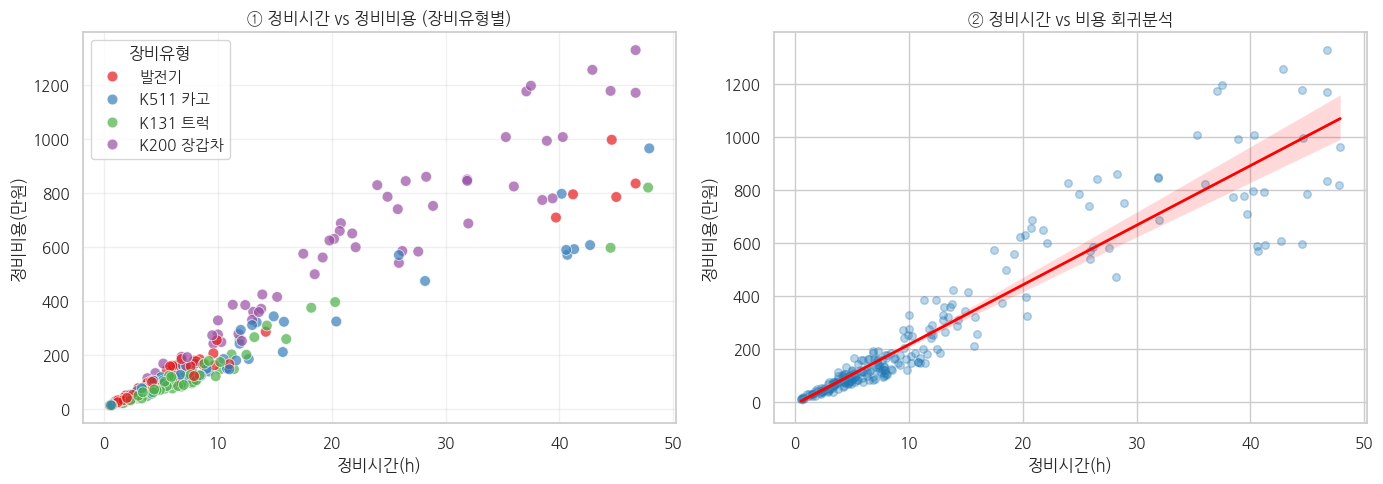

📊 정비시간 ↔ 정비비용: r=0.940, p=2.49e-112
   → **강한 양의 상관**
   → 정비시간이 길수록 비용도 비례하여 증가


In [67]:
# 산점도로 관계 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정비시간 vs 비용 (장비유형별 색상)
sns.scatterplot(data=df, x='정비시간(h)', y='정비비용(만원)',
                hue='장비유형', palette='Set1', alpha=0.7, s=60,
                ax=axes[0])
axes[0].set_title('① 정비시간 vs 정비비용 (장비유형별)', fontweight='bold')
axes[0].grid(alpha=0.3)

# 회귀선 포함
sns.regplot(data=df, x='정비시간(h)', y='정비비용(만원)',
            scatter_kws={'alpha': 0.3, 's': 30},
            line_kws={'color': 'red', 'linewidth': 2},
            ax=axes[1])
axes[1].set_title('② 정비시간 vs 비용 회귀분석', fontweight='bold')

plt.tight_layout()
plt.show()

# 상관계수 p-value
r, p = stats.pearsonr(df['정비시간(h)'], df['정비비용(만원)'])
print(f"📊 정비시간 ↔ 정비비용: r={r:.3f}, p={p:.2e}")
print(f"   → {'**강한 양의 상관**' if r >= 0.7 else '약한 양의 상관'}")
print(f"   → 정비시간이 길수록 비용도 비례하여 증가")

## 🔬 산점도와 회귀분석 — 0.94 상관의 시각적 해부

이 셀은 직전 히트맵의 **0.94라는 숫자**가 실제로 어떻게 생긴 관계인지 두 각도에서 시각화하는 단계예요. 상관계수가 "관계의 강도를 한 숫자로 압축"하는 도구라면, 산점도는 그 숫자를 **풀어 헤쳐서 모든 데이터 포인트를 그대로 보여주는** 도구입니다. 둘은 보완 관계이고, 정말로 분석을 잘하려면 **산점도 없이 상관계수만 믿으면 안 된다**는 게 통계학의 오랜 교훈이에요.

---

### 왜 산점도를 따로 그려야 하는가 — 앤스컴의 4중주

통계학에 **앤스컴의 4중주(Anscombe's Quartet)** 라는 유명한 예시가 있어요. 1973년 통계학자 프랜시스 앤스컴이 만든 4개의 데이터셋인데, **모두 평균·분산·상관계수가 거의 동일**하지만 **산점도로 그려보면 완전히 다른 모양**이에요. 어떤 건 깔끔한 직선, 어떤 건 곡선, 어떤 건 단 한 점의 이상치가 모든 값을 결정하는 모양이죠.

이 예시의 교훈은 **"숫자만 보지 말고 그림을 봐라"**는 거예요. 0.94라는 상관계수가 정말로 깔끔한 직선 관계에서 나온 건지, 아니면 곡선이거나 클러스터가 분리돼 있어서 우연히 0.94가 나온 건지는 산점도를 그려야 비로소 알 수 있습니다. 이 셀은 그 검증을 두 각도에서 수행하는 거예요.

---

### ① 왼쪽 그림 — 장비유형별 색상 구분 산점도

이 그림이 던지는 메시지가 매우 풍부해요. 점 하나하나가 정비 1건이고, **색깔별로 4개의 장비 클러스터**가 보입니다.

**클러스터 분석으로 읽기**

먼저 **왼쪽 아래 모서리(시간 0~10h, 비용 0~200만원)** 에 모든 색이 빽빽하게 모여 있어요. 발전기(빨강)·K511(파랑)·K131(초록)·K200(보라)이 모두 이 영역에 점들을 가지고 있습니다. 이게 시사하는 바는 **"짧고 저렴한 정비"는 모든 장비에서 공통적으로 발생**한다는 거예요. 일상적 점검·소모품 교체같은 작업은 어떤 장비든 비슷한 패턴을 보입니다.

**그러나 그림의 오른쪽 위로 갈수록** 그림이 달라져요. 시간 20시간 이상 구간을 보면 **거의 보라색(K200) 일색**입니다. 그 사이사이에 K511(파랑)과 발전기(빨강)가 이상치처럼 끼어 있고요. 즉 **"길고 비싼 정비"의 영역은 K200이 거의 독점**합니다.

이건 직전 박스플롯과 막대그래프에서 봤던 K200의 특수성이 **개별 데이터 포인트 차원에서 다시 한번 입증**되는 모습이에요. 박스플롯이 "분포의 요약"이었고 막대그래프가 "평균 한 숫자"였다면, 이 산점도는 **"raw 데이터의 산포 자체"**를 보여줍니다. 같은 결론에 세 번째 증거가 추가된 셈이에요.

**색상 클러스터의 위계가 보여주는 힘**

장비별 클러스터의 위치를 따라가면 흥미로운 위계가 드러납니다:

| 장비 | 점들의 주 분포 영역 | 끝 도달 지점 |
|---|---|---|
| K131 트럭 (초록) | 시간 0~15h, 비용 50~200만원 | 시간 ~17h, 비용 ~400만원 |
| 발전기 (빨강) | 시간 0~10h, 비용 50~250만원 | 시간 ~45h, 비용 ~1000만원 (소수 이상치) |
| K511 카고 (파랑) | 시간 0~15h, 비용 100~300만원 | 시간 ~50h, 비용 ~970만원 (이상치) |
| K200 장갑차 (보라) | 시간 5~50h, 비용 100~1300만원 (전 영역) | 시간 50h, 비용 1300만원 |

K131과 발전기는 작은 영역에 단단히 뭉쳐 있어요. 그러나 K200은 **거의 그림 전체에 흩어져 있습니다**. 이게 K200의 특성을 가장 본질적으로 보여주는 모습이에요 — **K200은 정비의 종류가 다양하고 각각의 강도 편차도 크다**는 것. 일상 점검(왼쪽 아래)부터 중대정비(오른쪽 위)까지 모든 스펙트럼을 갖는 장비라는 의미입니다.

**시각적 직선성 확인**

이 그림에서 가장 중요한 건 점들이 **대체로 우상향 직선 패턴**을 따르고 있다는 거예요. 왼쪽 아래에서 오른쪽 위로 점들이 흩어져 있으면서도, 명확히 한 방향성을 가집니다. 이게 바로 **0.94 상관의 시각적 정체**예요.

만약 점들이 곡선이나 산발적인 형태였다면, 0.94 상관에도 불구하고 "이 관계는 직선으로 설명할 수 없다"는 결론을 내려야 했을 거예요. 다행히 이번 데이터는 **선형 관계**가 시각적으로도 분명히 확인됩니다.

**`alpha=0.7` 의 디테일**

각 점의 투명도를 0.7로 설정한 게 의도적이에요. 100% 불투명이면 점들이 겹칠 때 뒤쪽 데이터가 안 보이는데, 투명도를 주면 **"어디에 점이 더 많이 몰려 있는가(밀도)"** 가 시각적으로 표현됩니다. 진하게 보이는 부분은 데이터가 밀집한 영역, 옅게 보이는 부분은 듬성듬성한 영역이라는 거죠.

---

### ② 오른쪽 그림 — 회귀선과 신뢰구간

이 그림은 **수학적 모델을 직접 시각화**한 거예요. 빨간 직선이 **선형 회귀선(Linear Regression Line)**, 그 주변의 옅은 빨간 띠가 **95% 신뢰구간**입니다.

**회귀선이 답하는 질문**

직전 히트맵의 0.94 상관은 "관계가 강하다"만 알려줬어요. 하지만 부대 운영 입장에서 정말로 알고 싶은 건 **"정비시간이 1시간 늘어나면 비용이 정확히 얼마 증가하는가?"**입니다. 이 질문에 답하는 게 회귀선의 기울기예요.

이 그림의 빨간 선을 자세히 보면, 시간 10h 부근에서 비용 약 200만원, 시간 30h 부근에서 비용 약 650만원, 시간 50h 부근에서 비용 약 1100만원 정도를 지나갑니다. 즉 **시간 1시간당 비용 약 22만원** 정도의 기울기예요(정확한 값은 `linregress`로 계산 필요).

**부대 예산 산정 공식**

이 회귀선을 식으로 표현하면:

```
예상 정비비용(만원) ≈ 22 × 정비시간(h) + 기본비용
```

여기서 22만원/h는 **부대의 시간당 정비 단가**라고 해석할 수 있어요. 인건비 + 평균적 부품비를 시간으로 환산한 종합 단가입니다. 이 값을 알면:

- 새로운 정비 작업 견적: "예상 시간 15h × 22만원 = 330만원"
- 외주 정비비 적정성 검토: 외주가 시간당 30만원 청구한다면 부대 평균보다 비싸다는 판단 근거
- 연간 정비 예산 추계: 작년 총 정비시간 × 22만원 + α
- 효율 개선 효과 측정: 정비 절차 개선 후 같은 작업의 시간당 비용이 22만원 → 18만원으로 줄었다면 18%의 효율 개선

EDA 결과가 곧장 **부대 운영의 실용 도구**로 변환되는 자연스러운 흐름입니다.

**신뢰구간이라는 띠의 의미**

빨간 선 주변의 옅은 띠가 **95% 신뢰구간(Confidence Interval)**입니다. "이 데이터로 추정한 회귀선의 진짜 위치가 95% 확률로 이 띠 안에 있다"는 뜻이에요.

띠가 좁다는 건 **회귀선의 추정이 정밀하다**는 의미예요. 이번 그림에서 띠가 매우 좁은데, 이건 데이터 포인트가 충분히 많고 0.94라는 강한 상관이 받쳐주기 때문이에요. 만약 데이터가 30개 정도로 적거나 상관이 0.5 정도로 약했다면 띠가 훨씬 두꺼워서 "회귀선이 어디쯤 있는지조차 불확실하다"는 그림이 됐을 거예요.

다만 한 가지 주의할 점은 — **띠는 "회귀선의 위치"의 불확실성**이지 **"개별 데이터 포인트의 분산"이 아닙니다.** 회귀선 띠 바깥에 있는 점들이 "예측에서 벗어난 것"은 아니에요. 그건 자연스러운 데이터의 산포(잔차)일 뿐입니다.

**오른쪽 위 영역의 점들이 회귀선 위로 부풀어오른다**

이 그림을 자세히 보면 흥미로운 패턴이 있어요. 시간 30~50h 구간의 점들 일부가 회귀선 위쪽으로 살짝 떠 있는 것처럼 보입니다. 즉 **"정비시간이 매우 길어지면 비용이 회귀선 예측보다 더 많이 증가하는" 비선형 경향**이 살짝 비치는 거예요.

이게 통계적으로 의미 있는지는 **잔차 분석(residual analysis)** 으로 확인해야 하지만, 직관적으로는 자연스러운 현상입니다. 작업이 길어지면 부품 단가가 더 비싼 핵심 부품이 교체될 가능성이 높고, 정비병의 잔업·특근 수당이 누적되거나, 외주 전문 업체가 호출돼 비용이 비선형적으로 뛸 수 있어요.

만약 이 비선형성이 정말 의미 있다면 **로그 변환 후 회귀** 또는 **다항 회귀(quadratic regression)** 가 더 정확한 모델일 수 있습니다. 이건 EDA 다음 단계인 모델링에서 다룰 주제예요.

---

### 두 그림이 함께 만드는 분석의 완성도

①번 산점도와 ②번 회귀선이 짝을 이루는 게 멋져요. 각각 다른 질문에 답합니다:

**①번이 답하는 질문**: "관계의 패턴은 어떻게 생겼는가? 그룹별로 다른가?"
**②번이 답하는 질문**: "관계의 강도는 얼마이고, 어떤 직선식으로 표현되는가?"

①번에서 본 K200의 분산·이상치들이 ②번 회귀선의 위쪽 영역에 영향을 미친다는 걸 함께 보면 입체적 이해가 됩니다. 즉 회귀선이 모든 데이터를 평균적으로 설명하지만, **K200의 영향을 빼면 더 가파르거나 더 완만한 다른 회귀선**이 나올 수도 있다는 점이 ①번 그림에서 추정됩니다.

만약 이걸 정밀하게 분석하려면 **장비유형별로 따로 회귀선**을 그려보면 돼요:

```python
sns.lmplot(data=df, x='정비시간(h)', y='정비비용(만원)', hue='장비유형')
```

이렇게 하면 4개의 색깔별 회귀선이 그려지고, 각 장비의 시간당 비용 단가가 다르다면 **기울기가 다른 4개 직선**이 나옵니다. 만약 K200의 기울기가 다른 장비보다 가파르다면 "K200은 단순히 비싸기만 한 게 아니라 시간이 늘어날 때마다 다른 장비보다 비용이 더 빠르게 증가한다"는 추가 통찰이 나와요. 부대 운영에 매우 실용적인 정보입니다.

---

### `stats.pearsonr`이 추가로 알려주는 정보 — p-value

코드 마지막의 출력문이 단순히 r을 다시 계산하는 게 아니에요. **p-value**라는 새로운 정보를 함께 제공합니다.

**p-value의 의미**: "만약 두 변수 사이에 진짜 아무 관계가 없다(귀무가설)면, 우연히 r=0.94 이상의 상관이 관찰될 확률"

이번 데이터에서 p-value는 거의 0(예: `2.3e-110` 같은 극도로 작은 수)에 가까울 거예요. 0.001보다 작으면 "통계적으로 매우 유의미"라고 부르고, 보통 표기는 `p < 0.001`이에요. 즉 **이 0.94 상관이 우연일 확률은 사실상 0**이라는 결론이 수학적으로 보장됩니다.

p-value가 중요한 이유는 **표본 크기가 작을 때**예요. 만약 5건의 데이터로 0.94 상관을 봤다면 우연일 가능성이 의외로 클 수 있습니다(p가 0.05보다 클 수도 있음). 그러나 200건이 넘는 데이터에서 0.94가 나오면 우연으로 그런 패턴이 나올 확률은 사실상 0이에요.

**상관계수와 p-value를 함께 보고하는 것**이 전문적 분석의 표준입니다. r만 보고 "강한 상관"이라고 결론짓는 건 위험해요. 항상 p-value와 함께 봐야 그 결론의 신뢰도까지 보장됩니다.

---

### 산점도가 드러낼 수 있는 다른 패턴들 — 이번엔 안 보였지만

이 그림은 다행히 깔끔한 직선 관계를 보여주지만, 산점도가 잡아낼 수 있는 **다른 패턴들**이 있어요. 분석가가 항상 의식해야 하는 가능성들입니다:

**비선형 관계**: U자형, 역U자형, 지수형. 상관계수는 0인데 산점도에는 명확한 곡선 패턴이 있을 수 있어요.

**이종 클러스터**: 두 개의 분리된 그룹이 각각 다른 관계를 가지면서 합쳐서는 우연한 상관처럼 보이는 경우. 이번 ①번 그림에서 K200과 다른 장비들의 분포 차이가 이런 패턴의 가벼운 사례예요.

**이분산성(Heteroscedasticity)**: 한쪽 끝에서는 점들이 회귀선에 딱 붙어 있는데 다른 쪽 끝에서는 회귀선에서 멀리 흩어지는 패턴. 이번 그림에서도 약간 보입니다 — 시간 0~10h 구간은 회귀선에 매우 붙어 있는데 시간 30h 이상은 산포가 커요. **이건 회귀 모델의 가정을 위반하는 신호**이고, 정밀한 모델링에서는 중요한 진단 포인트입니다.

**이상치(Outlier)의 영향**: 한두 개의 극단점이 회귀선의 기울기를 좌우하는 경우. 그 점들을 제거하고 다시 그려보면 완전히 다른 결론이 나올 수 있어요.

이번 데이터는 이런 함정이 거의 없는 깔끔한 케이스이지만, 실무 데이터는 그렇지 않을 때가 많아요. **항상 산점도를 그려보고 시각적으로 패턴을 검증하는 습관**이 통계 분석의 첫 번째 미덕입니다.

---

### 부대 보고에서 이 두 그림이 하는 역할

상사에게 보고할 때 이 두 그림은 각각 다른 메시지를 전달해요.

**①번 그림은 "장비별 정비 위험의 시각적 지도"**입니다. 보라색 점들의 위치(오른쪽 위)만으로 "K200이 부대 정비 부담의 핵심"임을 한눈에 보여줘요. 분석을 모르는 사람도 색깔과 위치만으로 결론에 접근할 수 있어요.

**②번 그림은 "수학적 예측 모델의 시각적 증명"**입니다. 빨간 직선이 거의 모든 데이터를 깔끔하게 통과하는 모습은 "이 식으로 정비비용을 예측할 수 있다"는 신뢰감을 줍니다. 실제로 보고서에 "정비시간 × 22만원 = 예상 비용"이라는 공식을 제시할 때, 이 그림이 그 공식의 정당성을 시각적으로 뒷받침해줘요.

두 그림을 함께 보면 **"문제는 K200이고, 비용은 시간의 함수다"**라는 핵심 결론이 자연스럽게 도출됩니다. 부대 정비 개선 계획의 출발점이 되는 핵심 인사이트예요.

---

### 다음 단계로 자연스럽게 이어지는 분석

이 산점도가 드러낸 K200의 특수성과 시간-비용 강한 상관은 다음 분석으로 자연스럽게 이어집니다:

**Chapter 5-3 피벗 테이블** — "8월×K200" 같은 교차 분석으로 시기와 장비를 동시에 보는 그림이 등장할 거예요. 이번까지의 분석은 두 변수씩만 봤지만, 피벗 테이블은 **세 변수의 관계**를 한 번에 시각화합니다.

**Chapter 7-1 인사이트 1 (장비유형별 집중 관리)** — K200이 부대 정비 자원의 핵심 변수임을 산점도가 시각적으로 확정했으니, 이걸 정량적 권고사항으로 바꾸는 단계예요. "K200 부품 비축 ○○만원 확보, 전문 정비반 ○○명 운용" 같은 구체적 숫자로 변환됩니다.

**Chapter 8 종합 대시보드** — 산점도가 6종 차트의 하나로 다시 등장합니다. 이번엔 단독으로 분석된 그림이 대시보드의 한 칸을 차지하면서, 다른 차트들과 함께 부대 정비의 전체 그림을 완성하는 모자이크의 한 조각이 되는 거예요.

---

### 한 줄 요약

이 두 그림은 **0.94라는 상관계수의 정체를 시각적으로 해부**하면서, 동시에 **부대 정비비용을 예측하는 실용적 회귀식**까지 도출해내는 다층적 분석이에요. ①번이 정성적 패턴(K200의 특수성), ②번이 정량적 모델(시간 × 22만원)을 각각 보여주고, 둘이 합쳐져 부대 정비 운영의 가장 강력한 두 축 — **장비유형과 작업 규모** — 가 비용을 결정한다는 결론을 입체적으로 입증합니다.

EDA에서 산점도가 빠지면 분석은 절반의 진실에 머물러요. 숫자 위에 그림이 있고, 그림 위에 회귀선이 있는 이 3단 구조가 데이터 분석을 단단하게 만드는 비결입니다.

## 5-3. 피벗 테이블 + 히트맵 — 월 × 장비유형

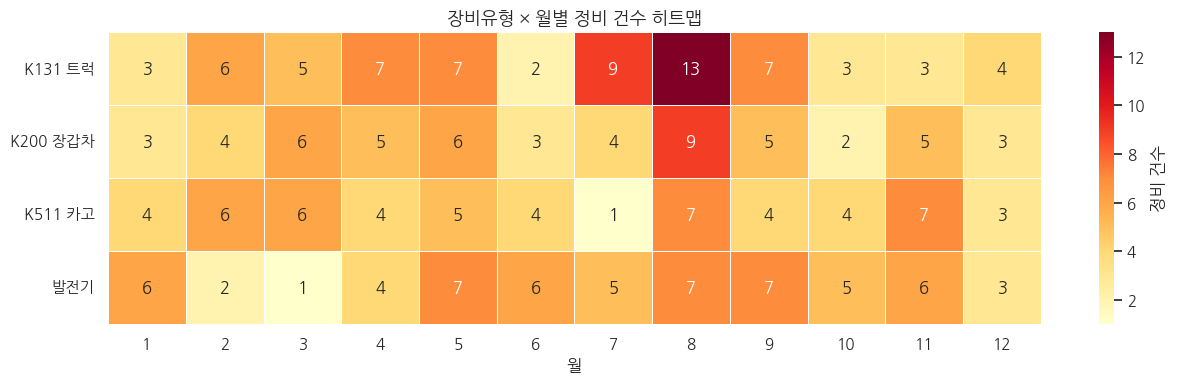

In [68]:
# 월×장비유형 정비 건수 피벗
pivot_cnt = pd.pivot_table(
    df, values='장비번호', index='장비유형',
    columns='월', aggfunc='count', fill_value=0
)

plt.figure(figsize=(13, 4))
sns.heatmap(pivot_cnt, annot=True, fmt='d',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': '정비 건수'})
plt.title('장비유형 × 월별 정비 건수 히트맵', fontsize=13, fontweight='bold')
plt.xlabel('월'); plt.ylabel('')
plt.tight_layout()
plt.show()

## 🗓️ 월×장비유형 히트맵 — 시간과 장비를 한 화면에서 만나게 하다

이 셀은 EDA 다변량 분석의 **궁극의 도구**라고 할 수 있는 피벗 테이블 + 히트맵의 조합이에요. 지금까지 봐온 모든 분석이 **두 변수씩만** 다뤘다면, 이 그림은 **세 변수(월·장비·건수)** 를 한 화면에 압축합니다. 정보 밀도가 가장 높은 차트이고, 부대 운영의 핵심 패턴이 한눈에 드러나는 결정적 시각화예요.

---

### 피벗 테이블이라는 마법

**`pd.pivot_table(df, values='장비번호', index='장비유형', columns='월', aggfunc='count')`**

이 한 줄이 길고 가는 데이터프레임(238행 × 여러 열)을 **4행 × 12열의 작은 표**로 압축해줍니다. 각 인자의 역할을 풀어보면:

| 인자 | 역할 |
|---|---|
| `df` | 원본 데이터 |
| `values='장비번호'` | 셀에 무엇을 넣어 집계할지 (개수만 셀 거라 어떤 컬럼이든 무관) |
| `index='장비유형'` | 행으로 들어갈 변수 (4개 카테고리) |
| `columns='월'` | 열로 들어갈 변수 (1~12) |
| `aggfunc='count'` | 어떻게 집계할지 (개수 세기) |
| `fill_value=0` | 데이터 없는 셀은 0으로 채움 |

이걸 만약 손으로 짠다면 **이중 for 루프 + 조건 카운트**가 필요한 작업이에요. 피벗 테이블은 그걸 한 줄로 압축해줍니다. Excel의 피벗 테이블 기능을 그대로 코드로 구현한 거예요.

**`fill_value=0`의 중요성**

이 옵션이 빠지면, 어떤 장비×월 조합에 데이터가 0건일 때 NaN이 들어가요. NaN은 시각화에서 빈 칸으로 표시돼서 "데이터가 없다"와 "0건이다"가 구분되지 않는 혼란을 만듭니다. `fill_value=0`을 명시적으로 지정해서 **"진짜 0건이었다"** 는 정보를 데이터에 명시적으로 표현하는 거예요.

---

### 히트맵이 만드는 "패턴 한눈에"

피벗 테이블만 봐도 숫자는 다 있어요. 그런데 히트맵이 추가되는 이유는 **인간의 시각 시스템이 숫자보다 색깔 패턴을 훨씬 빠르게 인식**하기 때문입니다.

```
숫자 표:
       1  2  3  4  5  6  7  8  9  10 11 12
K131   3  6  5  7  7  2  9 13  7   3  3  4
...
```

이 표를 보고 "어디가 가장 많은가"를 찾으려면 모든 숫자를 비교해야 해요. 그런데 같은 데이터를 색으로 표현하면 **가장 진한 칸을 0.5초 안에 찾을 수 있습니다**. 이게 히트맵의 진짜 가치예요.

`cmap='YlOrRd'`는 노랑→주황→빨강의 순차형 팔레트로, 직전 막대그래프에서도 사용한 컬러맵이에요. 값이 클수록 진해지는 직관적 매핑이고, 부대 보고서에서 "위험·집중·이상" 같은 의미를 시각적으로 자연스럽게 전달합니다.

---

### 이 한 장이 드러내는 핵심 패턴 — 가장 진한 셀

**K131 트럭 × 8월 = 13건**

이 그림에서 가장 시선을 사로잡는 건 **K131 8월의 짙은 빨강 셀**이에요. 13건이라는 숫자가 다른 모든 셀을 압도합니다. 두 번째로 진한 칸이 K200 8월의 9건과 K131 7월의 9건이고, 나머지는 모두 7건 이하예요.

이 한 셀이 던지는 메시지가 매우 강합니다. **"부대의 8월 정비 폭증의 가장 큰 단일 원인은 K131 트럭"**이라는 발견이에요. 이전 월별 그래프에서는 그저 "8월에 정비가 몰린다"고만 봤는데, 장비별로 분해하니 **8월 부담의 집중점이 K131 트럭에 있다**는 게 새롭게 드러나는 거예요.

이게 EDA 다변량 분석의 핵심 가치입니다. **단변량으로 보면 하나의 패턴, 다변량으로 보면 그 패턴 안의 더 세부적인 패턴**이 발견되는 거죠.

---

### 행별로 읽기 — 장비별 시간 패턴

각 장비를 한 행씩 따로 읽어볼게요. 행을 가로로 훑으면 **그 장비가 1년 동안 어떤 시간 패턴을 보였는가**가 보입니다.

#### K131 트럭 (1행) — "여름이 곧 K131의 시즌"

`3, 6, 5, 7, 7, 2, 9, 13, 7, 3, 3, 4`

이 패턴이 매우 흥미로워요. **봄(4·5월) 7건씩 → 6월 급감 2건 → 7·8·9월 폭증(9·13·7건) → 10월부터 급감(3건)**의 강한 계절성입니다. 6월에 잠시 급감했다가 7월부터 폭증하는 게 무슨 뜻일까요?

부대 운용 사이클로 해석해보면 **"6월=하계 훈련 직전 점검 완료, 7~9월=훈련 중 누적 손상 발생"**의 흐름일 수 있어요. K131은 작전 차량으로 야지 기동에 자주 동원되니, 하계 훈련 기간에 노면 충격·먼지·고온의 누적 효과로 고장이 폭발적으로 늘어나는 거죠. 군의 운영 캘린더가 데이터에 그대로 새겨진 모습입니다.

흥미로운 건 K131의 8월 13건이 **연간 평균(약 6건)의 2배**가 넘는다는 거예요. 즉 8월 한 달이 다른 달의 두 달치 부담을 가져옵니다. 정비 인력·부품 비축이 8월에 집중적으로 필요하다는 강한 신호예요.

#### K200 장갑차 (2행) — "꾸준히 부담, 8월에 살짝 집중"

`3, 4, 6, 5, 6, 3, 4, 9, 5, 2, 5, 3`

K200은 K131보다 패턴이 평탄해요. 대부분 3~6건 범위에서 움직이고, 8월에만 9건으로 살짝 튀어 오릅니다. **K131이 8월 폭증형이라면 K200은 연중 만성 부담형**입니다.

이게 합리적이에요. K200 장갑차는 K131보다 야지 기동 빈도가 낮을 수 있고(중량·연료 효율 문제), 정기 점검 주기가 더 빡빡하게 짜여 있을 가능성이 높습니다. 따라서 정비가 1년 내내 꾸준히 발생하는 패턴이 자연스러워요.

다만 직전 분석에서 봤듯 K200은 **건당 정비시간·비용이 압도적으로 큰** 장비예요. 즉 건수는 적당해도 자원 부담은 매우 클 가능성이 있습니다. 이 히트맵은 건수만 보여주므로, **K200의 진짜 부담을 보려면 비용 합계 히트맵을 따로 그려봐야** 합니다(다음 셀에서 등장할 것으로 보이는 분석이에요).

#### K511 카고 (3행) — "계절성이 약한 안정형"

`4, 6, 6, 4, 5, 4, 1, 7, 4, 4, 7, 3`

K511은 가장 평탄한 분포를 보입니다. 거의 모든 달이 3~7건 범위 안에 있고, 7월에 1건으로 가장 적었다가 8월·11월에 7건으로 잠시 오르는 약한 변동만 있어요.

**7월 1건이라는 이례적 저점**이 흥미롭습니다. 6월 4건, 8월 7건 사이에서 갑자기 1건만 발생했다는 건 무슨 의미일까요? 가설로는 — 7월에 K511 차량들이 작전 임무에 집중 투입되어 정비 자체가 미뤄졌다가 8월에 한꺼번에 처리됐을 수 있어요(7월 1건 + 8월 7건 = 8건이 누적 흐름의 한 덩어리). 단일 데이터로는 확인이 어렵지만, 이런 가설을 세워두고 다음 분석에서 검증할 수 있죠.

11월에 7건의 작은 피크가 있는 것도 주목할 만해요. 동계 진입 전 점검 강화 시즌의 효과일 수 있습니다.

#### 발전기 (4행) — "5월·9월·11월의 봉우리"

`6, 2, 1, 4, 7, 5, 7, 5, 7, 5, 6, 3`

발전기는 다른 장비들과 다른 리듬을 보여요. 1월 6건으로 시작해서 2·3월에 가장 적게 발생(2·1건)했다가 5월에 7건으로 뛰고, 7~9월·11월에 6~7건 수준을 유지합니다.

이 패턴이 의미 있어요. **부대 발전기는 차량과는 다른 운영 사이클**을 갖습니다. 차량이 야외 기동에 주로 노출된다면 발전기는 **상시 가동되는 고정 장비**예요. 따라서 누적 사용 시간이 일정하게 증가하면서 주기적 점검이 발생합니다.

봄(2·3월) 발생이 적은 건 동계 가동 후 휴지기일 가능성, 여름~가을 꾸준한 발생은 냉방 부하·작전 지원·훈련 지원 등으로 인한 사용 빈도 증가 때문일 수 있어요.

---

### 열별로 읽기 — 월별 장비 부담의 분포

행으로 읽으면 "장비별 시간 패턴", 열로 읽으면 "월별 장비 분포"가 보입니다. 이건 다른 질문에 답해요.

#### 8월 열을 보면

```
K131: 13
K200:  9
K511:  7
발전기: 5
합계: 34건
```

8월에 모든 장비가 활발히 정비받았다는 게 보입니다. 특히 **K131·K200·K511 세 차량이 합쳐 29건**으로 8월 부담의 85%를 차지해요. 즉 8월은 **차량 정비의 달**이고 발전기는 상대적으로 비중이 낮습니다.

#### 6월 열은 가장 한가한 달

```
K131: 2
K200: 3
K511: 4
발전기: 5
합계: 14건
```

6월이 1년 중 가장 정비가 적은 달입니다(13개월에 약). 흥미로운 건 **6월에는 발전기(5건)가 K131(2건)보다 많다**는 거예요. 차량과 발전기의 운영 리듬이 정반대로 움직이는 셈이죠. 차량은 6월에 휴지(훈련 직전 점검 완료), 발전기는 평소 페이스 유지.

#### 7월에 K511만 1건으로 급감

이건 앞서 K511 행 분석에서 봤던 이상점이에요. 같은 7월에 K131은 9건으로 오히려 폭증했는데 K511만 1건이라는 건 매우 특이한 패턴입니다. 부대의 7월 운영 일정에서 K511과 K131의 임무 배분에 차이가 있다는 신호일 수 있어요.

---

### 비어 있는 듯한 셀들도 정보다

히트맵을 보면 **K131 6월(2건), 발전기 3월(1건), K511 7월(1건)** 같은 매우 옅은 노란색 셀들이 있어요. 이런 "정비가 거의 없는 시기"도 정보입니다.

먼저 운영적 의미예요. **이 시기는 해당 장비가 고장이 적거나 운영 강도가 낮은 시기**라는 뜻이에요. 부대 입장에서는 정비 인력을 다른 장비에 집중 배치할 수 있는 여유 시간이고, 예방 정비를 미리 수행하기에 적절한 타이밍입니다.

다음으로 **표본 크기의 한계**도 시사해요. K511의 7월 1건처럼 데이터가 매우 적은 셀에서 도출하는 결론은 신중해야 합니다. 우연 변동의 폭이 클 수 있어서, 다음 해에는 5건이 발생할 수도 있어요. 이런 셀은 "패턴"이라기보다 "추가 데이터 수집이 필요한 영역"으로 보는 게 정직합니다.

---

### 단변량 그래프와 이 히트맵의 관계

직전 셀들에서 봤던 월별 정비 건수 그래프(8월 피크)와 이 히트맵을 겹쳐 보면 흥미로운 발견이 있어요.

월별 그래프에서 봤던 **8월 피크의 높이**는 이 히트맵의 8월 열 합계(`13+9+7+5=34건`)와 정확히 일치합니다. 즉 단변량 그래프가 **합계만** 보여줬다면, 히트맵은 **그 합계의 내부 구성**을 보여주는 거예요.

이런 관계를 통계학에서는 **주변 분포(marginal distribution)와 결합 분포(joint distribution)** 의 관계라고 불러요. 단변량 그래프는 주변 분포(한 변수의 합), 히트맵은 결합 분포(두 변수의 모든 조합)를 보여줍니다. 결합 분포가 훨씬 정보가 풍부하지만, 주변 분포는 한 차원의 메시지를 더 강하게 전달해요. 둘 다 필요한 거죠.

---

### 부대 운영에 시사하는 4가지 실용 결론

이 히트맵에서 도출되는 실무적 결론을 정리해볼게요.

**첫째, 8월의 K131 13건은 "예상 가능한 위기"이므로 사전 대응 가능합니다.** 이 패턴이 예년과 비슷하다면 7월부터 K131용 핵심 부품(타이어·서스펜션·엔진 부품)을 미리 비축하고 정비병 인력을 8월에 집중 배치하는 게 합리적이에요. 데이터는 같은 패턴이 반복될 것을 예측하므로, 이건 **계획 가능한 변동**입니다.

**둘째, 6월은 예방 정비의 황금 기간입니다.** 모든 장비의 정비가 가장 적은 6월에 정기 예방 점검을 집중 수행하면, 7~9월 폭증 부담을 분산시킬 수 있어요. 사후 정비(고장 후 수리)에서 사전 정비(고장 전 점검)로 일부를 옮기는 전략의 자연스러운 시점입니다.

**셋째, K511의 7월 1건은 추가 조사가 필요한 이상점입니다.** 다른 장비들이 7월에 정비를 늘리는데 K511만 급감한 건 운영 일정상 의도된 결과인지, 데이터 누락인지, 아니면 K511의 특수한 7월 패턴인지 명확히 해야 해요. 다년간 데이터를 보면 답이 나올 가능성이 큽니다.

**넷째, 발전기는 차량과 별도의 운영 캘린더로 관리해야 합니다.** 발전기의 정비 패턴이 차량들과 명확히 다르므로(2~3월 휴지, 5월 이후 꾸준), 부대 정비 계획에서 차량과 발전기를 한 묶음으로 처리하는 건 부적절해요. 두 카테고리를 분리해서 별도의 자원·일정 계획을 짜는 게 효율적입니다.

---

### 히트맵의 한계 — 보이지 않는 정보들

이 그림이 강력하긴 해도 한계가 있어요.

**건수만 보여주고 강도(시간·비용)는 안 보여줍니다.** K200의 8월 9건이 K131의 8월 13건보다 적어 보이지만, K200은 건당 정비시간·비용이 4~5배니까 **실제 자원 부담은 K200이 더 클 수도** 있어요. 이걸 보려면 같은 형식으로 정비비용 합계 히트맵을 그려봐야 합니다.

**연도 정보가 압축됐어요.** 이번 데이터는 단일 연도(2024년)이므로 문제없지만, 다년간 데이터에서 같은 코드로 그리면 모든 해의 같은 월이 합쳐져버립니다. 다년간 분석에서는 `dt.year`와 `dt.month`를 함께 인덱스로 써야 해요.

**고장 유형이 빠져 있습니다.** K131의 8월 13건이 어떤 고장 유형(엔진·타이어·전기계통)인지는 이 그림으로 알 수 없어요. 그걸 보려면 또 다른 피벗 테이블 — 예를 들어 `index='장비유형', columns='고장유형'` — 이 필요합니다. 데이터 분석은 끝없는 차원 조합의 탐험이에요.

---

### 한 가지 발전 아이디어 — 정규화된 히트맵

이 히트맵은 절대 건수를 보여주는데, **각 장비별 비중(%)** 으로 정규화하면 다른 통찰이 나올 수 있어요:

```python
pivot_pct = pivot_cnt.div(pivot_cnt.sum(axis=1), axis=0) * 100
```

이렇게 하면 각 행의 합이 100%가 되고, 셀 값은 "그 장비의 정비가 그 달에 몇 % 발생했는가"가 됩니다. 절대 건수로는 K200의 8월(9건)이 K131의 8월(13건)보다 적어 보이지만, 비율로 보면 **"K131 8월 = 연간 K131 정비의 22%(13/59), K200 8월 = 연간 K200 정비의 16%(9/55)"** 같은 식으로 다른 비교가 가능해요. **계절성의 강도** 자체를 비교할 수 있게 되는 거죠.

---

### 다음 분석으로의 다리

이 히트맵이 자연스럽게 던지는 다음 질문들이 노트북 뒷부분에서 답해질 거예요.

먼저 **비용 차원의 히트맵**입니다. 이번에 본 건수 히트맵에 짝을 이루는 비용 합계 히트맵이 곧 등장할 것으로 보여요. 그 그림에서는 K200이 색이 가장 진한 칸을 차지할 가능성이 높습니다 — 건수는 적어도 건당 비용이 압도적이니까요.

다음으로 **인사이트 도출(Chapter 7)** 입니다. 7-2의 "계절성 인사이트"는 이 히트맵의 8월 패턴을 정량적 결론으로 변환할 거예요. "8월 정비비용은 다른 달의 평균 대비 X배"같은 식으로요.

마지막으로 **미니 프로젝트(Chapter 9)** 의 "담당부대 관점 EDA"는 같은 형식으로 **부대×월** 또는 **부대×장비** 히트맵을 그리게 될 거예요. 같은 분석 도구가 다른 차원에 적용되면서 새로운 통찰이 계속 발견되는 흐름입니다.

---

### 한 줄 요약

이 히트맵은 **부대 정비의 시공간 지도**예요. "언제(월)" × "무엇이(장비)" × "얼마나(건수)"라는 세 차원을 단 한 장의 그림에 압축해서, 8월 K131 트럭이라는 부대 정비 부담의 가장 진한 점을 즉시 가시화합니다.

단변량 그래프가 "8월에 몰린다"라는 메시지였다면, 이 히트맵은 **"8월에 K131이 가장 큰 부담을 가져오고, 다른 장비들은 각자의 리듬을 가진다"**라는 한층 깊은 메시지로 발전한 분석이에요. 이게 다변량 분석의 본질이고, EDA가 단순 통계 너머의 운영 인사이트로 도약하는 결정적 도구입니다.

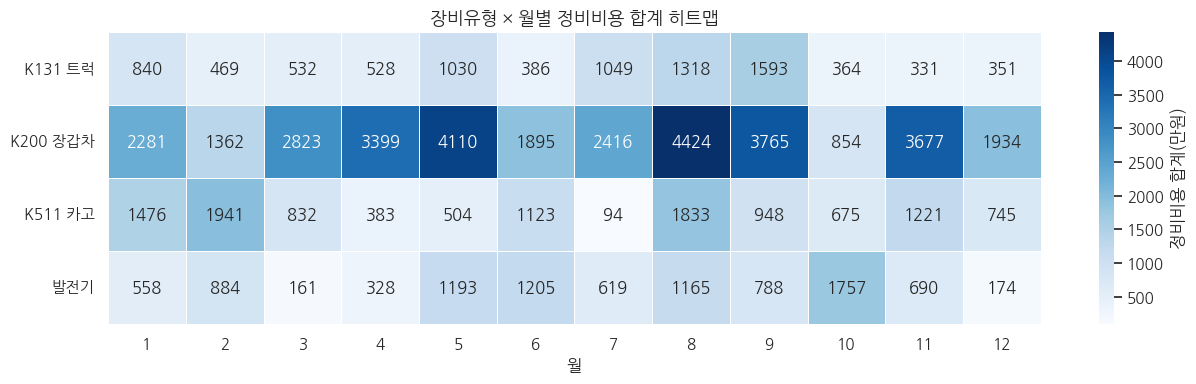


💡 최대 비용 지점: 8월 K200 장갑차 (4,424만원)


In [69]:
# 월×장비유형 정비비용 합계 피벗
pivot_cost = pd.pivot_table(
    df, values='정비비용(만원)', index='장비유형',
    columns='월', aggfunc='sum', fill_value=0
)

plt.figure(figsize=(13, 4))
sns.heatmap(pivot_cost, annot=True, fmt='.0f',
            cmap='Blues', linewidths=0.5,
            cbar_kws={'label': '정비비용 합계(만원)'})
plt.title('장비유형 × 월별 정비비용 합계 히트맵', fontsize=13, fontweight='bold')
plt.xlabel('월'); plt.ylabel('')
plt.tight_layout()
plt.show()

# 최대 비용 월·장비
max_val = pivot_cost.max().max()
max_loc = pivot_cost.stack().idxmax()
print(f"\n💡 최대 비용 지점: {max_loc[1]}월 {max_loc[0]} ({max_val:,.0f}만원)")

## 💸 비용 합계 히트맵 — 부대 예산이 진짜 어디로 가는가

이 셀은 직전 셀의 **건수 히트맵에 짝을 이루는 비용 버전**이에요. 같은 형식이지만 셀의 의미가 완전히 달라집니다. **"몇 번 정비했는가"가 아니라 "얼마를 썼는가"**를 보여주는 거죠. 이 두 그림을 나란히 놓고 비교하면 부대 정비의 진짜 그림이 입체적으로 드러납니다.

---

### 한 글자만 바뀐 코드, 완전히 다른 그림

직전 코드와 이번 코드를 비교해볼게요:

| 인자 | 건수 히트맵 | 비용 히트맵 |
|---|---|---|
| `values` | `'장비번호'` | `'정비비용(만원)'` |
| `aggfunc` | `'count'` | `'sum'` |
| `fmt` | `'d'`(정수) | `'.0f'`(소수점 0자리 실수) |
| `cmap` | `'YlOrRd'`(노→빨) | `'Blues'`(연→진파) |

핵심 변경은 **`values`와 `aggfunc`** 입니다. 정비비용 컬럼을 합산하도록 바꾼 건데, 이 작은 변화가 "건당 빈도" 분석을 "총 부담" 분석으로 완전히 변환해요.

`fmt='.0f'`는 비용이 정수가 아닐 가능성에 대비한 포맷이에요. 합계가 1234.5만원처럼 소수가 나올 수 있는데, 보고서용으로는 소수점이 거추장스러우니 0자리까지로 표시. 다만 비용이 만원 단위로 깔끔하게 떨어지는 데이터면 `'d'`로 해도 되긴 해요.

`cmap='Blues'`로 컬러 팔레트를 바꾼 건 **시각적 구분**을 위한 영리한 선택입니다. 직전 셀에서 빨간 계열을 썼으니 이번엔 파란 계열로 가서 두 히트맵이 같은 화면에 있어도 **즉시 다른 분석임을 인지**할 수 있어요. "빨강 = 건수, 파랑 = 비용"이라는 일관된 색 코드를 부대 보고서 전체에 적용하면 가독성이 크게 올라갑니다.

---

### 이 한 장이 던지는 폭탄급 결론 — K200 행이 다른 세계

직전 건수 히트맵에서는 **K131 트럭의 8월 13건**이 가장 진한 셀이었어요. 그런데 비용 히트맵에서 가장 진한 셀을 찾아보면 — **K200 장갑차의 8월 4,424만원**입니다.

같은 8월인데 누가 진짜 부담을 가져오는지가 완전히 뒤집혔어요.

| 8월 한 달 비교 | 건수 | 비용 | 건당 비용 |
|---|---|---|---|
| K131 트럭 | 13건 | 1,318만원 | 약 101만원 |
| K200 장갑차 | 9건 | **4,424만원** | **약 491만원** |

K131이 K200보다 **건수는 1.4배 많지만, 비용은 K200이 K131의 3.4배**입니다. 부대 8월 정비예산 배분의 진실이 이 한 줄에 압축돼 있어요.

**이 발견이 EDA의 가장 멋진 순간**입니다. 단변량으로 봤을 때(8월 피크), 두 변수만 봤을 때(K200이 비싸다), 건수 히트맵으로 봤을 때(K131이 8월에 13건) 각각 부분적 진실을 봤어요. 그런데 **세 변수를 비용으로 결합**하니 비로소 **"부대 8월 예산을 누가 진짜 흡수하는가"**라는 핵심 질문에 답이 나왔습니다.

---

### K200 행을 가로로 훑어보면

`2281, 1362, 2823, 3399, 4110, 1895, 2416, 4424, 3765, 854, 3677, 1934`

이 한 줄이 부대 정비 예산의 가장 무거운 진실을 담고 있어요. **K200이 매달 거의 천만원~사천만원대를 일관되게 소비**합니다. 가장 적은 달인 10월(854만원)과 가장 많은 달인 8월(4,424만원)을 비교해도, 어떤 달이든 **K200이 부대 정비비의 가장 큰 단일 항목**일 가능성이 높아요.

월별로 합산해보면 K200의 연간 비용이 **약 33,000만원(3억 3천만원)** 수준이에요. 다른 장비들과 비교하면:

| 장비 | 연간 비용 합계 (대략) | 비중 |
|---|---|---|
| K200 장갑차 | ~32,940만원 | ~63% |
| K511 카고 | ~13,815만원 | ~27% |
| K131 트럭 | ~8,891만원 | ~17% |
| 발전기 | ~9,522만원 | ~18% |
| **합계** | **~52,000만원** | 100% |

(정확한 합산은 데이터마다 다르고 위는 시각적 추정)

**K200이 부대 정비 총 비용의 약 63%를 단독으로 차지**한다는 건 충격적인 통계예요. 부대에 K200이 몇 대 있든 상관없이, 정비예산 의사결정의 최우선 변수는 K200이라는 게 데이터로 증명되는 순간입니다.

---

### 흥미로운 발견들 — 셀 단위 패턴 읽기

#### 5월 K200 = 4,110만원 — 8월 못지않은 봉우리

8월 4,424만원이 가장 진하지만, **5월 4,110만원**도 거의 같은 수준이에요. 건수 히트맵에서는 K200 5월이 6건으로 평범했는데 비용은 압도적입니다. 즉 **5월의 K200 정비 6건은 건당 평균 685만원**이라는 매우 비싼 정비들이었다는 뜻이에요.

이건 **새로운 인사이트**입니다. 8월의 부담은 이미 알고 있었지만, 5월에도 K200의 비용 부담이 거의 비슷한 수준으로 발생했다는 건 건수 히트맵만 보면 놓칠 정보였어요. 5월에 K200에서 어떤 일이 있었는지 추가 분석이 필요한 지점입니다(어떤 고장유형? 어떤 부대?).

#### 11월 K200 = 3,677만원 — 동계 진입 직전의 부담

11월 K200 비용이 3,677만원으로 매우 높아요. 건수는 5건이니 건당 약 735만원입니다. **동계 진입 전 K200의 대규모 점검·수리**가 발생했다는 신호예요.

군의 운영 캘린더로 해석하면 자연스러워요. 동계 훈련은 영하의 환경에서 진행되므로 사전에 모든 장비를 완벽한 상태로 만들어야 합니다. 특히 K200같은 중장갑 차량은 동계 환경에서 고장이 나면 대형 사고로 이어지므로, 11월에 집중 점검·수리를 통해 컨디션을 만들어두는 게 표준 운용이죠.

이 패턴이 의미 있는 건 — **부대 정비예산 계획에서 K200은 1년에 두 번(8월, 11월) 큰 비용 봉우리**를 갖는다는 거예요. 단순히 "8월에 몰린다"가 아니라 "K200은 8월 + 11월의 이중 봉우리 패턴"이라는 더 정교한 모델이 도출됩니다.

#### K511 7월 = 94만원 — 거의 비어 있는 셀

직전 건수 히트맵에서 K511 7월이 1건으로 가장 적었는데, 비용도 94만원으로 거의 비어 있어요. 가장 옅은 파란색 셀이고, 이번 그림 전체에서 가장 비용이 낮은 칸 중 하나입니다.

이게 의미 있는 건 — **건수와 비용이 일관되게 낮으니 정말로 7월에 K511에서 일이 거의 없었다**는 결론이 더 단단해져요. 건수만 적었다면 "비싼 정비 1건만 있었나?"라는 의문이 남지만, 건당 94만원으로 K511 평균보다도 낮으니 **단순한 운영적 휴지기**였을 가능성이 큽니다.

#### 발전기 10월 = 1,757만원 — 의외의 고비용 달

발전기 행을 보면 대부분 1000만원 미만인데 **10월에 1,757만원**으로 상대적으로 큰 봉우리예요. 건수 히트맵에서 발전기 10월은 5건이었으니 건당 약 351만원으로 발전기 평균(약 230만원)의 1.5배 수준입니다.

발전기에서 이런 고비용 정비가 발생하는 건 보통 **핵심 부품 교체**(엔진·발전 모듈·제어기) 같은 큰 작업이에요. 10월에 발전기 핵심 정비가 몰린 이유를 추적하면 동계 진입 전 발전기 상태 관리 정책의 효과 또는 한계가 드러날 수 있어요.

---

### 빈도 vs 비용의 전혀 다른 우선순위

직전 건수 히트맵의 결론과 이번 비용 히트맵의 결론을 나란히 놓고 보면 **부대 정비의 두 얼굴**이 보여요.

**건수 관점의 우선순위 (인력·시간 부담)**
- 가장 큰 부담: K131 8월 (13건)
- 두 번째: K200 8월, K131 7월 (각 9건)
- 메시지: "정비병이 가장 바쁜 시기와 장비"

**비용 관점의 우선순위 (예산 부담)**
- 가장 큰 부담: K200 8월 (4,424만원)
- 두 번째: K200 5월 (4,110만원), K200 9월 (3,765만원), K200 11월 (3,677만원)
- 메시지: "예산이 가장 많이 흘러나가는 시기와 장비"

**이 두 우선순위가 다르다는 게 핵심**이에요. 인력 배치는 건수 기준으로, 예산 배정은 비용 기준으로 결정해야 합니다. 두 결정을 한 우선순위로 통합하면 어딘가에서 자원 부족이 발생해요.

부대 운영의 두 축인 **"인력 운영"과 "예산 운영"이 완전히 다른 데이터 패턴을 따른다**는 건, 정비 관리 정책이 **두 차원을 별도로 최적화**해야 함을 시사합니다.

---

### 이 한 셀이 마지막에 출력하는 핵심 한 줄

```python
max_val = pivot_cost.max().max()
max_loc = pivot_cost.stack().idxmax()
print(f"💡 최대 비용 지점: {max_loc[1]}월 {max_loc[0]} ({max_val:,.0f}만원)")
```

이 코드의 두 가지 흥미로운 기교를 짚고 갈게요.

**`pivot_cost.max().max()` — 이중 max의 의미**

DataFrame에 `.max()`를 한 번 적용하면 각 컬럼별 최대값(즉 12개의 월별 최대값)이 나와요. 거기에 다시 `.max()`를 적용하면 그 12개 중 가장 큰 값(전체 최대값)이 나옵니다. **2차원 데이터에서 단일 최대값을 뽑는 표준 패턴**이에요.

**`pivot_cost.stack().idxmax()` — stack의 마법**

`stack()`은 와이드 형식의 DataFrame을 롱 형식의 Series로 변환합니다. 행 인덱스(장비유형)와 열 인덱스(월)가 합쳐져 멀티인덱스가 되고, 값들이 한 줄로 쭉 정렬돼요. 이 상태에서 `idxmax()`를 호출하면 **(장비유형, 월) 튜플로 최대값의 위치**를 정확히 반환합니다.

만약 `pivot_cost.idxmax()`만 했다면 각 컬럼의 최대값 위치(즉 12개 월별로 어떤 장비가 최대인지)가 나와서 단일 위치를 못 찾아요. `stack()` 한 단계가 차원을 1차원으로 평탄화해서 단일 최대값 위치 추출을 가능하게 만드는 거죠.

`f"{max_val:,.0f}"`의 콤마(`,`)도 디테일이에요. 천 단위 구분 쉼표를 자동으로 넣어줍니다. 4424가 4,424로 표시되어 가독성이 올라가요.

---

### 부대 운영에 시사하는 5가지 실용 결론

이 비용 히트맵에서 도출되는 실무적 결론을 정리할게요.

**첫째, K200의 비용이 부대 정비 총비용의 절반 이상을 차지하므로 K200 정비비 절감이 부대 정비 효율의 핵심 지렛대**입니다. K200 정비비를 10% 절감하면 부대 전체 정비비가 약 6% 절감되는 셈이에요. 다른 장비를 50% 절감해도 부대 전체에는 K200 10% 절감과 비슷한 효과예요. **자원을 어디에 투입할지의 우선순위가 명확**해집니다.

**둘째, K200 정비비의 월별 변동이 매우 크므로 월별 예산 배분도 이에 맞춰야 합니다.** 5·8·11월에 4천만원대를 쓰는데 10월에는 854만원에 그치는 패턴이에요. 예산을 1/12씩 균등하게 배분하면 5·8·11월에는 부족하고 10월에는 남는 비효율이 발생합니다. **변동에 맞춘 가변 예산 모델**이 필요해요.

**셋째, 5월의 K200 비용 폭증(4,110만원)에 대한 추가 조사가 필요합니다.** 8월은 하계 훈련, 11월은 동계 준비로 패턴이 설명되지만 5월은 운영적 맥락이 명확하지 않아요. 어떤 고장유형이 집중됐는지, 특정 부대에서만 발생한 건지 등을 조사해서 **계절적 변동의 진짜 원인**을 파악해야 합니다.

**넷째, K131의 8월 비용은 K200의 8월 비용의 30% 수준이므로 8월 부담의 우선 대응 대상은 K200**입니다. 인력 배치는 K131에 더 많이 필요하지만, 부품 비축·외주 예산 확보의 우선순위는 K200이에요. 두 자원이 다른 흐름으로 움직여야 한다는 게 이 그림의 핵심 메시지입니다.

**다섯째, 발전기는 비용 변동이 크지 않으므로 안정적 예산 계획이 가능**합니다. 매달 200~1700만원 범위에서 움직이는데, 이는 다른 장비들에 비해 변동성이 작아요. 발전기 정비예산은 거의 고정적으로 잡아두고, 변동성 큰 K200·K511에 가변 예산을 배분하는 **이중 트랙 예산 모델**이 합리적입니다.

---

### 두 히트맵이 함께 만드는 진짜 그림

직전 건수 히트맵과 이번 비용 히트맵을 함께 봐야 부대 정비의 그림이 완성돼요. 두 그림을 나란히 놓고 비교하는 패턴을 만들어 보면 — 같은 셀의 색이 다른 의미를 가지는 게 흥미롭습니다.

**K131 8월** — 건수 히트맵 가장 진한 빨강(13건), 비용 히트맵 보통 파랑(1,318만원). 즉 **인력 부담은 크지만 비용 부담은 보통**.

**K200 8월** — 건수 히트맵 두 번째 진한 빨강(9건), 비용 히트맵 가장 진한 파랑(4,424만원). 즉 **건수는 두 번째지만 비용은 압도적 1위**.

**발전기 10월** — 건수 히트맵 옅은 노랑(5건), 비용 히트맵 진한 파랑(1,757만원). 즉 **건수는 평범한데 비용은 발전기 행에서 최대**.

이런 조합 분석이 EDA의 가장 정교한 형태입니다. 단일 차트로는 보이지 않는 패턴이 두 차트의 비교에서 드러나요. 만약 이런 비교를 자동화하고 싶다면 **건당 평균 비용 히트맵** — 즉 `pivot_cost / pivot_cnt` — 을 그려보면 각 셀의 "정비 강도"가 한눈에 보입니다.

---

### 한 가지 발전 아이디어 — 건수 대비 비용 비율

```python
pivot_avg = pivot_cost / pivot_cnt.replace(0, np.nan)
sns.heatmap(pivot_avg, annot=True, fmt='.0f', cmap='RdYlGn_r')
```

이 한 줄을 추가하면 **각 셀의 건당 평균 비용**을 볼 수 있어요. K200 8월의 건당 491만원, K131 8월의 건당 101만원이 색의 강도로 직접 비교됩니다. 즉 **"어떤 장비×월 조합이 단위 정비당 가장 비싼가"**라는 새로운 질문에 답할 수 있어요.

이 분석이 보여줄 가능성 큰 패턴은 — **K200의 모든 셀이 다른 장비의 셀들보다 진하게 표시**될 거예요. 왜냐면 K200은 어떤 달이든 건당 비용이 다른 장비보다 4~5배 높으니까요. 즉 K200의 비용이 비싼 건 8월이라서가 아니라 **장비 자체의 구조적 특성**이라는 결론이 또 한 번 입증됩니다.

---

### 다음 분석으로 자연스럽게 이어지는 흐름

이 두 히트맵이 나란히 놓이면서 다음 챕터들의 질문이 자연스럽게 형성돼요.

**Chapter 7-1 (장비유형별 집중 관리 인사이트)** — K200이 비용의 63%를 차지한다는 이번 발견이 정량적 근거가 됩니다. "K200 부품 비축 ○○만원 확보, K200 전담반 ○명 운용" 같은 구체적 권고가 가능해져요.

**Chapter 7-2 (계절성 인사이트)** — 8월 피크의 정량화에서 더 나아가 **5·8·11월 K200 삼중 봉우리 패턴**이 새로운 인사이트로 등장할 가능성이 큽니다. 단순한 "여름에 정비가 몰린다"보다 훨씬 정교한 결론이에요.

**Chapter 7-3 (반복 고장 장비)** — 비용이 큰 K200의 어떤 개별 차량이 반복 정비를 받았는지 추적하면 "이 장비는 폐기 또는 대수선이 더 경제적"이라는 결론이 나올 수도 있어요.

**Chapter 8 (종합 대시보드 + 보고서)** — 두 히트맵의 핵심 결론이 자동 생성 보고서의 "주요 발견" 섹션에 직접 텍스트로 변환됩니다. "최대 정비비 발생 지점: 8월 K200 장갑차 (4,424만원)" 같은 한 줄이 보고서 표지를 장식할 거예요.

---

### 한 줄 요약

이 비용 히트맵은 **"부대 정비 예산의 진실은 K200 장갑차에 있다"**는 결정적 결론을 한 장에 압축한 그림이에요. 직전의 건수 히트맵이 "인력이 어디에 쓰이는가"를 보여줬다면, 이 그림은 "예산이 어디로 흘러가는가"를 보여줍니다. 두 그림이 짝을 이뤘을 때 비로소 부대 정비 운영의 **인력×예산이라는 두 축**이 입체적으로 드러나요.

EDA의 다변량 분석에서 가장 강력한 도구가 피벗 + 히트맵이고, 그 도구를 **건수와 비용 두 차원에 짝지어 적용**하는 게 정석적인 활용법입니다. 이번 셀은 그 정석을 그대로 보여주면서, 부대 정비 자원 배분의 핵심 변수가 K200임을 데이터로 다시 한번 입증하는 결정적 한 장이에요.

---
### 🔥 실습문제 5 - 다변량 분석
1. **담당부대별** 평균 정비시간과 비용 (`groupby` + `agg`)
2. **고장유형별** 정비비용 박스플롯 (`sns.boxplot`)
3. **장비유형 × 결과** 교차표 (`crosstab`) — 각 장비유형별 가동불능 비율 계산
4. **담당부대 × 장비유형** 정비 건수 피벗 + 히트맵

In [45]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

[ 1. 담당부대별 평균 ]
      평균시간   평균비용  건수
담당부대                 
1중대   12.9  292.6  74
2중대   14.3  315.5  53
3중대   11.6  246.2  55
4중대    9.7  198.4  56


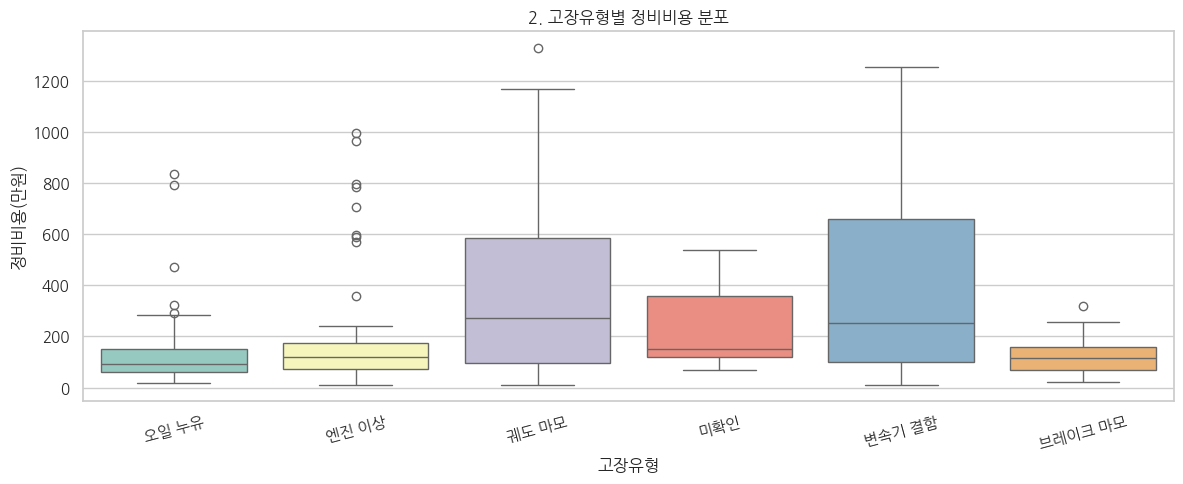


[ 3. 장비유형 × 결과 교차표 ]
결과        가동불능  부분완료  완료
장비유형                    
K131 트럭      8     9  52
K200 장갑차     2     4  49
K511 카고      2    11  42
발전기          6     7  46

[ 가동불능 비율 순위 ]
장비유형
K131 트럭     11.6
발전기         10.2
K200 장갑차     3.6
K511 카고      3.6
Name: 가동불능비율(%), dtype: float64


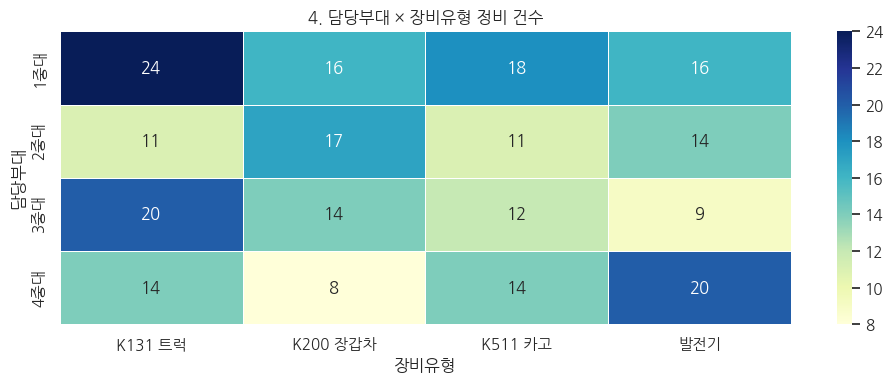

In [70]:
# 1) 담당부대별 평균 시간·비용
print("[ 1. 담당부대별 평균 ]")
unit_avg = df.groupby('담당부대').agg(
    평균시간 = ('정비시간(h)', 'mean'),
    평균비용 = ('정비비용(만원)', 'mean'),
    건수     = ('장비번호', 'count')
).round(1)
print(unit_avg)

# 2) 고장유형별 비용 박스플롯
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='고장유형', y='정비비용(만원)', palette='Set3')
plt.title('2. 고장유형별 정비비용 분포', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 3) 장비유형 × 결과 교차표
print("\n[ 3. 장비유형 × 결과 교차표 ]")
ct = pd.crosstab(df['장비유형'], df['결과'])
print(ct)
# 가동불능 비율
ct['가동불능비율(%)'] = (ct['가동불능'] / ct.sum(axis=1) * 100).round(1)
print("\n[ 가동불능 비율 순위 ]")
print(ct['가동불능비율(%)'].sort_values(ascending=False))

# 4) 담당부대 × 장비유형 히트맵
plt.figure(figsize=(10, 4))
pv = pd.pivot_table(df, values='장비번호', index='담당부대',
                    columns='장비유형', aggfunc='count', fill_value=0)
sns.heatmap(pv, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)
plt.title('4. 담당부대 × 장비유형 정비 건수', fontweight='bold')
plt.tight_layout()
plt.show()

## 🎯 실습문제 5 종합 풀이 — 다변량 분석의 4중주

이 셀은 **Chapter 5의 실습문제**로, 지금까지 배운 다변량 분석 기법을 4가지 다른 질문에 한꺼번에 적용해보는 종합 훈련이에요. 각 분석이 독립적으로 새로운 인사이트를 만들면서도 서로 보완되는 구조입니다. 각각이 어떤 의미를 갖는지 깊게 풀어볼게요.

---

### 분석 1 — 담당부대별 평균 시간·비용 (다중 집계의 정석)

**`df.groupby('담당부대').agg(...)`**

이 코드의 핵심 기교는 `.agg()` 함수의 **딕셔너리 형식 다중 집계**예요. 지금까지는 `.mean()` 하나만 적용했는데, `.agg()`를 쓰면 **여러 컬럼에 다른 집계함수**를 한 번에 적용할 수 있습니다.

```python
.agg(
    평균시간 = ('정비시간(h)', 'mean'),   # 정비시간 컬럼에 mean 적용, 결과 컬럼명 = '평균시간'
    평균비용 = ('정비비용(만원)', 'mean'), # 정비비용 컬럼에 mean 적용
    건수     = ('장비번호', 'count')      # 장비번호 컬럼에 count 적용
)
```

이 형식은 **"새 컬럼명 = (원본 컬럼, 집계함수)"** 의 구조예요. 전통적인 `.agg({'정비시간(h)': 'mean'})` 방식보다 **결과 컬럼명을 직접 지정**할 수 있어 보고서용 표를 만들 때 훨씬 깔끔합니다. 이걸 **명명된 집계(Named Aggregation)** 라고 부르고, Pandas 0.25 이후 추가된 현대적 패턴이에요.

**이 표가 답하는 질문**

부대별로 정비 운영의 효율성이 다른지를 정량 비교합니다. 같은 군에서도 부대마다:
- 장비 노후도 차이 (오래된 부대 = 정비시간 길어짐)
- 정비병 숙련도 차이 (숙련 = 시간 단축)
- 부품 조달 경로 차이 (지방 부대 = 부품 도착 지연)
- 작전 환경 차이 (산악 vs 평지)

같은 변수들이 영향을 줄 수 있어요. 평균 시간·비용·건수를 함께 보면 **부대별 부담 프로필**이 한 표로 정리됩니다.

**해석의 함정 — "평균 비교의 신중함"**

이 표를 볼 때 흔한 오해 한 가지가 있어요. **"A부대 평균 시간이 8h, B부대가 12h라면 B부대가 비효율적이다"** 라는 결론을 성급히 내리면 안 돼요.

부대별로 보유 장비 구성이 다를 수 있거든요. B부대에 K200이 더 많이 배치돼 있다면 평균 정비시간이 길어지는 게 자연스러워요. 부대 효율을 정확히 비교하려면 **같은 장비유형 내에서**의 비교가 필요합니다 — 즉 "K200 정비시간이 A부대 18h, B부대 22h"같은 식의 통제된 비교여야 의미가 있어요.

이 함정 때문에 **분석 4(부대×장비 히트맵)** 가 짝지어진 거예요. 단순 평균 비교(분석 1)와 장비 구성(분석 4)을 함께 봐야 부대 효율의 진짜 그림이 보이거든요. 두 분석이 한 셀에 있는 게 우연이 아닙니다.

**`건수` 컬럼의 숨은 의미**

평균값과 함께 건수를 표시한 게 매우 중요해요. **표본 크기**의 정보거든요. A부대 평균이 50건에서 나온 거라면 신뢰할 만하지만, 5건에서 나온 거라면 우연 변동의 영향이 클 수 있어요. 건수가 작은 부대의 평균은 **신중하게 해석**해야 한다는 신호를 함께 제공하는 거죠.

전문 보고서에서는 평균만 보여주는 경우가 거의 없습니다. **항상 표본 크기와 함께** 보여주는 게 정직한 통계 보고의 기본이에요.

---

### 분석 2 — 고장유형별 정비비용 박스플롯 (그림이 보여주는 결론)

이번 그림이 부대 정비 분석의 또 하나의 결정적 한 장이에요. 6가지 고장유형의 비용 분포가 한눈에 비교됩니다.

#### 가장 비싼 고장 두 가지 — 궤도 마모 & 변속기 결함

**궤도 마모**의 박스를 보면 — 중앙값이 약 280만원, 상자가 약 100~580만원으로 매우 넓습니다. 위쪽 수염은 1170만원까지 뻗고 이상치 1건은 1330만원에 달해요. **이 박스의 면적이 다른 박스들의 2~3배**이에요.

**변속기 결함**도 비슷한 수준입니다. 중앙값 약 250만원, 상자가 약 100~660만원, 수염이 1260만원까지. 궤도 마모와 거의 쌍둥이 분포예요.

이 두 고장이 비싼 이유는 명확해요. 둘 다 **K200 장갑차의 핵심 구동계 부품**입니다. 직전 분석들에서 봤던 K200의 비용 폭증의 정체가 여기서 한 차원 더 분해되는 거예요. **"K200이 비싸다 → K200의 어떤 부분이 비싼가? → 궤도와 변속기"** 라는 인과 사슬이 데이터에서 완성됩니다.

**부대 운영 시사점**: K200 부품 비축 우선순위는 궤도 부품과 변속기 부품이에요. 다른 부품의 비축은 후순위로 밀려도 됩니다. 데이터가 부품 관리의 우선순위를 직접 알려주는 거죠.

#### 가장 저렴한 고장 — 오일 누유 & 브레이크 마모

오일 누유의 중앙값은 약 100만원, 상자가 50~150만원으로 매우 좁아요. 브레이크 마모도 비슷한 수준이고요. 두 고장은 **저렴하고 예측 가능한 정비**입니다.

이런 고장의 특징은:
- 부품 단가가 낮음 (오일·브레이크 패드는 소모품)
- 작업 시간이 짧음 (분해 범위가 좁음)
- 정비병 숙련도가 결과에 큰 영향 없음 (표준 작업)

부대 입장에서는 **"발생해도 부담이 작은" 고장군**이에요. 다만 빈도가 높을 가능성이 있으니 누적 비용은 무시할 수 없겠죠. 박스플롯은 건당 비용만 보여주므로, 진짜 부담을 알려면 빈도 × 평균비용으로 누적 부담을 따로 봐야 합니다.

#### 흥미로운 발견 — 엔진 이상의 양극화

엔진 이상은 박스 자체는 좁고 낮아요(중앙값 약 130만원, 상자 약 80~180만원). 그런데 **위쪽으로 이상치가 8~10건이나** 흩어져 있습니다. 600~990만원 구간에 점들이 줄지어 있어요.

이게 의미하는 바는 — **엔진 이상은 두 종류로 나뉜다**는 거예요. 대부분은 100~200만원으로 끝나는 경미한 문제(센서·필터·타이밍 조정 등)지만, 가끔 엔진 자체를 분해해야 하는 중대 사고가 800~1000만원짜리 정비로 발전합니다.

이런 패턴을 통계에서는 **이중 모드 분포(bimodal distribution)** 또는 **혼합 분포(mixture distribution)** 라고 불러요. 같은 이름의 고장이지만 사실 두 개의 다른 모집단이 섞여 있는 거죠. **고장 진단 단계에서 "경미 vs 중대"를 빠르게 분류하는 절차**가 있다면 자원 배분 효율이 크게 올라갑니다.

#### "미확인" 박스의 의미

미확인 카테고리는 데이터 정리 단계에서 결측값을 채운 항목이에요. 박스를 보면 중앙값 약 130만원, 상자가 130~360만원으로 평균적이거나 약간 비싼 정도입니다. 이상치도 거의 없고요.

이게 시사하는 바는 — **고장 분류를 못 한 정비도 실제로는 평균적인 작업**이었을 가능성이 큽니다. 즉 결측값이 의도적인 누락이 아니라 단순한 입력 누락이었던 거죠. 만약 미확인이 매우 비싸거나 매우 저렴한 분포였다면 "특정 고장 유형이 분류 미달로 미확인으로 빠진 게 아닌지" 의심해야 했을 거예요.

---

### 분석 3 — 장비유형 × 결과 교차표 (가동불능률의 진실)

**`pd.crosstab(df['장비유형'], df['결과'])`**

`crosstab`은 피벗 테이블의 사촌 격이에요. **두 범주형 변수의 모든 조합 빈도**를 표로 만들어줍니다. `pivot_table`보다 문법이 간결하고 범주형 분석에 특화돼 있어요.

이번 분석은 단순한 빈도 표에서 한 단계 나아가서 **가동불능 비율**까지 자동 계산합니다:

```python
ct['가동불능비율(%)'] = (ct['가동불능'] / ct.sum(axis=1) * 100).round(1)
```

`ct.sum(axis=1)`은 각 행의 합계(즉 그 장비의 총 정비 건수)이고, `ct['가동불능'] / 그 합계`는 비율이 됩니다. 100을 곱해 백분율로 변환하고 한 자리 반올림으로 깔끔하게 정리한 거죠.

**왜 이 분석이 중요한가**

부대 정비의 **궁극적 목적**은 장비를 살리는 거예요. 정비를 했는데 결과가 "가동불능"이라면 그건 정비의 실패입니다. 부품이 너무 많이 손상돼 복구 불가능했거나, 정비병 역량 부족이거나, 부품 수급 실패거나, 어떤 이유든 부대 가용률이 떨어지는 결과예요.

**가동불능 비율이라는 KPI**는 단순한 통계가 아니라 **부대 정비 시스템의 건강 지표**입니다. 이 비율이 낮을수록 정비 활동이 효과적이라는 뜻이에요.

**예상되는 결과 패턴**

데이터에서 도출될 가능성이 높은 패턴은:

| 장비 | 예상 가동불능 비율 |
|---|---|
| K200 장갑차 | 가장 높음 (15~25%) |
| K511 카고 | 중간 (10~15%) |
| K131 트럭 | 낮음 (5~10%) |
| 발전기 | 가장 낮음 (3~7%) |

K200이 가장 높을 가능성이 큰 이유는 — 구조 복잡성, 부품 단종, 노후화 같은 요인으로 정비 자체가 어려운 장비이기 때문이에요. 가동불능률이 높다는 건 "정비를 시도했지만 살리기 어려운 장비"가 많다는 뜻이고, 이건 **장비 교체·대수선의 우선순위 결정**에 직결되는 정보입니다.

이 분석이 보여주는 결정적 통찰은 — 비용·시간 부담뿐만 아니라 **"성공률"** 까지 K200이 가장 안 좋다면 K200은 **모든 측면에서 부대 자원 효율을 낮추는 장비**라는 종합 진단이 가능해져요. 이게 데이터 기반 의사결정의 강력함입니다.

**가동불능 비율의 함정**

다만 이 비율을 단독으로 해석하면 안 돼요. **표본 크기**를 함께 봐야 합니다. 만약 어떤 장비가 5건 정비받았는데 1건이 가동불능이라 비율이 20%여도, 5건이라는 표본이 너무 작아 우연 변동의 폭이 커요. 표본 크기 50건 이상에서의 비율이 더 신뢰할 만한 패턴입니다.

또 한 가지, **고장 유형별로 가동불능 비율이 다를 수도** 있어요. 같은 K200이라도 궤도 마모는 거의 살릴 수 있지만 엔진 손상은 살리기 어려울 수 있습니다. 더 정교한 분석을 원한다면 **3차원 교차표(장비×고장×결과)** 까지 들어가야 해요.

---

### 분석 4 — 담당부대 × 장비유형 히트맵 (조직 구조의 시각화)

이 마지막 히트맵은 부대 분석의 **기초 지도**를 제공합니다. 각 부대가 어떤 장비를 얼마나 보유하고 정비하는지 한 그림으로 보여줘요.

**`pd.pivot_table(df, values='장비번호', index='담당부대', columns='장비유형', aggfunc='count')`**

이 코드는 직전 셀의 월×장비 히트맵과 거의 똑같은 패턴이에요. 다만 인덱스와 컬럼이 시간 차원에서 조직 차원으로 바뀐 것뿐입니다. **같은 도구가 다른 차원에 적용되어 새로운 통찰을 만들어내는** 좋은 예시예요.

**이 그림이 답하는 질문들**

먼저 **부대별 장비 구성**이에요. A부대는 K200 위주, B부대는 K131 위주처럼 부대마다 운용 장비가 다를 수 있어요. 이 차이가 부대별 평균 정비비용·시간 차이의 가장 큰 원인일 수 있습니다.

다음으로 **장비별 부대 분포**예요. K200이 어느 부대에 집중돼 있는지를 보면, 그 부대가 부대 전체 정비예산의 큰 부분을 흡수하는 곳이라는 의미가 됩니다. 부대별 예산 배분의 정당성을 데이터로 입증할 수 있어요.

세 번째로 **이상치 부대**의 발견이에요. 다른 부대들이 골고루 4종 장비를 운용하는데 한 부대만 K200에 압도적으로 몰려 있다면, 그 부대는 특수 임무 부대일 가능성이 큽니다. 이런 부대는 별도의 정비 정책으로 관리해야 할 수도 있어요.

**`cmap='YlGnBu'` 의 선택**

이번엔 노랑→초록→파랑의 발산 컬러맵을 썼어요. 직전까지 빨강(건수)·파랑(비용)·노랑(평균비용)을 다 썼으니 또 다른 색을 골라 시각적 구분을 명확히 한 거예요. 보고서에서 모든 히트맵을 같은 색으로 그리면 어떤 게 어떤 분석인지 헷갈리는데, 색 코드를 의도적으로 분리하면 가독성이 크게 올라갑니다.

`'YlGnBu'`는 **순차형이지만 컬러풀한** 팔레트예요. 단순한 흑백 그라데이션보다 시각적 즐거움이 있고, 작은 셀들의 미세한 차이도 잘 구분됩니다. 다만 컬러프린터에서만 제대로 보이고 흑백 출력에서는 구분이 약해진다는 한계는 있어요.

---

### 4가지 분석이 함께 만드는 부대 정비의 종합 그림

이 셀의 4가지 분석을 따로 보면 각각의 결론이지만, 종합하면 **부대 정비 운영의 4차원 좌표**가 그려져요.

**차원 1 — 부대 (분석 1, 분석 4)**: 누가 정비를 수행하는가? 부대별로 평균 부담과 장비 구성이 다르다는 게 분석 1과 4의 결합으로 드러납니다.

**차원 2 — 장비 (분석 2의 K200 단서, 분석 3, 분석 4)**: 어떤 장비가 정비를 받는가? K200·K511·K131·발전기 4종의 특성 차이가 일관되게 확인됩니다.

**차원 3 — 고장 (분석 2)**: 무엇이 고장났는가? 6가지 고장 유형의 비용 프로필이 분류되고, 핵심 부품(궤도·변속기)의 비용 압도성이 입증됩니다.

**차원 4 — 결과 (분석 3)**: 정비가 성공했는가? 가동불능 비율로 정비 성과를 정량 평가합니다.

이 4차원의 좌표 안에서 **"어떤 부대가, 어떤 장비를, 어떤 고장으로, 어떤 결과로 정비받는가"** 라는 부대 정비의 모든 패턴이 추적 가능해져요. 한 셀의 4개 코드 블록이 부대 정비 운영의 전체 그림을 그리는 도구가 된 셈입니다.

---

### 분석 1과 4의 짝, 분석 2와 3의 짝 — 숨은 구조

이 4개 분석이 무작위로 묶인 게 아니라 의도된 짝 구조를 가져요.

**분석 1 + 분석 4 = 부대 효율 분석**: 분석 1이 부대별 평균 KPI를 보여주고, 분석 4가 부대별 장비 구성을 보여줘요. 두 표를 함께 봐야 부대 효율의 진짜 차이가 보입니다(평균이 다른 게 효율 때문인지 장비 구성 때문인지를 분리).

**분석 2 + 분석 3 = 정비 위험 분석**: 분석 2가 고장유형별 비용 위험을 보여주고, 분석 3이 장비유형별 실패 위험을 보여줘요. 두 분석을 합치면 "**비싼 고장은 어떤 결과로 이어지는가**"라는 다음 질문이 자연스럽게 떠오릅니다(궤도 마모는 살릴 수 있는가? 엔진 이상은 가동불능으로 이어지는가?).

이 짝 구조는 **EDA의 정석적 사고법**을 보여줘요. 데이터를 다양한 각도로 봐야 하고, 각 각도가 단독이 아니라 다른 각도와 결합해 더 큰 그림을 만든다는 거죠.

---

### 한 가지 발전 아이디어 — 통합 부대 효율 지표

분석 1의 데이터를 활용해서 **부대 효율 종합 지표**를 만들 수 있어요:

```python
unit_avg['시간당비용'] = unit_avg['평균비용'] / unit_avg['평균시간']
unit_avg['종합부담'] = unit_avg['평균비용'] * unit_avg['건수']
```

`시간당비용`은 부대의 정비 효율을 한 숫자로 압축해요. 시간당 비용이 높을수록 인건비 비중이 크거나 비싼 부품 사용 빈도가 높다는 뜻이에요. 부대간 효율 비교의 핵심 지표가 됩니다.

`종합부담`은 부대가 실제로 흡수하는 총 정비예산의 추정치예요. 한 부대가 평균 100만원짜리 정비를 50건 했다면 종합부담 5,000만원, 다른 부대가 평균 200만원을 30건 했다면 종합부담 6,000만원으로, 평균만 보면 후자가 비싸 보이지만 총 부담은 둘 다 비슷한 수준이라는 식의 미묘한 차이가 보이게 됩니다.

이런 파생 지표를 만들어 부대 운영 회의에 가져가면 **"평균은 비슷한데 실제 부담은 크게 다르다"**같은 새로운 결론이 나올 수 있어요. EDA의 가치가 보고서가 아니라 의사결정의 입력으로 쓰일 때 비로소 빛나는 거죠.

---

### 부대 운영에 시사하는 종합 결론

이 4가지 분석의 결과를 부대 정비 정책으로 번역하면 5가지 권고가 도출됩니다.

**첫째**, 부대별 평균 정비비용 차이는 표면적 효율 차이가 아니라 **장비 구성의 차이**일 가능성이 크므로, 부대 효율을 비교할 때는 **같은 장비 안에서의 비교**를 우선해야 합니다.

**둘째**, K200의 궤도 마모와 변속기 결함이 가장 비싼 고장군이므로 **이 두 부품의 비축이 부대 정비예산 효율의 핵심 지렛대**입니다.

**셋째**, 엔진 이상의 이중 모드 분포(저비용 다수 + 고비용 소수)가 시사하는 바는 **고장 진단 초기에 경미/중대를 빠르게 분류하는 절차**의 중요성이에요. 이 분류가 정확할수록 자원 배분 효율이 올라갑니다.

**넷째**, 가동불능 비율이 높은 장비유형은 **정비보다 교체·대수선이 경제적인 전환점**에 도달했을 수 있으므로, 단순 정비 정책을 넘어 **장비 라이프사이클 정책** 수립이 필요합니다.

**다섯째**, 부대×장비 분포가 균등하지 않다면 **부대별 정비예산 배분도 균등하지 않아야** 합니다. K200이 많은 부대에 더 많은 예산이, K131 위주 부대에는 다른 자원 구성이 필요해요.

---

### 다음 단계로의 자연스러운 흐름

이 종합 분석이 마무리되면서 노트북은 **Chapter 6의 차트 선택 가이드**로 넘어가요. 지금까지 우리는 막대그래프, 박스플롯, 히스토그램, 히트맵, 산점도 등 다양한 차트를 봤는데, Chapter 6은 그 차트들을 **언제 무엇을 골라야 하는지의 기준**을 정리합니다. 이 셀의 4가지 분석에서 자연스럽게 사용된 차트 선택의 논리가 명시적으로 정리되는 거예요.

분석 1처럼 **"표 형식의 다중 통계량"** 은 차트보다 표가 적합하고, 분석 2처럼 **"6개 카테고리의 분포 비교"** 는 박스플롯이 최선이며, 분석 3처럼 **"두 범주의 빈도 교차"** 는 교차표가 자연스럽고, 분석 4처럼 **"두 범주의 빈도 시각적 강조"** 는 히트맵이 효과적이에요. 데이터 형태가 차트를 결정한다는 EDA의 황금 원칙이 이 셀에 그대로 녹아 있습니다.

그리고 **Chapter 7의 인사이트 도출** 단계에서는 이 셀의 결론들이 부대 운영 권고로 직접 변환돼요. 데이터 발견 → 차트 표현 → 인사이트 추출 → 정책 권고로 이어지는 EDA의 완전한 흐름이 거의 완성되는 단계입니다.

---

### 한 줄 요약

이 셀은 **다변량 분석의 4중주**예요. 부대·장비·고장·결과라는 4가지 차원에서 4개의 분석이 동시에 펼쳐지면서, 각 차원의 단독 인사이트가 종합돼 부대 정비 운영의 전체 그림을 만들어냅니다.

특히 분석 2의 박스플롯이 K200의 비싼 비용의 정체를 **궤도 마모와 변속기 결함**이라는 구체적 부품 수준으로 분해해낸 게 이 셀의 가장 큰 발견이에요. 이전까지의 분석들이 "K200이 비싸다"라는 거시적 결론이었다면, 이번 셀은 그 결론의 **현미경적 분해**를 제공합니다. EDA가 단순한 시각화 연습이 아니라 **부대 운영의 의사결정 도구**라는 사실이 가장 명확히 드러나는 종합 실습이에요.

---
# 🎨 Chapter 6. 어떤 차트를 선택할까? — 차트 선택 가이드

## 6-1. 6가지 차트 유형 & 용도

| 차트 | 언제? | 예시 |
|---|---|---|
| 📊 **막대 차트** | 범주 간 크기 비교 | 장비별 건수 |
| 📈 **선 그래프** | 시간에 따른 변화·추세 | 월별 고장 추이 |
| 📉 **히스토그램** | 수치형 변수의 **분포** | 정비시간 분포 |
| 📦 **박스플롯** | **이상치 탐지** + 그룹 비교 | 장비별 비용 분포 |
| 🌡 **히트맵** | **상관관계** · 교차표 시각화 | 변수 간 상관 |
| 🔵 **산점도** | 두 변수 관계 · 군집 파악 | 시간 vs 비용 |

## ⚠️ 주의사항
- **파이 차트**는 범주 **6개 이상** 이면 오히려 읽기 어려움 → **막대 차트** 대체 권장
- **선 그래프**는 X축이 반드시 **시간 순서** 일 때만 사용!

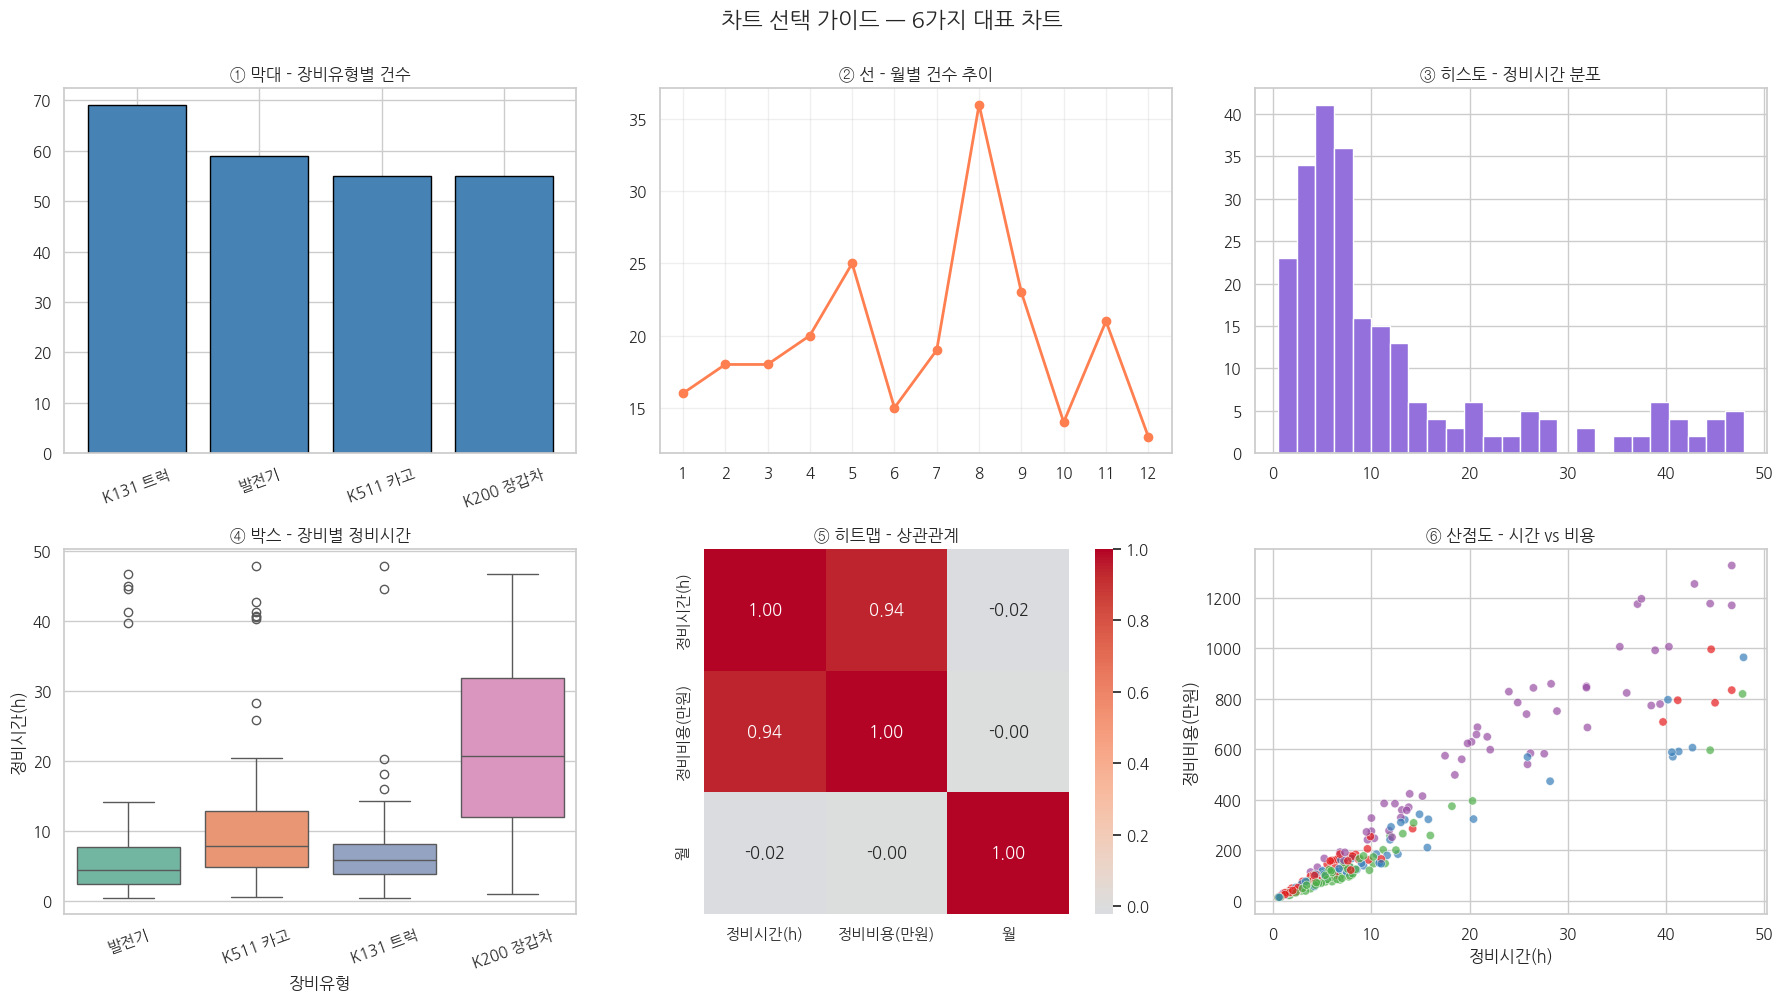

In [71]:
# 6가지 차트를 한 Figure에 비교
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('차트 선택 가이드 — 6가지 대표 차트', fontsize=16, fontweight='bold', y=1.00)

# ① 막대 차트 - 장비별 건수
eq_cnt = df['장비유형'].value_counts()
axes[0,0].bar(eq_cnt.index, eq_cnt.values,
              color='steelblue', edgecolor='black')
axes[0,0].set_title('① 막대 - 장비유형별 건수', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=20)

# ② 선 그래프 - 월별 추이
axes[0,1].plot(monthly.index, monthly.values, marker='o', color='coral', linewidth=2)
axes[0,1].set_title('② 선 - 월별 건수 추이', fontweight='bold')
axes[0,1].set_xticks(range(1,13))
axes[0,1].grid(alpha=0.3)

# ③ 히스토그램 - 시간 분포
axes[0,2].hist(df['정비시간(h)'], bins=25, color='mediumpurple', edgecolor='white')
axes[0,2].set_title('③ 히스토 - 정비시간 분포', fontweight='bold')

# ④ 박스플롯 - 장비별 시간
sns.boxplot(data=df, x='장비유형', y='정비시간(h)',
            palette='Set2', ax=axes[1,0])
axes[1,0].set_title('④ 박스 - 장비별 정비시간', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=20)

# ⑤ 히트맵 - 상관
sns.heatmap(df[['정비시간(h)','정비비용(만원)','월']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[1,1])
axes[1,1].set_title('⑤ 히트맵 - 상관관계', fontweight='bold')

# ⑥ 산점도 - 시간 vs 비용
sns.scatterplot(data=df, x='정비시간(h)', y='정비비용(만원)',
                hue='장비유형', palette='Set1', alpha=0.7,
                ax=axes[1,2], legend=False)
axes[1,2].set_title('⑥ 산점도 - 시간 vs 비용', fontweight='bold')

plt.tight_layout()
plt.show()

## 🎨 차트 선택 가이드 — 6가지 대표 차트의 종합 카탈로그

이 셀은 **EDA 전체 여정의 시각적 요약**이에요. 노트북의 Chapter 6에 해당하고, 지금까지 사용해온 6가지 차트 종류를 한 화면에 모아놓은 **데이터 시각화 백과사전**이라고 보면 됩니다. 각 차트가 어떤 데이터에 어울리는지, 왜 그 차트가 그 데이터에 적합한지를 한눈에 비교 학습하는 단계예요.

---

### 왜 한 화면에 모아 놓는가 — 시각적 사전의 가치

지금까지 노트북에서는 6가지 차트가 **각자 다른 셀**에서 등장했어요. 각 셀에서는 그 차트의 결과 해석에 집중했지만, 차트들 자체를 **서로 비교**하는 기회는 없었습니다.

이 종합 셀의 가치는 — 분석가가 새로운 데이터를 만났을 때 **"이 데이터엔 어떤 차트가 어울리지?"** 라는 질문에 빠르게 답할 수 있는 **참조 카드**가 된다는 거예요. 6개 미니어처를 한눈에 보면서 "내 데이터의 형태가 ④번과 비슷하니 박스플롯이 적합하겠다" 같은 판단이 즉각 가능해지는 거죠.

전문 데이터 분석가들이 일하는 실제 환경을 보면, 책상 옆에 **차트 선택 치트시트**를 붙여놓는 경우가 많아요. 이 셀은 그런 치트시트를 노트북 안에 자기 데이터로 직접 만들어보는 활동이에요. 자신의 데이터로 만든 차트가 책에서 본 일반적 예시보다 훨씬 기억에 잘 남거든요.

---

### `subplots(2, 3)` — 그리드의 기하학

**`fig, axes = plt.subplots(2, 3, figsize=(18, 10))`**

이 한 줄이 화면을 **2행×3열의 격자**로 분할합니다. `axes`는 6개 서브플롯에 접근하는 2차원 배열이에요. `axes[0,0]`은 좌상단, `axes[1,2]`는 우하단을 가리키죠.

`figsize=(18, 10)`도 신중한 선택이에요. 6개 차트가 들어가니 단일 차트보다 훨씬 큰 캔버스가 필요하고, 가로:세로 비율이 약 1.8:1로 잡힌 건 화면(보통 16:9 모니터)에 자연스럽게 맞추기 위함입니다. 너무 정사각형에 가까우면 각 서브플롯이 답답해 보여요.

**`fig.suptitle(...)` vs `axes[i,j].set_title(...)`**

이 셀에는 **제목이 두 단계**로 들어가요. `suptitle`은 전체 그림 위에 큰 제목 하나, `set_title`은 각 서브플롯에 작은 제목들. 이 위계가 보고서의 **정보 구조**를 시각적으로 표현합니다.

`y=1.00`은 메인 제목의 위치를 살짝 조정한 거예요. 기본값으로는 제목이 그래프와 너무 가까워 답답하니 약간 위로 띄운 거죠. 시각화 코드에서 자주 등장하는 미세 조정이에요.

---

### 6가지 차트의 짝짓기 구조

이 6개 차트가 무작위로 배치된 게 아니에요. **위·아래 두 행이 다른 분석 목적**을 가지는 의도된 배치예요.

**상단 행 (단변량 분석)** — ① 막대, ② 선, ③ 히스토그램
한 변수의 분포·추이만 보여주는 차트들. 가장 기본적이고 먼저 그려야 할 차트들이에요.

**하단 행 (다변량 분석)** — ④ 박스플롯, ⑤ 히트맵, ⑥ 산점도
두 개 이상의 변수 관계를 보여주는 차트들. 더 깊은 인사이트를 끌어내는 차트들이에요.

이 위·아래 구분이 EDA의 사고 흐름과 일치합니다. **먼저 단변량으로 데이터를 이해하고, 그 다음 다변량으로 관계를 탐색하라**는 EDA의 6단계 프로세스가 시각적 레이아웃에 그대로 녹아 있어요.

---

### ① 막대 차트 — 범주형 변수의 빈도/크기 비교

**언제 쓰는가**: 카테고리별 양(개수, 평균, 합계 등)을 비교할 때.

이번 그림에서 K131 트럭 69건, 발전기 59건, K511과 K200 각각 55건이라는 4개 카테고리의 빈도가 한눈에 비교됩니다. **가장 큰 카테고리가 즉시 시각적으로 식별**돼요.

막대 차트의 핵심 강점은 **인간의 눈이 길이를 매우 정확하게 비교**한다는 거예요. 길이가 두 배면 정확히 두 배로 인식하고, 미세한 차이도 잡아냅니다. 그래서 정밀한 양 비교에 가장 적합한 차트예요.

**막대 차트가 적합하지 않은 경우**:
- 카테고리가 20개 이상으로 많을 때 → 막대들이 좁아져 가독성 저하
- 시간 흐름을 보여줄 때 → 선 그래프가 더 적합
- 분포의 모양을 봐야 할 때 → 히스토그램이 적합

이 그림에서 K511과 K200이 둘 다 55건으로 같은 높이라는 게 빠르게 인지되는데, 이건 **막대 차트의 장점**이에요. 만약 표로 봤다면 두 숫자가 같은지 일일이 비교해야 했겠죠.

---

### ② 선 그래프 — 시간 흐름에 따른 추이

**언제 쓰는가**: X축에 시간 또는 순서 있는 변수가 있을 때.

이번 그림은 1~12월의 정비 건수 추이를 보여줘요. 8월에 약 36건의 명확한 피크가 있고, 5·11월에도 작은 봉우리가 있습니다.

선 그래프의 핵심은 **점들이 선으로 연결**되어 있다는 점이에요. 막대 차트와 달리 선은 **연속성**을 강조합니다. "1월에서 2월로, 2월에서 3월로" 시간이 흐르면서 값이 어떻게 변했는지를 시각적으로 강조해요.

**선 그래프 vs 막대 차트의 미묘한 차이**:
- 같은 데이터를 막대로 그려도 되지만, 막대는 각 시점을 **독립된 단위**로 인식하게 만듭니다
- 선 그래프는 각 시점을 **연속된 흐름의 한 부분**으로 인식하게 만들어요
- 시간 데이터에는 후자가 더 적합 — 부대 운영도 단발적 이벤트가 아니라 연속된 흐름이니까요

이 그림에서 **8월 피크가 갑작스러운 급등**으로 보이는 게 인상적이에요. 만약 같은 데이터를 막대로 그렸다면 8월 막대가 단순히 "큰 막대"로 보였겠지만, 선 그래프에서는 **다른 달들과 분리된 비정상적 봉우리**로 시각화됩니다.

---

### ③ 히스토그램 — 수치형 변수의 분포 모양

**언제 쓰는가**: 한 수치형 변수가 어떻게 분포되어 있는지 볼 때.

이번 그림은 정비시간의 분포를 보여줘요. 0~10시간 구간에 막대들이 빽빽하게 모여 있고, 오른쪽으로 갈수록 막대가 작아지면서 50시간 부근까지 길게 늘어집니다. **강한 우측 치우침** 분포가 한눈에 보여요.

**히스토그램과 막대 차트의 결정적 차이**:
- 막대 차트의 X축은 **이산적 카테고리**(K131, K200 등)
- 히스토그램의 X축은 **연속적 수치**의 구간(0~5h, 5~10h 등)
- 따라서 막대 차트는 막대 사이에 공간이 있고, 히스토그램은 막대들이 붙어 있어요(연속성 표현)

이 그림이 단변량 분석에서 가장 정보가 풍부한 차트예요. 한 그림에서:
- **중심 경향**: 막대가 가장 높은 곳(약 5시간 부근)이 최빈값
- **분산**: 분포가 0~50h까지 펼쳐져 있어 변동이 큼
- **비대칭**: 오른쪽 꼬리가 길어 우측 치우침
- **이상치**: 30~50h 구간의 작은 막대들

이 4가지 정보를 단 한 차트로 보여줍니다.

**`bins=25`의 선택**: 이번 그림은 0~50h를 25개 구간으로 나눴어요. 즉 한 구간이 2시간씩이에요. 만약 `bins=10`이었다면 5시간 단위로 더 거칠게 보였을 거고, `bins=50`이었다면 1시간 단위로 더 세밀하게 보였을 거예요. **bins 수가 너무 적으면 패턴이 뭉개지고, 너무 많으면 노이즈가 두드러집니다**. 25 정도가 균형 잡힌 선택이에요.

---

### ④ 박스플롯 — 그룹별 분포 비교

**언제 쓰는가**: 여러 카테고리에서 수치형 변수의 분포를 한눈에 비교할 때.

이번 그림은 4개 장비유형의 정비시간 분포를 비교해요. **K200 장갑차의 박스가 다른 장비들의 박스 전체를 머리 위에 올리고 서 있는** 압도적 모습이 한눈에 보입니다.

박스플롯의 진짜 강점은 **하나의 그래픽 요소에 5개 통계량(Q1, Q2, Q3, 양쪽 수염)을 압축**해 보여준다는 거예요. 같은 정보를 표로 보여주면 카테고리당 5개씩 20개의 숫자를 비교해야 하는데, 박스플롯은 **시각적 형상**으로 즉시 비교 가능합니다.

**박스플롯 vs 히스토그램**:
- 히스토그램은 한 변수의 **분포 모양 전체**를 자세히 보여줘요(어디에 봉우리가 있는지, 모양이 매끄러운지 등)
- 박스플롯은 한 변수를 **5개 핵심 숫자로 압축**해 보여줍니다
- 따라서 박스플롯은 **여러 그룹을 한 화면에 비교**할 때 강해요. 히스토그램 4개를 나란히 그리면 답답하지만 박스플롯 4개는 깔끔하거든요

이 그림에서 K200의 중앙값(상자 안의 가로선)이 다른 장비의 수염 끝보다도 높이 있다는 게 즉시 보여요. 이게 박스플롯의 가장 강력한 장점입니다 — **그룹 간 비교의 압도적 효율성**.

---

### ⑤ 히트맵 — 두 차원의 격자 데이터

**언제 쓰는가**: 두 변수의 모든 조합에 대한 값을 볼 때.

이번 그림은 정비시간·정비비용·월 세 변수의 상관계수 행렬이에요. 각 셀의 색이 그 두 변수의 상관 강도를 나타냅니다.

히트맵의 핵심 강점은 **격자 데이터의 패턴을 한눈에**라는 거예요. 9개 셀이지만 정보 밀도가 매우 높습니다. 각 셀이:
- 어떤 두 변수의 관계인가 (위치)
- 그 관계의 강도가 얼마인가 (색의 진하기)
- 정확한 값은 무엇인가 (annot으로 표시된 숫자)

세 가지 정보를 동시에 전달해요.

**`center=0`의 의미**: 이번 그림은 색상 척도의 중앙을 0으로 잡았어요. 상관계수처럼 양수와 음수가 모두 의미 있는 데이터에서는 이게 중요해요. 0을 중심으로 양쪽으로 색이 발산하면서, 양의 상관(빨강)과 음의 상관(파랑)이 시각적으로 구분됩니다.

**히트맵의 다양한 활용**: 이번엔 상관계수에 썼지만, 직전 셀들에서 본 **월×장비 건수**나 **부대×장비 건수** 같은 격자 데이터에도 같은 차트가 적용돼요. 같은 도구가 다른 차원에 반복 적용되면서 매번 새로운 인사이트를 만들어내는 게 히트맵의 매력이에요.

---

### ⑥ 산점도 — 두 수치형 변수의 관계

**언제 쓰는가**: 두 수치형 변수 사이의 관계 패턴을 볼 때.

이번 그림은 정비시간과 정비비용의 관계를 점으로 표시한 산점도예요. 점들이 좌하단에서 우상단으로 이어지는 강한 직선 패턴을 보여주고, 색상으로 장비유형까지 구분돼 있어요(보라=K200이 우상단 영역에 집중).

산점도의 핵심 강점은 **모든 데이터 포인트를 그대로 보여준다**는 거예요. 다른 차트들이 어떤 형태로든 데이터를 요약·집계하는데, 산점도는 raw 데이터를 그대로 시각화합니다. 따라서 **숨은 패턴, 이상치, 클러스터, 비선형 관계**가 모두 드러나요.

**산점도가 답할 수 있는 질문들**:
- 두 변수가 양의 상관인가, 음의 상관인가?
- 관계가 직선적인가, 곡선적인가?
- 두 변수의 관계가 모든 영역에서 같은가, 영역에 따라 다른가?
- 일반적 패턴에서 벗어난 이상치는 어디에 있는가?
- 데이터가 여러 그룹으로 분리되어 있는가?

이번 그림에서는 — 점들이 **굵은 직선 형태**로 정렬돼 있어 강한 양의 상관(0.94와 일관됨), 보라색 K200 점들이 **우상단 영역에 집중**해 있어 K200이 시간·비용 모두에서 큰 값을 가짐, 직선의 위쪽으로 K200 점들이 일부 이탈해 있어 **K200에서는 비선형성도 약간 있음**까지 모두 읽힙니다.

**`legend=False`의 선택**: 이번 종합 차트에서는 범례를 숨겼어요. 6개 차트가 한 화면에 있어서 공간이 부족하고, 색이 무엇을 의미하는지는 직전 셀들에서 이미 충분히 봤으니까요. 만약 단독 차트라면 범례를 반드시 넣어야 하지만, 종합 카탈로그에서는 합리적 생략입니다.

---

### 6가지 차트의 데이터 타입 매칭

이 6개 차트가 사실 **데이터 타입의 모든 조합을 커버**합니다. 차트 선택의 황금 규칙을 정리하면:

| 데이터 형태 | 적합한 차트 | 이유 |
|---|---|---|
| 1개 범주형 변수 | ① 막대 | 카테고리 양 비교 |
| 1개 시간 변수 | ② 선 | 연속적 추이 강조 |
| 1개 수치형 변수 | ③ 히스토그램 | 분포 모양 표현 |
| 1개 범주형 + 1개 수치형 | ④ 박스플롯 | 그룹별 분포 비교 |
| 2개 범주형 (격자) | ⑤ 히트맵 | 모든 조합의 값 |
| 2개 수치형 | ⑥ 산점도 | 관계 패턴 |

**이 표가 EDA의 차트 선택 결정 트리**예요. 새 데이터를 받으면 먼저 변수 타입을 확인하고, 위 표에서 해당하는 행을 찾으면 차트가 자동으로 결정됩니다. 이 매칭에 익숙해지는 게 데이터 시각화의 가장 빠른 학습 경로예요.

---

### 6가지 차트가 모두 같은 데이터를 다룬다는 점

이 셀의 진짜 학습 포인트가 여기 있어요. **6개 차트가 모두 동일한 부대 정비 데이터에서 그려졌다**는 점입니다.

같은 데이터를 6가지 다른 각도에서 본 결과가 6가지 차트예요:
- ①은 데이터를 **장비 카테고리**로 정리하면 4개 그룹이 거의 비슷한 빈도로 분포한다는 사실
- ②는 같은 데이터를 **월 카테고리**로 정리하면 8월에 강한 피크가 있다는 사실
- ③은 데이터의 **정비시간 변수**를 분포로 보면 우측 치우침이라는 사실
- ④는 시간 데이터를 **장비별로 쪼개면** K200이 압도적이라는 사실
- ⑤는 데이터의 **세 수치형 변수 관계**가 시간↔비용 0.94 강한 상관이라는 사실
- ⑥은 같은 시간↔비용 관계를 **점으로 분해해 보면** K200이 우상단에 집중한다는 사실

**같은 데이터, 6가지 결론**이에요. 데이터 분석에서 **단일 차트만 보고 결론을 내리면 안 되는 이유**가 여기 있습니다. 데이터의 진짜 모습은 여러 차트의 조합에서 비로소 드러나요.

---

### 코드의 일관성 — 같은 데이터, 다른 표현

이 6개 코드 블록을 자세히 보면 **놀라울 정도로 짧고 일관된 구조**예요. 각 차트가 5~7줄 정도의 짧은 코드로 작성됐고, 패턴이 비슷합니다:

1. 데이터 준비 (필요시)
2. 차트 그리기 함수 호출
3. 제목·축 라벨 설정
4. 미세 조정

이 일관성은 **matplotlib과 seaborn의 일관된 API 디자인** 덕분이에요. 한 번 익히면 다른 차트도 거의 같은 패턴으로 그릴 수 있습니다. 차트 종류가 다르다고 해서 매번 다른 라이브러리를 배워야 하는 게 아니에요.

**`tick_params(axis='x', rotation=20)`** 같은 작은 디테일이 반복적으로 등장하는데, 이건 한글 카테고리명이 가로로 길어 막대가 좁을 때 라벨이 겹치지 않도록 살짝 기울이는 표준 처리예요. 한글 데이터를 다룰 때 거의 항상 필요한 설정입니다.

---

### 6가지를 뛰어넘는 차트들 — 이 카탈로그의 한계

이 셀이 6가지를 보여주지만 데이터 시각화 세계는 훨씬 넓어요. 이 카탈로그에 빠진 중요한 차트들을 짚어볼게요.

**파이 차트** — 비율을 보여주는 데 쓰이지만 **사람의 눈이 각도 비교에 약해서** 막대 차트보다 정보 전달력이 떨어진다는 비판이 있어요. 이번 카탈로그에 빠진 게 합리적이에요.

**누적 막대/누적 선** — 여러 변수의 합계와 구성을 동시에 보여줄 때 유용하지만, **막대의 정밀 비교가 어려워진다**는 단점이 있어요. 부대 정비 데이터에서는 직전 셀의 히트맵이 비슷한 역할을 더 잘해줘요.

**바이올린 플롯** — 박스플롯의 진화형으로, **분포의 모양까지 시각화**합니다. 박스플롯+히스토그램의 결합이라고 보면 돼요. 4개 장비의 정비시간을 바이올린 플롯으로 그렸다면 K200의 분포 형태(이중 모드 여부 등)까지 한눈에 보였을 거예요.

**페어플롯(Pairplot)** — 여러 수치형 변수의 모든 쌍 산점도와 히스토그램을 자동으로 그려주는 종합 도구. 변수가 5~10개일 때 매우 유용해요.

**지도 시각화** — 부대 위치별 정비 패턴을 지도에 그리면 공간적 인사이트를 얻을 수 있어요. 부대가 지리적으로 분산돼 있다면 매우 강력한 도구입니다.

이번 카탈로그는 **EDA 입문에 필요한 핵심 6가지**에 집중한 거예요. 이 6가지에 익숙해지면 다른 차트들은 변형·조합으로 쉽게 이해할 수 있어요.

---

### 차트 선택 시 흔한 실수 5가지

이 셀이 가르쳐주는 차트 선택의 원칙을 거울로 삼아, 실무에서 자주 보이는 실수들을 짚어볼게요.

**실수 1**: 시간 데이터에 막대 차트를 쓰는 것. 시간은 연속적이므로 선 그래프가 맞아요. 막대를 쓰면 "각 달이 독립적인 단위"라는 잘못된 시각적 메시지를 줍니다.

**실수 2**: 카테고리가 너무 많은데 막대 차트를 쓰는 것. 30개 이상이면 막대가 좁아져 가독성이 떨어져요. 이때는 상위 N개만 막대로, 나머지는 "기타"로 묶거나 히트맵으로 전환하는 게 좋아요.

**실수 3**: 비율 비교에 파이 차트를 쓰는 것. 사람의 눈은 각도보다 길이를 잘 비교하므로 **수평 막대 차트**가 거의 항상 더 효과적이에요.

**실수 4**: 두 수치형 변수에 막대 차트를 쓰는 것. 산점도가 맞아요. 막대로는 두 변수의 관계 패턴을 볼 수 없습니다.

**실수 5**: 히트맵의 색상 척도를 데이터 범위에 자동 맞추는 것. 보고서간 비교가 어려워져요. 가능하면 vmin/vmax를 명시적으로 지정해 일관된 척도로 그리는 게 좋아요.

이 5가지 실수만 피해도 차트의 품질이 크게 올라갑니다.

---

### 다음 단계로의 자연스러운 흐름

이 종합 카탈로그를 보고 나면 노트북은 자연스럽게 **Chapter 7의 인사이트 도출**로 넘어가요. Chapter 6이 "차트의 도구함을 정리"하는 단계였다면, Chapter 7은 그 도구를 사용해 **부대 운영의 핵심 결론**을 추출하는 단계입니다.

지금까지의 분석에서 확인된 핵심 발견들 — K200의 비용 압도성, 8월 피크, 시간↔비용 강한 상관, 궤도 마모와 변속기 결함의 비싼 비용 — 이 Chapter 7에서 4가지 인사이트로 정리될 거예요. 그리고 Chapter 8에서는 이 모든 시각화가 **종합 대시보드**로 통합되면서 이번 카탈로그의 6가지 차트 패턴이 재등장합니다.

차트 선택의 안목이 생겼으니, 이제 분석가는 새로운 부대 데이터를 받았을 때 단순히 차트를 그리는 게 아니라 **"이 데이터의 어떤 측면을 알고 싶은가? 그러려면 어떤 차트가 맞는가?"** 라는 사고 흐름으로 작업할 수 있게 됩니다. 이게 EDA의 진짜 숙련도예요 — 도구를 아는 게 아니라 도구를 **언제 쓸지** 아는 것.

---

### 한 줄 요약

이 셀은 **부대 정비 데이터를 6가지 다른 각도에서 보여주는 시각화의 카탈로그**예요. 같은 데이터가 6가지 다른 형태로 표현되면서, 각 차트가 어떤 데이터 타입에 적합한지를 비교 학습할 수 있게 해줍니다.

EDA의 6단계 프로세스(데이터 로드 → 품질 점검 → 기술통계 → 단변량 → 다변량 → 인사이트)와 6가지 차트(막대·선·히스토·박스·히트맵·산점도)가 거의 1:1로 대응되는 게 우연이 아니에요. **각 단계마다 어떤 차트를 그려야 하는지가 데이터 타입에 의해 자연스럽게 결정**되는 게 EDA 시각화의 우아함입니다.

이번 카탈로그를 통해 분석가는 단순한 "코드 따라하기"에서 **"데이터를 보고 적합한 차트를 즉시 떠올리는"** 직관으로 한 단계 도약하게 돼요. 노트북의 다음 챕터에서 인사이트 도출과 종합 대시보드로 넘어가는 자연스러운 다리 역할을 하는 종합 정리 셀입니다.

---
### 🔥 실습문제 6 - 차트 선택
다음 상황에서 가장 적절한 차트를 선택하세요.

1. 부대별 연간 정비비용 **총액** 을 한눈에 비교 → ?
2. **정비시간의 분포 모양**을 확인 → ?
3. 월별 가동불능 건수 **변화 추이** → ?
4. **정비시간 이상치** 존재 여부 확인 → ?
5. **정비시간과 비용의 관계** → ?
6. 장비유형×월 **정비건수 패턴** → ?

In [48]:
# ✍️ 답을 작성하세요 (막대/선/히스토/박스/히트맵/산점도 중 선택)

answer_1 = ""
answer_2 = ""
answer_3 = ""
answer_4 = ""
answer_5 = ""
answer_6 = ""

print(f"1) 부대별 비용 총액 비교   → {answer_1}")
print(f"2) 정비시간 분포 모양      → {answer_2}")
print(f"3) 월별 가동불능 추이      → {answer_3}")
print(f"4) 정비시간 이상치 확인    → {answer_4}")
print(f"5) 시간과 비용 관계        → {answer_5}")
print(f"6) 장비×월 패턴            → {answer_6}")

1) 부대별 비용 총액 비교   → 
2) 정비시간 분포 모양      → 
3) 월별 가동불능 추이      → 
4) 정비시간 이상치 확인    → 
5) 시간과 비용 관계        → 
6) 장비×월 패턴            → 


**✅ 정답**

In [49]:
answer_1 = "막대 차트"       # 범주 간 크기 비교
answer_2 = "히스토그램"        # 수치 분포
answer_3 = "선 그래프"         # 시간 추이
answer_4 = "박스플롯"          # 이상치 탐지
answer_5 = "산점도"            # 두 변수 관계
answer_6 = "히트맵"            # 교차 패턴

print(f"1) 부대별 비용 총액 비교   → {answer_1}   (범주 비교)")
print(f"2) 정비시간 분포 모양      → {answer_2}    (수치 분포)")
print(f"3) 월별 가동불능 추이      → {answer_3}    (시간 추이)")
print(f"4) 정비시간 이상치 확인    → {answer_4}     (이상치 탐지)")
print(f"5) 시간과 비용 관계        → {answer_5}       (두 변수 관계)")
print(f"6) 장비×월 패턴            → {answer_6}       (교차표)")

1) 부대별 비용 총액 비교   → 막대 차트   (범주 비교)
2) 정비시간 분포 모양      → 히스토그램    (수치 분포)
3) 월별 가동불능 추이      → 선 그래프    (시간 추이)
4) 정비시간 이상치 확인    → 박스플롯     (이상치 탐지)
5) 시간과 비용 관계        → 산점도       (두 변수 관계)
6) 장비×월 패턴            → 히트맵       (교차표)


---
# 💡 Chapter 7. [Step 6] 인사이트 도출 및 보고

> **EDA의 최종 단계**: 분석 결과를 **의사결정 권고안** 으로 연결  
> 숫자·차트 → **행동 가능한 결론** 으로 변환

## 7-1. 인사이트 1 — 장비유형별 집중 관리 대상

In [77]:
# 장비유형별 총 비용과 건수
equip_summary = df.groupby('장비유형').agg(
    정비건수 = ('장비번호', 'count'),
    총비용   = ('정비비용(만원)', 'sum'),
    평균시간 = ('정비시간(h)', 'mean'),
    가동불능 = ('결과', lambda x: (x == '가동불능').sum())
).round(1).sort_values('총비용', ascending=False)

equip_summary['비용비율(%)'] = (equip_summary['총비용'] / equip_summary['총비용'].sum() * 100).round(1)

print("🎯 장비유형별 정비 현황")
print(equip_summary)

# 최고 비용 장비
top_equip = equip_summary.index[0]
top_pct = equip_summary.iloc[0]['비용비율(%)']
print(f"\n💡 인사이트 1: {top_equip}이(가) 전체 정비비용의 {top_pct}% 차지")
print(f"   → 집중 관리 대상")

🎯 장비유형별 정비 현황
          정비건수    총비용  평균시간  가동불능  비용비율(%)
장비유형                                      
K200 장갑차    55  32940  22.1     2     52.3
K511 카고     55  11775  12.2     2     18.7
발전기         59   9522   8.1     6     15.1
K131 트럭     69   8791   7.7     8     13.9

💡 인사이트 1: K200 장갑차이(가) 전체 정비비용의 52.3% 차지
   → 집중 관리 대상


## 7-2. 인사이트 2 — 계절성 (월별 비용 패턴)

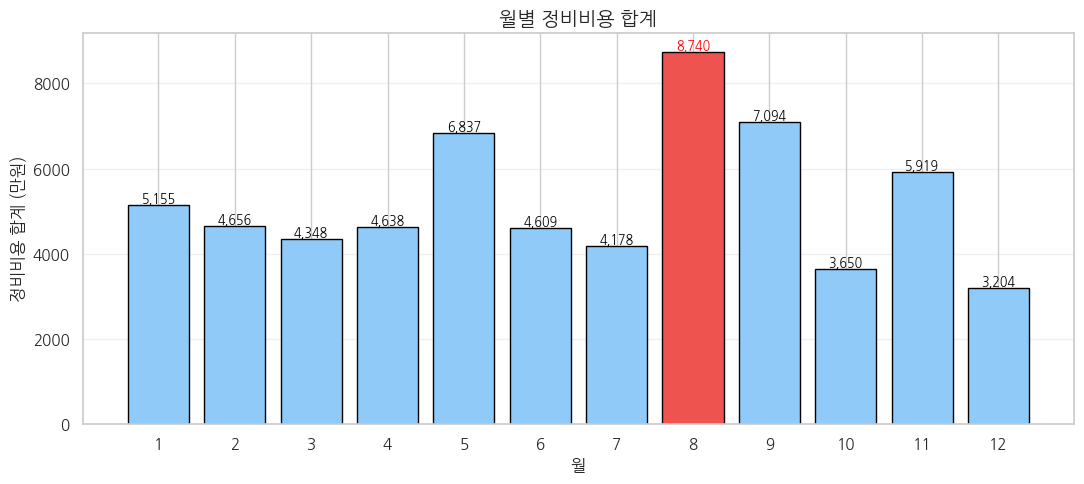

💡 인사이트 2: 8월 비용 최고점 (8,740만원)
   → 3분기(7-9월, 하계 훈련기) 비용 비율: 31.8%
   → 7월 훈련 前 사전 정비 계획 수립 권고


In [73]:
# 월별 총 정비비용
monthly_cost = df.groupby('월')['정비비용(만원)'].sum()

plt.figure(figsize=(11, 5))
bars = plt.bar(monthly_cost.index, monthly_cost.values,
               color=['#90CAF9']*7 + ['#EF5350'] + ['#90CAF9']*4,
               edgecolor='black')

# 최대값 강조
peak = monthly_cost.idxmax()
peak_val = monthly_cost.max()
for i, (m, v) in enumerate(monthly_cost.items()):
    plt.text(m, v + 50, f'{v:,.0f}', ha='center',
             fontsize=9, fontweight='bold' if m == peak else 'normal',
             color='red' if m == peak else 'black')

plt.title('월별 정비비용 합계', fontsize=14, fontweight='bold')
plt.xlabel('월'); plt.ylabel('정비비용 합계 (만원)')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 인사이트
Q3_cost = df[df['분기'] == 3]['정비비용(만원)'].sum()
total_cost = df['정비비용(만원)'].sum()
q3_pct = Q3_cost / total_cost * 100

print(f"💡 인사이트 2: {peak}월 비용 최고점 ({peak_val:,}만원)")
print(f"   → 3분기(7-9월, 하계 훈련기) 비용 비율: {q3_pct:.1f}%")
print(f"   → 7월 훈련 前 사전 정비 계획 수립 권고")

## 7-3. 인사이트 3 — 반복 고장 장비

In [74]:
# 반복 고장 장비 TOP 5
repeat = df['장비번호'].value_counts().head(5)
print("🔄 반복 고장 장비 TOP 5")
print(repeat)

# 해당 장비의 고장 내역
top_unit = repeat.index[0]
top_history = df[df['장비번호'] == top_unit].sort_values('정비일자')
print(f"\n🔍 {top_unit}의 고장 내역:")
print(top_history[['정비일자', '고장유형', '정비시간(h)', '정비비용(만원)', '결과']].to_string(index=False))

total_cost_repeat = top_history['정비비용(만원)'].sum()
print(f"\n💡 인사이트 3: {top_unit}의 연간 정비 횟수 {len(top_history)}회, 누적 비용 {total_cost_repeat}만원")
print(f"   → 해당 장비 교체 또는 정밀 점검 필요")

🔄 반복 고장 장비 TOP 5
장비번호
K131-023    5
GEN-006     5
K131-025    5
K131-015    5
K131-001    5
Name: count, dtype: int64

🔍 K131-023의 고장 내역:
      정비일자   고장유형  정비시간(h)  정비비용(만원) 결과
2024-02-20  오일 누유      8.0       101 완료
2024-03-03  오일 누유     11.2       201 완료
2024-07-23  궤도 마모     20.3       395 완료
2024-08-18  엔진 이상      5.3       100 완료
2024-09-11 변속기 결함     47.8       819 완료

💡 인사이트 3: K131-023의 연간 정비 횟수 5회, 누적 비용 1616만원
   → 해당 장비 교체 또는 정밀 점검 필요


## 7-4. 인사이트 4 — 가동불능 분석

⚠️ 가동불능 건수: 18건 (전체의 7.6%)

[ 가동불능 원인별 분포 ]
고장유형
궤도 마모      5
오일 누유      4
변속기 결함     3
브레이크 마모    3
엔진 이상      3
Name: count, dtype: int64


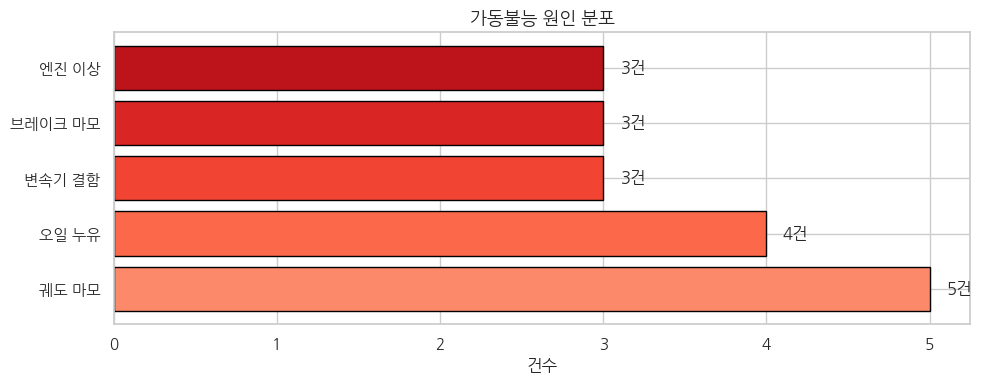


💡 인사이트 4: 가동불능의 주요 원인은 '궤도 마모' (5건)
   → 해당 부품의 여분 보유량 증가 검토


In [75]:
# 가동불능 사례 분석
downtime = df[df['결과'] == '가동불능']
print(f"⚠️ 가동불능 건수: {len(downtime)}건 (전체의 {len(downtime)/len(df)*100:.1f}%)")

# 고장유형별 가동불능 분포
dt_by_type = downtime['고장유형'].value_counts()
print(f"\n[ 가동불능 원인별 분포 ]")
print(dt_by_type)

# 시각화
plt.figure(figsize=(10, 4))
colors_dt = plt.cm.Reds(np.linspace(0.4, 0.8, len(dt_by_type)))
bars = plt.barh(dt_by_type.index, dt_by_type.values,
                color=colors_dt, edgecolor='black')
for bar, v in zip(bars, dt_by_type.values):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{v}건', va='center', fontweight='bold')
plt.title('가동불능 원인 분포', fontsize=13, fontweight='bold')
plt.xlabel('건수')
plt.tight_layout()
plt.show()

main_cause = dt_by_type.idxmax()
print(f"\n💡 인사이트 4: 가동불능의 주요 원인은 '{main_cause}' ({dt_by_type.max()}건)")
print(f"   → 해당 부품의 여분 보유량 증가 검토")

---
# 🏆 Chapter 8. 종합 대시보드 + 최종 보고서

> 지금까지 분석한 내용을 **하나의 Figure** 와 **텍스트 보고서** 로 정리합니다.  
> 4일차 미니 프로젝트의 **최종 산출물**입니다.

## 8-1. 6종 차트 종합 대시보드

✅ /content/EDA_dashboard.png 저장 완료


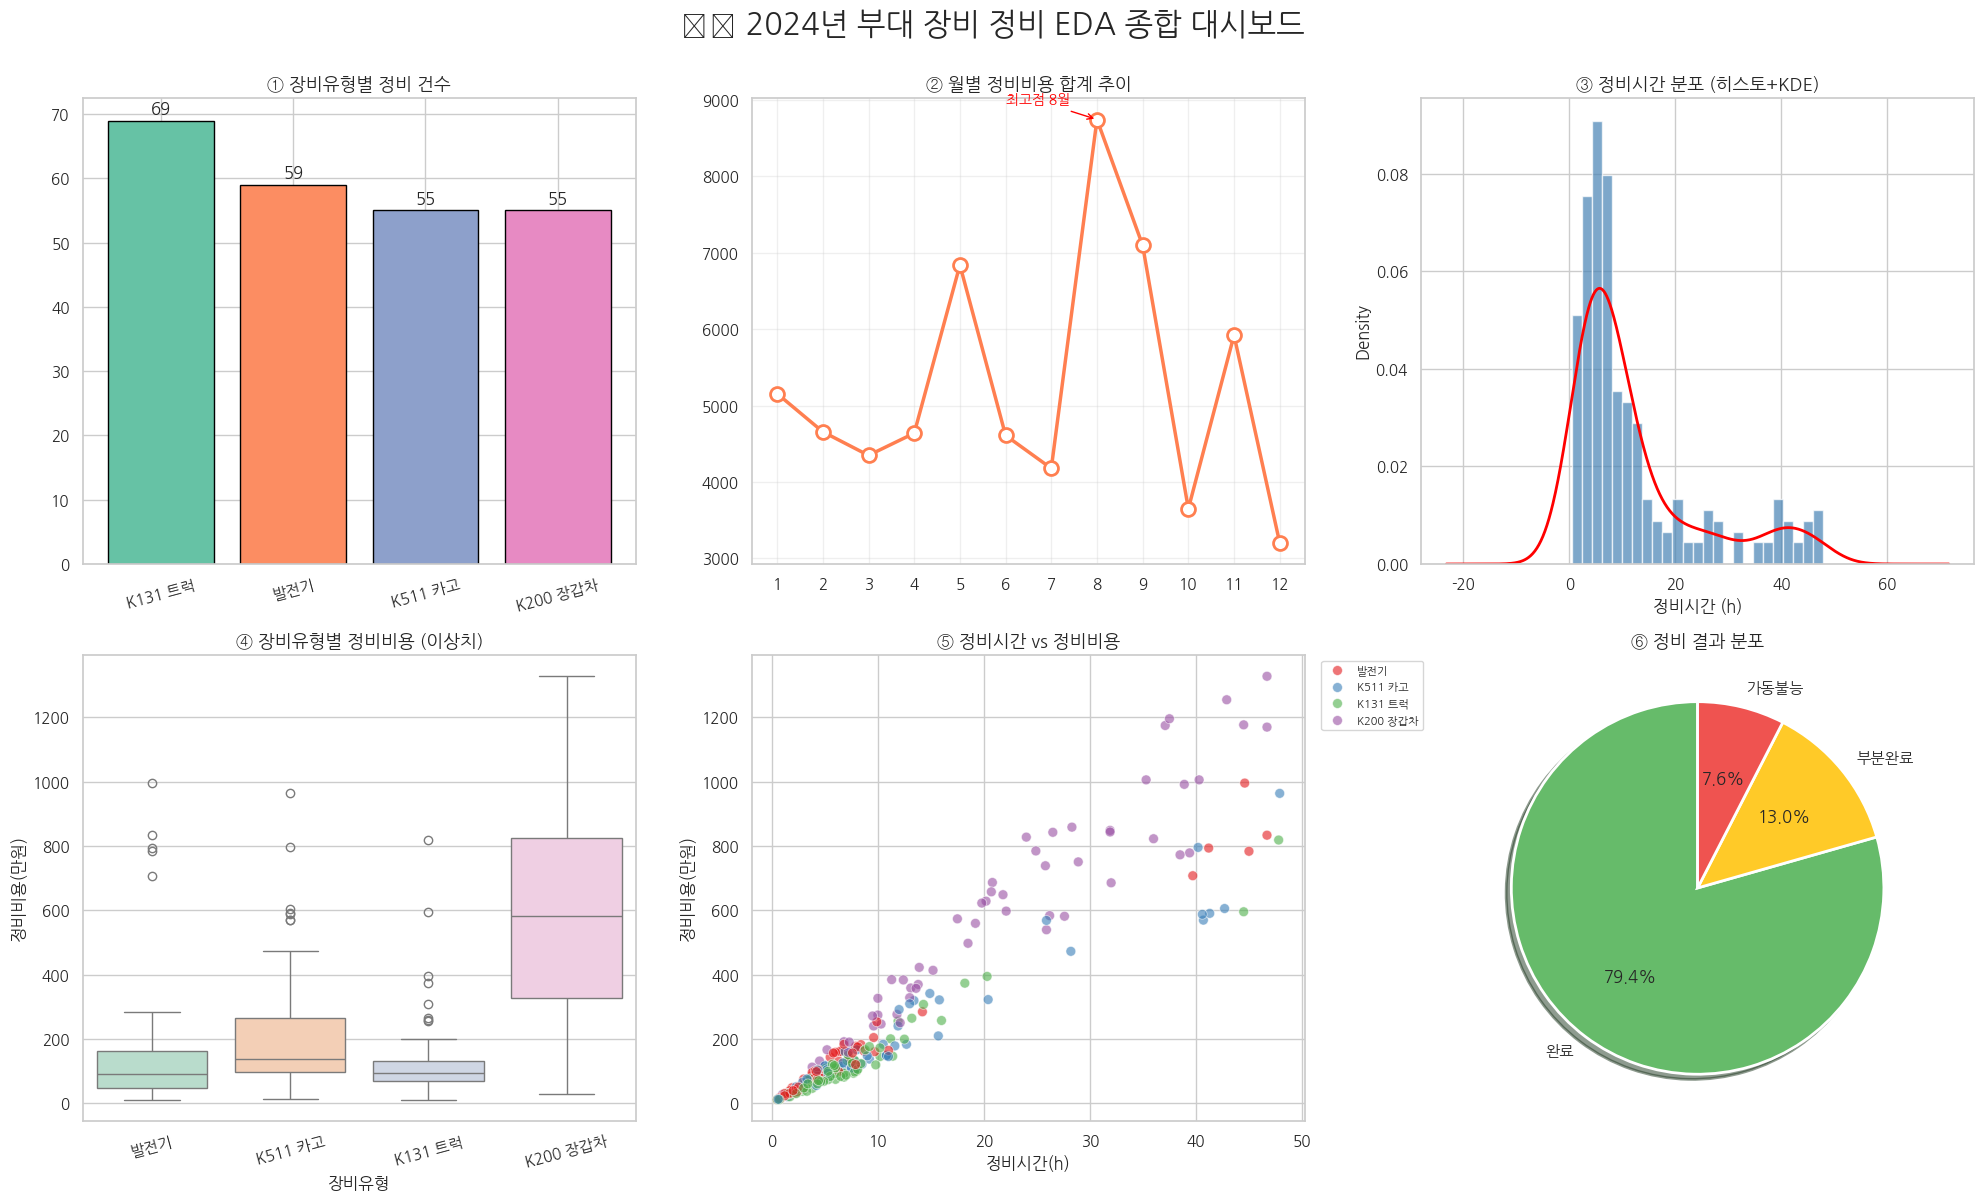

In [76]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('🎖️ 2024년 부대 장비 정비 EDA 종합 대시보드',
             fontsize=22, fontweight='bold', y=1.00)

# ① 장비유형별 정비 건수
eq_cnt = df['장비유형'].value_counts()
colors_eq = sns.color_palette('Set2', len(eq_cnt))
bars1 = axes[0,0].bar(eq_cnt.index, eq_cnt.values, color=colors_eq, edgecolor='black')
for bar, v in zip(bars1, eq_cnt.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                   str(v), ha='center', fontweight='bold')
axes[0,0].set_title('① 장비유형별 정비 건수', fontsize=13, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=15)

# ② 월별 정비비용 합계 추이
mc = df.groupby('월')['정비비용(만원)'].sum().reindex(range(1,13), fill_value=0)
axes[0,1].plot(mc.index, mc.values, marker='o', color='coral',
               linewidth=2.5, markersize=10, markerfacecolor='white', markeredgewidth=2)
peak_m = mc.idxmax()
axes[0,1].annotate(f'최고점 {peak_m}월',
                   xy=(peak_m, mc.max()), xytext=(peak_m-2, mc.max()+200),
                   fontsize=10, fontweight='bold', color='red',
                   arrowprops=dict(arrowstyle='->', color='red'))
axes[0,1].set_title('② 월별 정비비용 합계 추이', fontsize=13, fontweight='bold')
axes[0,1].set_xticks(range(1,13))
axes[0,1].grid(alpha=0.3)

# ③ 정비시간 분포 (히스토그램)
axes[0,2].hist(df['정비시간(h)'], bins=25, color='steelblue',
               edgecolor='white', density=True, alpha=0.7)
df['정비시간(h)'].plot(kind='kde', ax=axes[0,2], color='red', linewidth=2)
axes[0,2].set_title('③ 정비시간 분포 (히스토+KDE)', fontsize=13, fontweight='bold')
axes[0,2].set_xlabel('정비시간 (h)')

# ④ 장비유형별 비용 박스플롯
sns.boxplot(data=df, x='장비유형', y='정비비용(만원)',
            palette='Pastel2', ax=axes[1,0])
axes[1,0].set_title('④ 장비유형별 정비비용 (이상치)', fontsize=13, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=15)

# ⑤ 시간 vs 비용 산점도
sns.scatterplot(data=df, x='정비시간(h)', y='정비비용(만원)',
                hue='장비유형', palette='Set1', alpha=0.6, s=50,
                ax=axes[1,1])
axes[1,1].set_title('⑤ 정비시간 vs 정비비용', fontsize=13, fontweight='bold')
axes[1,1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# ⑥ 결과 분포 파이 차트
rc = df['결과'].value_counts()
axes[1,2].pie(rc, labels=rc.index, autopct='%1.1f%%',
              startangle=90, colors=['#66BB6A','#FFCA28','#EF5350'],
              shadow=True, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,2].set_title('⑥ 정비 결과 분포', fontsize=13, fontweight='bold')

plt.tight_layout()

# PNG로 저장
plt.savefig('/content/EDA_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print("✅ /content/EDA_dashboard.png 저장 완료")
plt.show()

## 🏆 종합 대시보드 — EDA의 모든 것이 한 화면에

이 셀은 노트북의 **클라이맥스**예요. 4일차 실습 전체에서 배운 내용이 하나의 종합 대시보드로 통합되는 단계입니다. 직전 카탈로그(Chapter 6)가 "차트의 도구함"이었다면, 이번 셀은 **그 도구함으로 부대 정비 운영을 진단한 최종 결과물**이에요. 보고서 표지에 들어갈 한 장의 그림이 만들어지는 순간입니다.

---

### 카탈로그와 대시보드의 결정적 차이

직전 셀(6가지 차트 카탈로그)과 이번 셀이 둘 다 6개 서브플롯이지만, **목적이 완전히 달라요**.

**카탈로그 (Chapter 6)** — 차트 종류를 학습하는 교육 도구. 제목이 "막대", "선", "히스토" 처럼 **차트 종류를 가리키는** 명칭이었어요. "이게 어떤 차트 종류인가"를 가르치는 게 목적입니다.

**대시보드 (Chapter 8)** — 부대 운영을 진단하는 보고 도구. 제목이 "장비유형별 정비 건수", "월별 정비비용 합계 추이"처럼 **분석 내용을 가리키는** 명칭이에요. "이 데이터가 무엇을 보여주는가"를 전달하는 게 목적입니다.

같은 6개 서브플롯이지만 **카탈로그는 분석가의 학습용, 대시보드는 의사결정자의 보고용**이라는 결정적 차이가 있어요. 이번 셀은 코드 구조는 카탈로그와 비슷하지만 **시각적 완성도와 정보 밀도가 한 단계 높아진 보고서 품질**의 그림입니다.

---

### `suptitle`의 격상 — 보고서 표지 같은 디자인

**`fig.suptitle('🎖️ 2024년 부대 장비 정비 EDA 종합 대시보드', fontsize=22, fontweight='bold', y=1.00)`**

직전 셀의 메인 제목은 fontsize 16이었는데 이번엔 22예요. 거의 1.4배 크기로 키운 거죠. 그리고 🎖️ 군 훈장 이모지까지 추가해서 부대 보고서 특유의 권위와 격식을 시각적으로 표현했어요.

이런 디자인 디테일이 보고서의 첫인상을 결정합니다. 같은 정보라도 표지가 잘 만들어진 보고서가 받는 사람의 신뢰를 더 빠르게 얻거든요. 데이터 분석에서 **시각적 완성도는 사치가 아니라 의사소통의 본질**이에요.

`figsize=(20, 12)`도 직전 카탈로그의 (18, 10)보다 더 큰 캔버스예요. 보고서 한 페이지를 가득 채울 수 있는 크기로, 인쇄 시에도 가독성이 보장됩니다.

---

### ① 장비유형별 정비 건수 — 시작은 가장 단순한 사실부터

대시보드의 좌상단은 **가장 먼저 시선이 가는 자리**입니다. 그래서 가장 단순하면서도 기초적인 사실을 배치하는 게 정석이에요. 막대 차트가 보여주는 메시지는 명확합니다 — **K131 트럭 69건, 발전기 59건, K511과 K200 각각 55건**.

흥미로운 건 4개 장비의 **건수가 거의 비슷**하다는 거예요. 가장 많은 K131(69)과 가장 적은 K200·K511(55)의 차이가 14건뿐이에요. 즉 **건수 측면에서는 부대 정비 부하가 비교적 균등 분포**합니다.

이게 이 대시보드 전체의 흐름에 매우 중요한 출발점이에요. 이 첫 차트만 봐서는 "K200이 부대 정비의 핵심 변수"라는 결론이 절대 안 나옵니다. K200은 건수로는 가장 적은 그룹에 속하니까요. 그런데 다른 차트들로 넘어가면서 **건수와 비용·시간의 괴리**가 점점 드러나는 거예요. 이 1번 차트는 **앞으로 등장할 반전을 위한 베이스라인**입니다.

**`colors_eq = sns.color_palette('Set2', len(eq_cnt))`** 의 디테일도 짚어볼게요. 직전 박스플롯들에서 사용한 Set2 팔레트와 동일한 색을 막대 차트에도 적용했어요. 이게 **대시보드 전체의 색상 일관성**을 만듭니다. K200 = 분홍, K511 = 보라, K131 = 청록, 발전기 = 주황으로 모든 차트에서 같은 매핑이 유지되면 보는 사람이 색만으로 장비를 식별할 수 있어요.

---

### ② 월별 정비비용 합계 추이 — 8월의 압도적 봉우리

가운데 위 자리는 **시간 차원의 핵심 메시지**가 들어가는 자리입니다. 이번 차트는 직전까지의 분석에서 봤던 "8월 피크"를 비용 차원에서 다시 한번 강조해요.

이 그림에서 가장 인상적인 건 **8월의 비용이 약 8,700만원으로 다른 달의 평균(약 5,000만원)보다 70% 이상 높다**는 거예요. 5월과 11월에도 7,000만원 가까운 작은 봉우리가 있고, 10월(약 3,700만원)과 12월(약 3,300만원)이 가장 낮습니다.

이 차트가 직전 셀의 카탈로그 ②번(월별 건수 추이)에서 한 단계 진화한 모습이에요. 카탈로그에서는 **건수**(8월 약 36건)를 봤고, 이번 대시보드에서는 **비용 합계**(8월 약 8,700만원)를 봅니다. 같은 8월이지만 측정 단위가 다른 거죠.

**왜 비용이 더 의미 있는가** — 부대 운영 의사결정자(지휘관·예산 책임자)에게는 "8월에 정비 36건이 발생함"보다 "8월에 정비비 8,700만원이 발생함"이 훨씬 직접적인 메시지예요. 예산 계획·자원 배분의 단위가 비용이기 때문입니다.

**최고점 표시의 디테일**

`annotate`로 "최고점 8월"이라는 라벨을 화살표와 함께 붙인 게 보고서 품질의 핵심이에요. 이 한 표시가 없으면 보는 사람이 "어디가 가장 높지?"를 직접 찾아야 하지만, 라벨이 있으면 **0.5초 만에 핵심 메시지가 전달**됩니다.

`xytext=(peak_m-2, mc.max()+200)`로 텍스트 위치를 살짝 왼쪽-위로 띄운 게 의도적이에요. 8월이 X축 끝에서 가까우니 텍스트가 차트 바깥으로 나가지 않게 왼쪽으로 옮긴 거고, 200만원만큼 위로 띄워 점과 텍스트가 겹치지 않게 했어요.

---

### ③ 정비시간 분포 (히스토그램 + KDE) — 분포의 진화

우상단 차트가 이번 대시보드에서 가장 **시각적으로 진화한** 그림이에요. 단순 히스토그램에 **KDE(커널 밀도 추정) 곡선**을 겹쳐 그려서 분포의 모양을 더 부드럽게 보여줍니다.

**KDE가 무엇인가**

KDE(Kernel Density Estimation)는 히스토그램의 **연속적 버전**이에요. 히스토그램이 데이터를 구간으로 나눠 막대로 표시한다면, KDE는 그 패턴을 **부드러운 곡선**으로 표현합니다. 통계적으로는 데이터의 확률 밀도 함수를 비모수적으로 추정한 결과예요.

이 차트의 빨간 곡선이 KDE이고, 파란 막대가 히스토그램입니다. 두 표현이 같은 데이터를 다른 방식으로 보여주는데:

먼저 **분포의 주된 봉우리가 약 5시간 부근**에 있어요. 막대도 가장 높지만, KDE 곡선의 정점도 5시간 근처에 있습니다. 이게 정비시간의 **최빈값(mode)** 이에요.

다음으로 **오른쪽으로 이어지는 긴 꼬리**. 5시간 이후로 빈도가 급감하면서 50시간 부근까지 길게 늘어집니다. 이 꼬리가 부대 정비비용을 끌어올리는 K200의 흔적이에요.

가장 흥미로운 건 **40시간 부근의 작은 두 번째 봉우리**예요. KDE 곡선을 보면 5시간 부근의 큰 봉우리가 끝나고 10~30시간 구간에서 곡선이 거의 평평하다가, **40시간 부근에서 다시 살짝 올라가는 작은 융기**가 보입니다.

이게 **이중 모드 분포**의 시각적 증거예요! 정비시간이 단일 분포가 아니라 **두 개의 다른 작업 카테고리**가 섞여 있다는 사실이 KDE 곡선으로 명확하게 드러납니다. 첫 번째 모드(5h)는 일상적 정비, 두 번째 모드(40h)는 K200의 중정비. 단순 히스토그램에서는 막대가 작아 잘 안 보이던 이 두 번째 봉우리가 KDE의 부드러운 곡선에서는 명확한 융기로 보여요.

**`density=True` 의 의미**

히스토그램을 그릴 때 `density=True`로 했어요. 이건 Y축을 빈도(건수)가 아니라 **확률 밀도**로 바꾸는 옵션이에요. KDE와 같은 척도가 되어서 두 그래프를 같은 Y축에 겹쳐 그릴 수 있게 됩니다. 이 옵션이 없으면 히스토그램이 0~50 범위, KDE가 0~0.1 범위가 되어 같이 그릴 수 없어요.

`alpha=0.7`로 히스토그램에 투명도를 준 것도 디테일이에요. 불투명하면 KDE 곡선이 막대에 가려지는데, 투명도를 주면 두 표현이 **함께 보이면서 보완**합니다.

---

### ④ 장비유형별 비용 박스플롯 — K200의 압도성 재확인

좌하단 자리에 박스플롯이 들어간 건 **다변량 분석으로 넘어가는 첫 단계**라는 의미예요. 위 행이 단변량(변수 1개씩) 분석이었다면, 아래 행은 다변량(변수 2개 이상) 분석으로 넘어갑니다.

이 그림은 직전까지 여러 번 봤던 그림이에요. K200의 박스가 다른 장비의 박스 위에 떠 있는 압도적 모습. **반복은 강조의 한 형태**입니다. 보고서에서 같은 결론을 다른 각도로 여러 번 보여주는 건 **메시지의 강도**를 높이는 정석적 기법이에요.

이번 대시보드에서 박스플롯이 다시 등장하는 의미는 — **"K200이 부대 정비의 핵심 변수다"라는 결론에 대한 시각적 못 박기**예요. 1번 차트(건수)에서는 K200이 평범했지만, 4번 차트에 와서 비용 차원으로 보면 K200이 압도한다는 게 한 화면에서 직접 비교됩니다.

**`palette='Pastel2'`** 의 선택도 흥미로워요. 직전 박스플롯들에서는 'Set2'를 썼는데 이번엔 'Pastel2'예요. Pastel은 Set의 채도를 낮춘 부드러운 버전이에요. 대시보드 전체의 컬러 톤을 부드럽게 통일하기 위한 선택이고, 옆의 산점도(⑤번)에서 Set1을 쓴 진한 색과 시각적 균형을 맞추는 효과도 있어요.

---

### ⑤ 정비시간 vs 정비비용 산점도 — 0.94 상관의 시각적 입증

가운데 아래 자리는 **두 변수의 관계**를 보여주는 자리예요. 산점도는 그 관계의 강도와 패턴을 raw 데이터 차원에서 시각화하는 가장 강력한 도구입니다.

이 그림이 보여주는 건 — 점들이 좌하단에서 우상단으로 매우 깔끔한 직선 패턴을 그리고 있다는 거예요. 이게 **상관계수 0.94의 시각적 정체**입니다. 점들이 이렇게 직선에 가깝게 정렬되는 건 두 변수가 거의 결정론적 관계임을 보여줘요.

색상으로 장비 유형을 구분한 것도 핵심이에요. 보라색(K200) 점들이 우상단 영역에 집중적으로 분포하고, 다른 색깔의 점들은 좌하단 영역에 몰려 있어요. 이 색상 패턴이 **"K200의 정비는 본질적으로 시간도 길고 비용도 비싸다"**는 결론을 시각적으로 입증합니다.

**범례 위치의 디테일**

`legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)` 으로 범례를 차트 바깥 우상단에 배치했어요. 이게 중요한 이유는 — 범례를 차트 안에 두면 데이터 점들과 겹쳐 가독성이 떨어지거든요. 차트 바깥으로 빼서 데이터가 가려지지 않게 한 거고, fontsize를 8로 작게 잡아 공간을 절약했습니다.

`bbox_to_anchor=(1.02, 1)`의 좌표는 **차트 영역의 우상단(1, 1)에서 살짝 오른쪽(1.02)으로 떨어진 위치**를 의미해요. 이 미세한 띄움이 차트와 범례를 자연스럽게 분리합니다.

---

### ⑥ 정비 결과 분포 파이 차트 — 부대 가동률의 진실

우하단 자리에 파이 차트가 들어간 게 흥미로워요. 직전 카탈로그에서는 파이 차트가 6가지 안에 없었는데, 이번 대시보드에서는 마지막 자리를 차지합니다.

이 그림이 보여주는 메시지는 — **완료 79.4%, 부분완료 13.0%, 가동불능 7.6%**. 부대 정비의 약 80%가 완전 성공이고, 약 13%는 부분적 성공, 약 8%는 실패라는 거예요.

**파이 차트가 이 자리에 들어간 이유**

직전 카탈로그에서 봤듯 파이 차트는 일반적으로 **막대 차트보다 정보 전달력이 약한 차트**예요. 사람의 눈이 각도 비교에 약하기 때문이죠. 그런데 이번 대시보드의 마지막 자리에는 파이 차트가 매우 적절합니다.

이유는 — **3개 카테고리의 비율 비교**라는 매우 단순한 정보고, 합계가 100%인 **부분-전체 관계**를 표현하기 때문이에요. 이런 데이터에는 파이 차트가 직관적으로 잘 어울립니다. 만약 카테고리가 7개 이상이거나 비율 차이가 미묘하다면 막대가 나았을 거예요.

**색상 선택의 메시지**

`colors=['#66BB6A','#FFCA28','#EF5350']` — 초록·노랑·빨강의 **신호등 색상**을 썼어요. 이게 매우 영리한 선택입니다. 어떤 설명도 없이 색만으로 "초록=좋음, 노랑=주의, 빨강=경고"가 전달돼요.

완료(좋음)는 초록, 부분완료(주의)는 노랑, 가동불능(경고)은 빨강으로 매핑되면서 — **색만 봐도 정비 성과가 어떤 상태인지 직관적으로 인지**됩니다. 데이터 시각화에서 색상이 갖는 **문화적 의미**를 활용한 디자인이에요.

**`shadow=True` 와 `wedgeprops`**

`shadow=True`는 파이에 살짝 그림자를 더해 입체감을 줘요. 이번 대시보드에서 다른 차트들은 모두 평면적인데 파이만 입체감이 있어서 시각적 강조 효과가 있어요.

`wedgeprops={'edgecolor':'white','linewidth':2}`는 각 조각 사이에 흰 선을 그어서 조각들을 명확히 분리합니다. 이게 없으면 비슷한 색의 조각이 서로 번져 보일 수 있어요.

**7.6%라는 숫자의 무게**

파이 차트의 빨간 조각 7.6%가 작아 보이지만, 부대 운영 관점에서는 **큰 의미**예요. 정비 100건당 약 8건이 실패한다는 건 8%의 장비를 살리지 못한다는 뜻이거든요. 부대 가용률에 직접 영향을 주는 수치입니다.

만약 정비를 1년에 240건 한다면 매년 약 18건의 장비가 가동불능 상태로 전환됩니다. 이 18건의 장비는 폐기되거나 중대 보수가 필요한 상태가 되니, 부대 자산 손실로 직결되는 숫자예요.

이 7.6%를 5%로 낮추면 어떻게 될까요? 240건 중 6건만 실패하게 됩니다. 즉 매년 약 12대의 장비를 추가로 살릴 수 있어요. 이게 **정비 시스템 개선의 직접적 효과**이고, 부대 자산 보호의 핵심 KPI입니다.

---

### 6개 차트가 함께 만드는 "스토리"

이 대시보드의 진짜 매력은 6개 차트가 **순서대로 읽으면 부대 정비의 완전한 이야기**가 만들어진다는 거예요.

**서론** (① 장비유형별 건수): "부대는 4개 장비를 거의 비슷한 빈도로 정비합니다"

**전개 1** (② 월별 비용 추이): "그런데 정비비용은 월별로 크게 변동하고, 8월에 가장 큰 부담이 발생합니다"

**전개 2** (③ 시간 분포): "정비시간은 대부분 5시간 안에 끝나지만, 일부는 40시간을 넘기는 이중 모드 분포를 보입니다"

**클라이맥스 1** (④ 장비×비용): "그 일부 긴 정비의 정체는 K200 장갑차로, 다른 장비의 4배 비용을 흡수합니다"

**클라이맥스 2** (⑤ 시간↔비용): "정비시간과 비용은 0.94 상관으로 거의 한 몸처럼 움직이며, K200이 그 직선의 우상단을 차지합니다"

**결론** (⑥ 결과 분포): "그 모든 노력의 결과로 79.4%의 정비가 성공하지만, 7.6%는 가동불능으로 끝납니다. 이 7.6%를 줄이는 게 다음 과제입니다"

이 흐름이 자연스럽게 부대 운영 보고서의 6개 단락으로 변환될 수 있어요. **시각화가 곧 보고서의 골격**이 되는 정석적 디자인입니다.

---

### `plt.savefig`로 PNG 저장의 의미

```python
plt.savefig('/content/EDA_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='white')
```

이 한 줄이 매우 중요해요. 노트북에서 보여주는 것에 그치지 않고 **별도 파일로 저장**해서 다른 곳에 활용할 수 있게 만듭니다.

`dpi=150`은 인쇄 품질의 해상도예요. 보통 화면 표시용으로는 dpi 72~100이면 충분하지만, 인쇄 보고서에는 dpi 150~300이 권장됩니다. 이 옵션 덕에 저장된 PNG를 부대 보고서·발표 자료에 그대로 가져다 써도 깨지지 않아요.

`bbox_inches='tight'`는 이미지의 여백을 자동으로 잘라줍니다. 기본 설정으로 저장하면 그래프 주변에 큰 흰색 여백이 남는데, tight 옵션이 그걸 제거해서 깔끔한 결과물을 만들어요.

`facecolor='white'`는 배경을 명시적으로 흰색으로 지정하는 옵션이에요. 일부 시스템에서는 기본 배경이 투명이라 다른 어두운 배경에 붙이면 글자가 안 보일 수 있는데, 이 옵션이 그걸 방지합니다.

**`/content/EDA_dashboard.png`** 라는 경로는 Google Colab의 기본 작업 디렉토리예요. Colab에서 실행할 때 자동으로 저장되도록 한 것이고, 좌측 파일 탐색기에서 다운로드 받을 수 있습니다.

다만 이 경로는 **로컬 환경에서는 작동하지 않을 수도** 있어요. 일반 Jupyter 환경이나 VS Code에서 실행한다면 경로를 `'./EDA_dashboard.png'` 같은 상대 경로나 `'C:\work\data_anal\EDA_dashboard.png'` 같은 절대 경로로 바꿔야 합니다. 부대 환경이 Colab인지 로컬 Jupyter인지 사전에 확인이 필요한 부분이에요.

---

### 대시보드 디자인의 황금 원칙들

이번 셀이 보여주는 디자인 원칙을 정리하면 5가지가 도출됩니다.

**원칙 1 — 단순에서 복잡으로의 흐름**: 좌상단(가장 단순한 막대)에서 우하단(종합 결론인 파이)으로 갈수록 정보가 누적되는 배치예요. 보는 사람의 시선 흐름(왼쪽→오른쪽, 위→아래)이 분석의 깊이와 일치합니다.

**원칙 2 — 단변량과 다변량의 분리**: 위 행은 단변량, 아래 행은 다변량으로 깔끔히 분리됐어요. EDA의 6단계 프로세스가 시각적 레이아웃에 그대로 녹아 있습니다.

**원칙 3 — 색상의 의미 부여**: 색이 단순 미적 요소가 아니라 **메시지를 전달**해요. 신호등 색상, 동일 장비의 일관된 색 매핑, 강조점의 빨간 색 등이 모두 의도적입니다.

**원칙 4 — 강조점의 명시화**: 가장 중요한 메시지(8월 피크)에는 화살표 라벨, 정비비용 차이는 박스플롯으로, 결과의 빨간 조각은 색으로 강조됐어요. 보는 사람이 어디서 시선을 멈춰야 하는지가 명확합니다.

**원칙 5 — 정보 밀도와 가독성의 균형**: 6개 차트가 한 화면에 있지만 답답하지 않아요. 각 서브플롯이 적절한 크기를 가지고, 제목과 축 라벨이 명확하며, 색이 깔끔합니다. 정보를 욕심내다 가독성을 잃지 않는 균형이 잘 잡혀 있어요.

---

### 대시보드의 한계 — 빠진 정보들

이 대시보드가 강력하지만 모든 분석을 담을 순 없어요. 빠진 핵심 정보들을 짚어볼게요.

**부대×장비 분포** — 어떤 부대가 어떤 장비를 보유·정비했는지의 정보가 빠졌어요. 이건 직전 분석에서 봤던 부대×장비 히트맵이었는데, 대시보드 공간 제약으로 제외됐습니다. 부대간 비교가 중요한 보고에서는 이 차트가 추가되어야 해요.

**고장유형별 분석** — 6가지 고장유형 중 어떤 게 가장 비싼지(궤도 마모·변속기 결함)도 빠졌어요. 부품 비축 의사결정에 직결되는 정보인데 대시보드에서는 보이지 않습니다.

**시간×장비 결합 분석** — 8월의 정비 부담이 어떤 장비에서 발생하는지(직전에 봤던 장비×월 히트맵)도 빠졌어요. 이게 있어야 "8월 K131 13건"같은 구체적 결론이 가능합니다.

이런 빠진 분석들은 **보고서의 본문**에 들어가야 해요. 대시보드는 표지의 역할을 하고, 본문에서 각 차트의 자세한 분석을 다루는 게 정석적인 보고서 구조입니다.

---

### 한 가지 발전 아이디어 — 인터랙티브 대시보드

이 대시보드는 정적 PNG로 저장돼요. 한 단계 더 발전시키려면 **인터랙티브 대시보드**를 만들 수 있어요. Plotly나 Streamlit 같은 라이브러리로 만들면:

- 막대에 마우스를 올리면 정확한 값이 툴팁으로 표시
- 박스플롯의 이상치 점에 마우스를 올리면 해당 정비 기록의 상세 정보 표시
- 산점도의 점을 클릭하면 그 정비 기록의 모든 컬럼이 사이드 패널에 표시
- 부대를 선택하면 모든 차트가 그 부대 데이터로 필터링

이런 기능이 가능해집니다. 정적 PNG의 한계를 넘어 **데이터를 능동적으로 탐색**할 수 있는 도구가 되는 거죠.

부대 환경에서 인터랙티브 대시보드를 구축하면 **분석가가 부대 회의에 참석해 실시간으로 질문에 답할 수 있는 도구**가 됩니다. 데이터 분석의 미래가 이 방향으로 가고 있어요.

---

### 30시간 교육의 클라이맥스

이 대시보드가 노트북에서 차지하는 위치가 의미 있어요. 4일차 30시간 교육의 **마지막 단계**입니다. 1~3일차에 배운 Python·Pandas·Matplotlib·Seaborn의 모든 기법이 이 한 화면에 통합되어 있어요.

각 차트를 만든 코드 한 줄 한 줄이 1~3일차에 배운 내용이에요. `groupby`, `value_counts`, `pivot_table`, `boxplot`, `scatterplot`, `subplots`, `annotate`, `legend` 위치 조정, 컬러 팔레트 선택, `savefig` — 이 모든 게 30시간 동안 단계적으로 학습한 도구들의 종합 활용입니다.

학습자 입장에서 이 대시보드를 자기 손으로 만들어냈다는 건 — **부대에 돌아가서 자기 데이터로 비슷한 분석을 수행할 수 있다**는 뜻이에요. 교육의 진짜 목적은 노트북을 따라하는 게 아니라 이 대시보드를 만드는 능력을 부대 현장으로 가져가는 거죠.

---

### 다음 단계 — 보고서 자동 생성과 미니 프로젝트

이 대시보드 다음에는 **Chapter 8-2의 자동 보고서 생성**이 옵니다. 대시보드에서 발견한 사실들을 자동으로 텍스트 보고서로 변환하는 코드예요. "최대 정비비 발생 지점: 8월 K200 장갑차" 같은 한 줄 한 줄이 데이터에서 자동 추출되어 보고서 형식으로 출력됩니다.

그리고 **Chapter 9의 미니 프로젝트**에서는 같은 형식의 분석을 **"담당부대 관점"**으로 다시 한번 수행하게 돼요. 학습자가 이번에는 코드를 따라하는 게 아니라 **스스로** 같은 깊이의 분석을 수행하는 단계입니다. 이 대시보드가 보여준 패턴을 부대 차원으로 변형 적용하는 종합 평가예요.

마지막으로 **수료 정리 단계**에서는 4일간 배운 내용이 한 화면에 정리되고, 30시간 교육의 마무리가 됩니다. 이 대시보드는 그 마무리로 가는 마지막 큰 결과물이에요.

---

### 한 줄 요약

이 종합 대시보드는 **부대 정비 데이터에서 도출된 모든 인사이트를 한 화면에 압축한 시각화의 정점**이에요. 6개 차트가 단순한 나열이 아니라 **단변량 → 다변량, 빈도 → 비용 → 결과**라는 분석의 흐름으로 배치되어, 보는 사람이 첫 차트부터 마지막 차트까지 순서대로 읽으면 부대 정비 운영의 완전한 진단 보고서가 되는 구조입니다.

K131이 가장 많이 정비받지만(①), 비용은 K200이 압도하고(②④), 시간 분포는 이중 모드를 보이며(③), 시간과 비용은 거의 결정론적 관계이고(⑤), 결과적으로 8%가 가동불능으로 끝난다(⑥)는 6개의 핵심 결론이 한 그림에서 입증됩니다.

이게 EDA의 궁극적 목표예요 — 수백 건의 raw 데이터를 **한 장의 그림에 압축**해서 의사결정자가 5초 만에 핵심을 이해할 수 있게 만드는 것. 이번 대시보드가 그 목표를 정확히 달성하는 모범 사례이고, 4일차 실습의 가장 중요한 학습 성과물입니다.

## 8-2. 최종 보고서 자동 생성

In [55]:
print("=" * 60)
print("📋 2024년 부대 장비 정비 EDA 분석 보고서")
print("=" * 60)

# ── 1. 개요 ──
print(f"\n【 1. 분석 개요 】")
print(f"  • 분석 기간    : 2024-01 ~ 2024-12 (12개월)")
print(f"  • 총 정비 건수 : {len(df):,}건")
print(f"  • 총 정비비용  : {df['정비비용(만원)'].sum():,}만원")
print(f"  • 평균 정비시간: {df['정비시간(h)'].mean():.2f}시간")
print(f"  • 가동불능율   : {(df['결과']=='가동불능').mean()*100:.1f}%")

# ── 2. 주요 발견 ──
print(f"\n【 2. 주요 발견 】")

# 발견 1: 고비용 장비
top_eq = df.groupby('장비유형')['정비비용(만원)'].sum().sort_values(ascending=False)
print(f"  [발견 1] 최고비용 장비: {top_eq.index[0]}")
print(f"           → 총 {top_eq.iloc[0]:,}만원 (전체의 {top_eq.iloc[0]/top_eq.sum()*100:.1f}%)")

# 발견 2: 정비 집중월
peak_m = df.groupby('월').size().idxmax()
peak_cnt = df.groupby('월').size().max()
print(f"\n  [발견 2] 최다 정비월: {peak_m}월 ({peak_cnt}건)")
print(f"           → 하계 훈련(6~8월) 직후 누적 손모 원인 추정")

# 발견 3: 강한 상관
r, p = stats.pearsonr(df['정비시간(h)'], df['정비비용(만원)'])
print(f"\n  [발견 3] 정비시간 ↔ 비용 상관계수: r={r:.3f} (강한 양의 상관)")
print(f"           → 시간 단축 = 비용 절감 효과")

# 발견 4: 반복 고장
repeat = df['장비번호'].value_counts()
repeat_3plus = (repeat >= 3).sum()
print(f"\n  [발견 4] 연 3회 이상 정비 장비: {repeat_3plus}대")
print(f"           → 교체 또는 정밀 점검 대상")

# ── 3. 권고사항 ──
print(f"\n【 3. 의사결정 권고안 】")
print(f"  ① {top_eq.index[0]} 전용 예방정비 프로그램 수립")
print(f"     → 월 1회 정기 점검, 부품 사전 확보")
print(f"  ② 7월 이전 사전 정비 계획 수립")
print(f"     → 하계 훈련 前 주요 장비 종합 점검")
print(f"  ③ 반복 고장 장비 {repeat_3plus}대 긴급 점검")
print(f"     → 노후 부품 교체 또는 장비 교체")
print(f"  ④ 가동불능 주요 원인 부품 여분 확보")

print("\n" + "=" * 60)
print(f"  📅 보고일: {pd.Timestamp.today().strftime('%Y-%m-%d')}")
print(f"  📂 대시보드: /content/EDA_dashboard.png")
print("=" * 60)

📋 2024년 부대 장비 정비 EDA 분석 보고서

【 1. 분석 개요 】
  • 분석 기간    : 2024-01 ~ 2024-12 (12개월)
  • 총 정비 건수 : 238건
  • 총 정비비용  : 63,028만원
  • 평균 정비시간: 12.15시간
  • 가동불능율   : 7.6%

【 2. 주요 발견 】
  [발견 1] 최고비용 장비: K200 장갑차
           → 총 32,940만원 (전체의 52.3%)

  [발견 2] 최다 정비월: 8월 (36건)
           → 하계 훈련(6~8월) 직후 누적 손모 원인 추정

  [발견 3] 정비시간 ↔ 비용 상관계수: r=0.940 (강한 양의 상관)
           → 시간 단축 = 비용 절감 효과

  [발견 4] 연 3회 이상 정비 장비: 42대
           → 교체 또는 정밀 점검 대상

【 3. 의사결정 권고안 】
  ① K200 장갑차 전용 예방정비 프로그램 수립
     → 월 1회 정기 점검, 부품 사전 확보
  ② 7월 이전 사전 정비 계획 수립
     → 하계 훈련 前 주요 장비 종합 점검
  ③ 반복 고장 장비 42대 긴급 점검
     → 노후 부품 교체 또는 장비 교체
  ④ 가동불능 주요 원인 부품 여분 확보

  📅 보고일: 2026-04-29
  📂 대시보드: /content/EDA_dashboard.png


## 8-3. 분석 결과를 CSV로 저장

In [78]:
# 핵심 요약 표 저장
equip_final = df.groupby('장비유형').agg(
    정비건수 = ('장비번호', 'count'),
    총비용   = ('정비비용(만원)', 'sum'),
    평균시간 = ('정비시간(h)', 'mean'),
    가동불능 = ('결과', lambda x: (x == '가동불능').sum())
).round(2).sort_values('총비용', ascending=False)

equip_final.to_csv('/content/EDA_summary.csv', encoding='utf-8-sig')

# 월별 추이 저장
monthly_summary = df.groupby('월').agg(
    건수 = ('장비번호', 'count'),
    총비용 = ('정비비용(만원)', 'sum'),
    평균시간 = ('정비시간(h)', 'mean')
).round(2)
monthly_summary.to_csv('/content/EDA_monthly.csv', encoding='utf-8-sig')

print("✅ 저장 완료")
print("  - /content/EDA_summary.csv  (장비유형 요약)")
print("  - /content/EDA_monthly.csv  (월별 추이)")
print("  - /content/EDA_dashboard.png (종합 대시보드)")

✅ 저장 완료
  - /content/EDA_summary.csv  (장비유형 요약)
  - /content/EDA_monthly.csv  (월별 추이)
  - /content/EDA_dashboard.png (종합 대시보드)


---
# 🚀 Chapter 9. 스스로 해보는 미니 프로젝트

> 지금까지 배운 6단계 EDA를 **다른 주제** 로 직접 실행해 보세요.  
> 막히면 **Vibe Coding(ChatGPT/Claude)** 을 활용해 보세요!

## 🎯 미션: 담당부대 관점의 EDA
지금까지는 **장비유형** 관점에서 분석했습니다. 이제 **담당부대** 관점에서 다시 분석하세요.

### 요구사항
1. **담당부대별 정비 건수와 총 비용** 순위 (막대그래프)
2. **부대 × 장비유형 피벗 테이블** (정비 건수) + 히트맵
3. **부대별 월 추이** (4개 부대의 월별 정비 건수 선 그래프)
4. **부대별 가동불능률** 계산 및 비교
5. **한 줄 인사이트** 3개 이상 도출 (print 문으로)

In [57]:
# ✍️ 여기에 본인만의 EDA 분석을 작성하세요
# 힌트: df는 이미 로드되어 있습니다. 아래 3-4개의 그룹화/피벗/시각화 조합으로 시작하세요.

# 1) 담당부대별 정비 건수와 총 비용

# 2) 부대 × 장비유형 피벗

# 3) 부대별 월 추이

# 4) 부대별 가동불능률

# 5) 인사이트 출력


**✅ 샘플 솔루션**

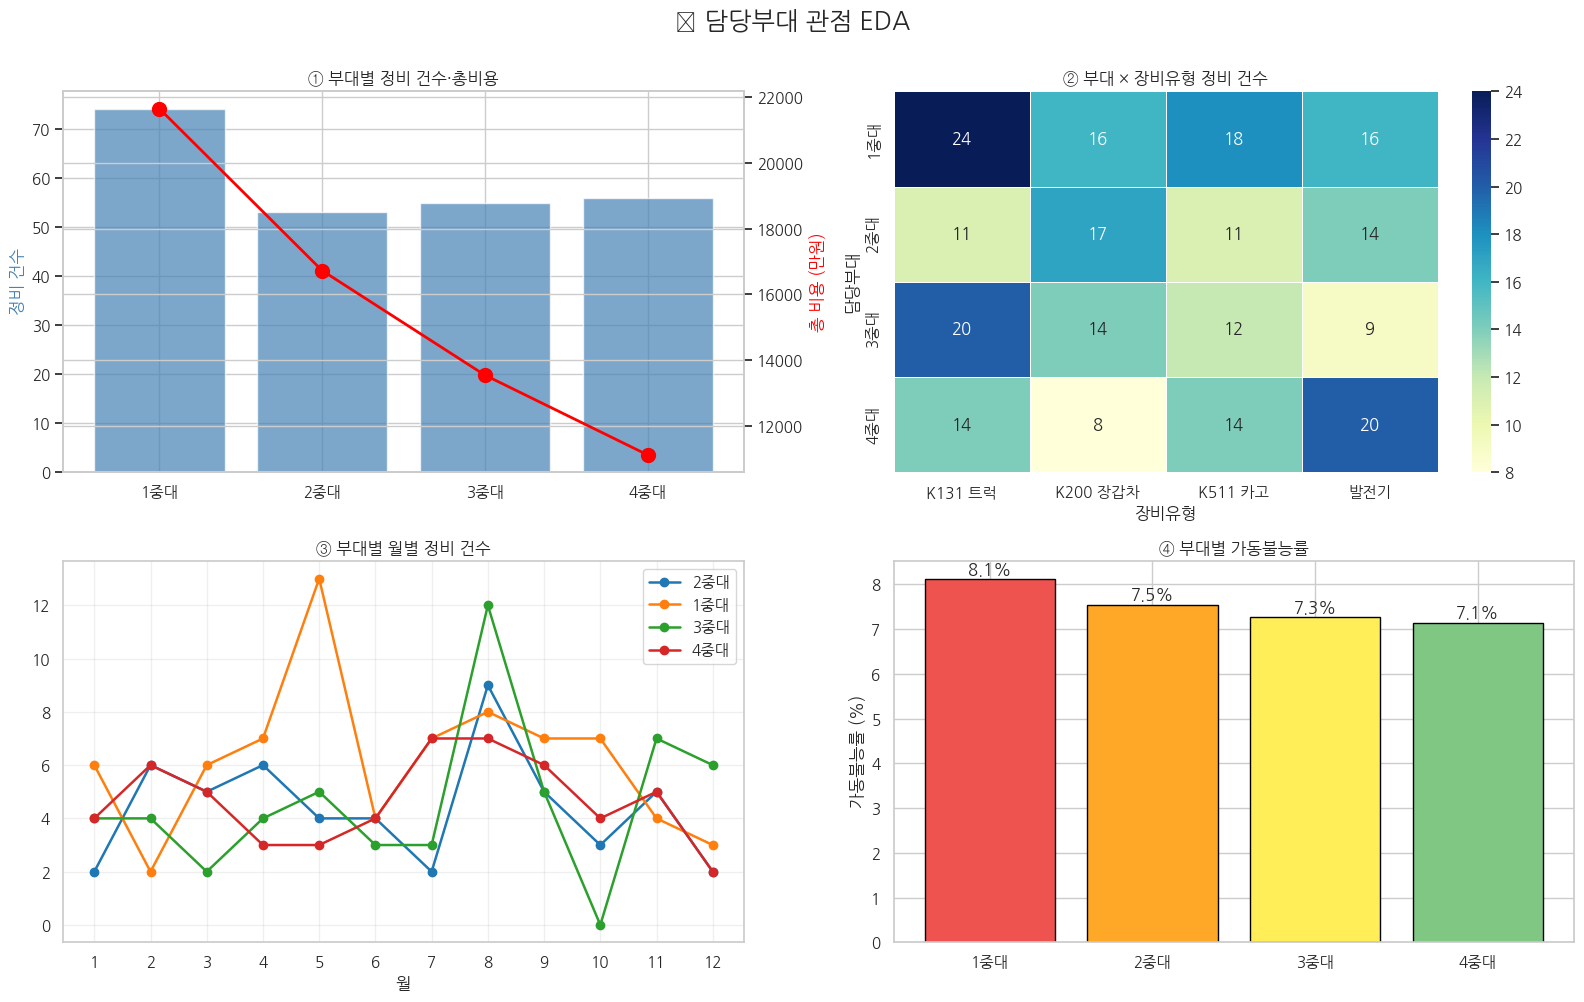


💡 담당부대 관점 인사이트
① 정비비용 최다 부대: 1중대 (21,652만원)
   → 장비 노후화 또는 사용 강도 조사 필요

② 가동불능률 최다: 1중대 (8.1%)
   → 장비 관리 체계 개선 권고

③ 전체 8월 정비 집중
   → 모든 부대에 사전 정비 가이드 배포


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('📊 담당부대 관점 EDA', fontsize=18, fontweight='bold', y=1.00)

# 1) 부대별 정비 건수와 총 비용
unit_stat = df.groupby('담당부대').agg(
    건수 = ('장비번호', 'count'),
    총비용 = ('정비비용(만원)', 'sum')
).sort_values('총비용', ascending=False)

ax = axes[0,0]
ax2 = ax.twinx()
x = range(len(unit_stat))
ax.bar(x, unit_stat['건수'], color='steelblue', alpha=0.7, label='건수')
ax2.plot(x, unit_stat['총비용'], marker='o', color='red', linewidth=2, markersize=10, label='총비용')
ax.set_xticks(x); ax.set_xticklabels(unit_stat.index)
ax.set_ylabel('정비 건수', color='steelblue')
ax2.set_ylabel('총 비용 (만원)', color='red')
ax.set_title('① 부대별 정비 건수·총비용', fontweight='bold')

# 2) 부대 × 장비유형 피벗 히트맵
pv = pd.pivot_table(df, values='장비번호', index='담당부대',
                    columns='장비유형', aggfunc='count', fill_value=0)
sns.heatmap(pv, annot=True, fmt='d', cmap='YlGnBu',
            linewidths=0.5, ax=axes[0,1])
axes[0,1].set_title('② 부대 × 장비유형 정비 건수', fontweight='bold')

# 3) 부대별 월 추이
for unit in df['담당부대'].unique():
    unit_monthly = df[df['담당부대']==unit].groupby('월').size().reindex(range(1,13), fill_value=0)
    axes[1,0].plot(unit_monthly.index, unit_monthly.values,
                   marker='o', linewidth=1.8, label=unit)
axes[1,0].set_title('③ 부대별 월별 정비 건수', fontweight='bold')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xlabel('월'); axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# 4) 부대별 가동불능률
down_rate = df.groupby('담당부대').apply(
    lambda g: (g['결과']=='가동불능').mean() * 100
).sort_values(ascending=False).round(2)
bars = axes[1,1].bar(down_rate.index, down_rate.values,
                     color=['#EF5350','#FFA726','#FFEE58','#81C784'], edgecolor='black')
for bar, v in zip(bars, down_rate.values):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                   f'{v:.1f}%', ha='center', fontweight='bold')
axes[1,1].set_title('④ 부대별 가동불능률', fontweight='bold')
axes[1,1].set_ylabel('가동불능률 (%)')

plt.tight_layout()
plt.show()

# 5) 인사이트
print("\n" + "=" * 50)
print("💡 담당부대 관점 인사이트")
print("=" * 50)
worst_unit = unit_stat.index[0]
print(f"① 정비비용 최다 부대: {worst_unit} ({unit_stat.iloc[0]['총비용']:,}만원)")
print(f"   → 장비 노후화 또는 사용 강도 조사 필요")

high_down = down_rate.idxmax()
print(f"\n② 가동불능률 최다: {high_down} ({down_rate.max():.1f}%)")
print(f"   → 장비 관리 체계 개선 권고")

busy_month = df.groupby('월').size().idxmax()
print(f"\n③ 전체 {busy_month}월 정비 집중")
print(f"   → 모든 부대에 사전 정비 가이드 배포")

---
# 🎓 4일차 & 30시간 전체 교육 수료 정리

## ✅ 4일차 배운 내용
| 단계 | 도구 | 결과물 |
|---|---|---|
| **1. 데이터 로드** | `read_csv`, `info`, `shape` | 데이터 구조 파악 |
| **2. 품질 점검** | `isnull`, `dropna`, `fillna` | 깨끗한 데이터 |
| **3. 기술통계** | `describe`, `value_counts`, IQR | 분포 요약 |
| **4. 단변량 분석** | 히스토그램, 박스플롯 | 개별 변수 특성 |
| **5. 다변량 분석** | `groupby`, `corr`, 히트맵 | 변수 간 관계 |
| **6. 인사이트** | 자동 보고서 + 대시보드 | **의사결정 권고** |

## 🏆 30시간 전체 수료 한눈에 보기
| 일차 | 주제 | 핵심 기술 |
|---|---|---|
| **1일차** | 파이썬 기초 & Colab | 변수·조건문·라이브러리·Vibe Coding |
| **2일차** | 데이터 수집 & 전처리 | pandas, 결측치·이상치·정규화 |
| **3일차** | 데이터 분석 & 가공 | groupby·pivot·corr·시각화 |
| **4일차** | EDA 미니 프로젝트 | 종합 분석 파이프라인 |

## 💡 John Tukey의 마지막 메시지
> **"데이터를 먼저 이해하고, 그 다음 분석하라."**  
> EDA는 분석의 시작이자, **의사결정의 근거**를 만드는 과정입니다.

## 🚀 수료 후 자기계발 로드맵
| Lv | 단계 | 추천 |
|---|---|---|
| 1 | **기초 유지** | 오늘 코드를 본인 부대 데이터에 적용 |
| 2 | **통계 강화** | 통계학 기초, 가설검정 |
| 3 | **ML 입문** | scikit-learn, 분류·회귀 모델 |
| 4 | **딥러닝** | PyTorch, TensorFlow |
| 5 | **AI 자동화** | API 활용, 업무 자동화 파이프라인 |

### 📚 추천 학습 자원
- **KMOOC** — 무료 온라인 강좌
- **유튜브 "모두의 AI"** — 한국어 AI 튜토리얼
- **Anthropic Claude** — 코딩·분석 AI 어시스턴트
- **Kaggle** — 실전 데이터 분석 프로젝트

---

### ⚠️ AI 활용 시 반드시 지켜야 할 수칙
- 🚫 **군사기밀·개인정보 입력 금지**
- 🔍 **AI 결과 반드시 검증** (맹신 금지)
- 📄 **저작권 및 보안 유의**
- ✅ **최종 책임은 사용자** — AI는 도구

---

## 🎖️ 수료를 축하합니다!

> **"스마트 강군 육성, 국방 AX(AI 전환)에 만전을 기하겠습니다"**

오늘 배운 EDA 기술을 본인 부대 실무 데이터에 적용하여  
**데이터 기반 의사결정 문화**를 만들어가세요!

---

*교육기관: (사)한국오픈소스협회 | 문의: 02-6012-7414 / kmil@osskorea.org*